MODELO DE DISPATCHING. 

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [86]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Creación de Snapshot

In [87]:
# (1) Definir el periodo. 
hours=pd.date_range("2025-01-01", periods=24*7, freq="h")

# (2) Crear la red vacía con esos snapshots
network=pypsa.Network()
network.set_snapshots(hours)

# (3) Calcular el peso de cada hora para extrapolar a un año completo
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight

#(4) Asignar el peso a cada snapshot
network.snapshot_weightings = pd.DataFrame(
    index=network.snapshots,
    data={
        "objective": single_weight,
        "generators": single_weight,
        "stores": 1.0,
    }
)

In [88]:
data = pd.read_excel(
    "C:\\Users\\EXT10348\\Downloads\\WinPython 3.12.10\\WPy64-31241\\PROYECTOS PYPSA\\Dispatching-Project-in-PypSA\\Parte III. Modelo España-Portugal-Francia\\modelo_dispatching.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

Lectura de Hojas de Datos (excel integrado)

In [89]:
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel

dict_keys(['Guide Sheet', 'carriers', 'buses', 'generators', 'loads', 'links', 'storage_units', 'store', 'demands', 'run_of_river_inflow', 'profiles', 'Hoja1'])


In [90]:

file = "modelo_dispatching.xlsx"
hours_week = 168 # flexible para definir semanas
hours_year = 8760 # flexible para definir años
#---------------------------------------------------------------------------------------------------------
# Perfiles de generación renovable
df_profiles = pd.read_excel(file, sheet_name="profiles") # Leer la hoja 'profiles' del archivo Excel
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) # Asegurar que la columna de fecha es datetime

# España: contamos con perfil solar y eólico, pero además tenemos SRES, que también tienen el mismo perfil eólico y solar.
ES_solar_profile     = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_SRES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True)
ES_SRES_solar_profile      = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True)

# Portugal: contamos con perfil solar y eólico, pero además tenemos SRES, que también tienen el mismo perfil eólico y solar.
PT_solar_profile     = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_wind_profile     = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_SRES_wind_profile      = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True)
PT_SRES_solar_profile      = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True)

# Francia: solo tenemos perfil nuclear.
FR_nuclear_profile     = df_profiles["FR_nuclear_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------

# Run of river inflow
df_run_of_river_inflow = pd.read_excel(file, sheet_name="run_of_river_inflow") # Leer la hoja 'profiles' del archivo Excel
df_run_of_river_inflow["date"] = pd.to_datetime(df_run_of_river_inflow["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_hydraulic_profile = df_run_of_river_inflow["ES_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_hydraulic_profile = df_run_of_river_inflow["PT_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------

# Demandas
df_demand2040 = pd.read_excel(file, sheet_name="demands") 
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) 
    # ESPAÑA
ES_demand_2040 = df_demand2040["ES_demand_2040"].iloc[:hours_week].reset_index(drop=True)
ES_hydrogen_demand = df_demand2040["ES_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_demand_2040 = df_demand2040["PT_demand_2040"].iloc[:hours_week].reset_index(drop=True)
PT_hydrogen_demand = df_demand2040["PT_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)

#Francia
FR_demand_2040 = df_demand2040["FR_demand_2040"].iloc[:hours_week].reset_index(drop=True)
FR_hydrogen_demand = df_demand2040["FR_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)


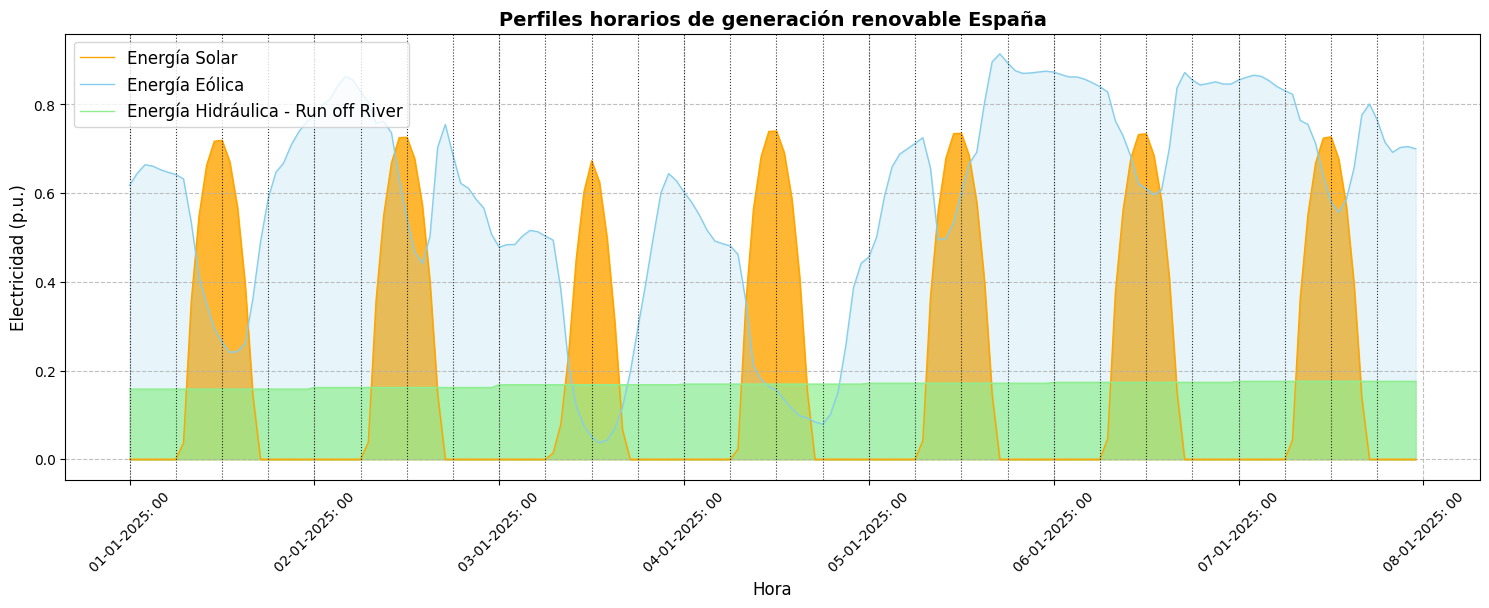

In [91]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_solar_profile, label="Energía Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, ES_wind_profile, label="Energía Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.plot(hours, ES_hydraulic_profile, label="Energía Hidráulica - Run off River", color="lightgreen", linewidth=1, linestyle="-")

plt.title("Perfiles horarios de generación renovable España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, ES_solar_profile, color="orange", alpha=0.8)
plt.fill_between(hours, ES_wind_profile, color="skyblue", alpha=0.2)
plt.fill_between(hours, ES_hydraulic_profile, color="lightgreen", alpha=0.7)


for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



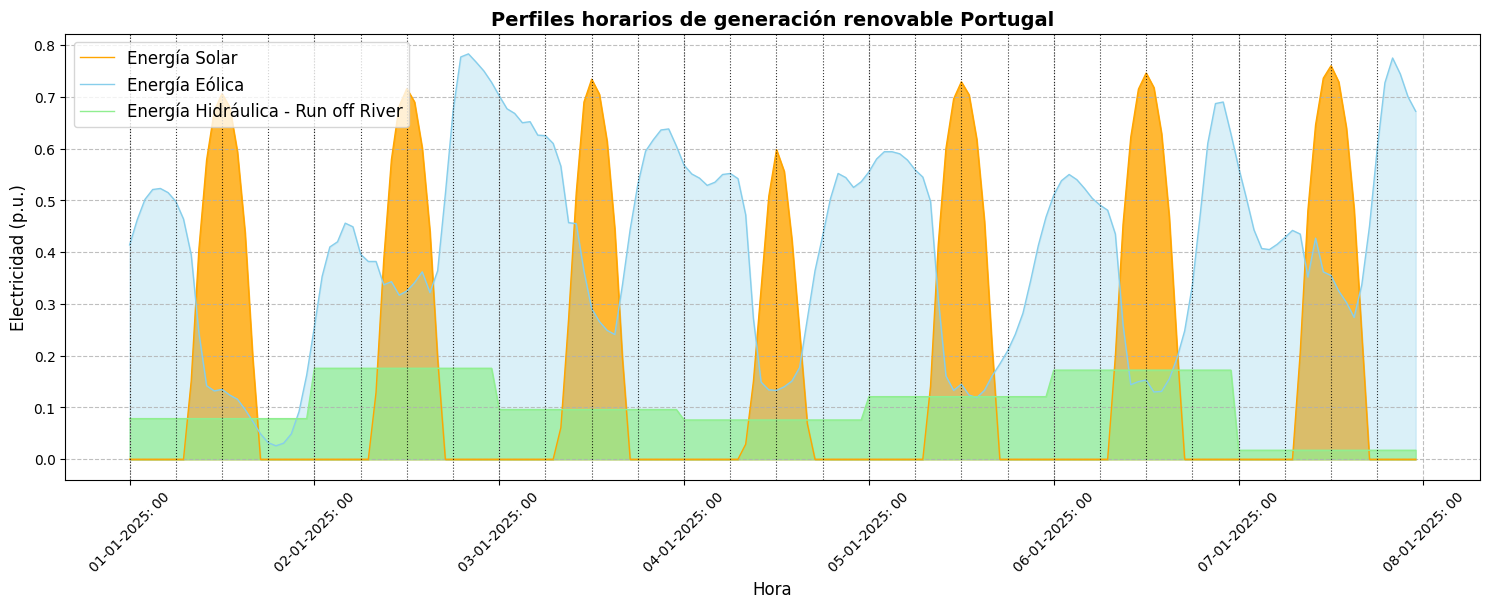

In [92]:
# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_solar_profile, label="Energía Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, PT_wind_profile, label="Energía Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.plot(hours, PT_hydraulic_profile, label="Energía Hidráulica - Run off River", color="lightgreen", linewidth=1, linestyle="-")

plt.title("Perfiles horarios de generación renovable Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, PT_solar_profile, color="orange", alpha=0.8)
plt.fill_between(hours, PT_wind_profile, color="skyblue", alpha=0.3)
plt.fill_between(hours, PT_hydraulic_profile, color="lightgreen", alpha=0.7)


for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

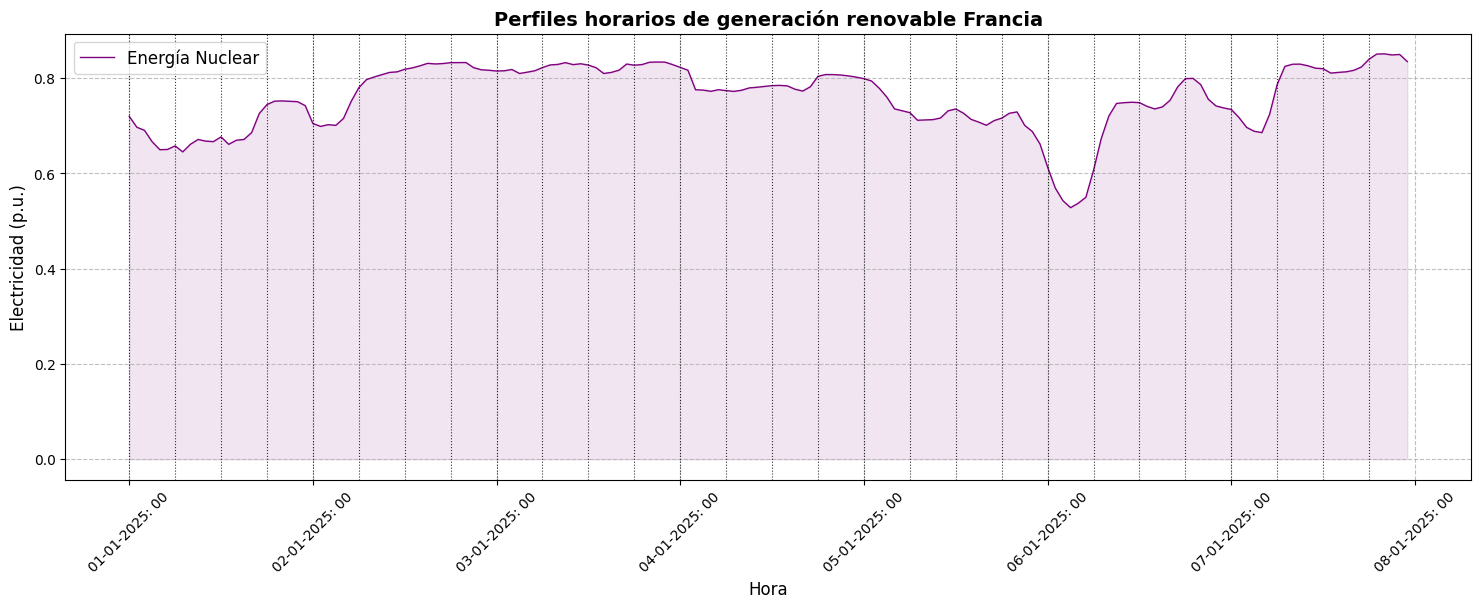

In [93]:
# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, FR_nuclear_profile, label="Energía Nuclear", color="purple", linewidth=1, linestyle="-")


plt.title("Perfiles horarios de generación renovable Francia", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, FR_nuclear_profile, color="purple", alpha=0.1)


for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\2008595108.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



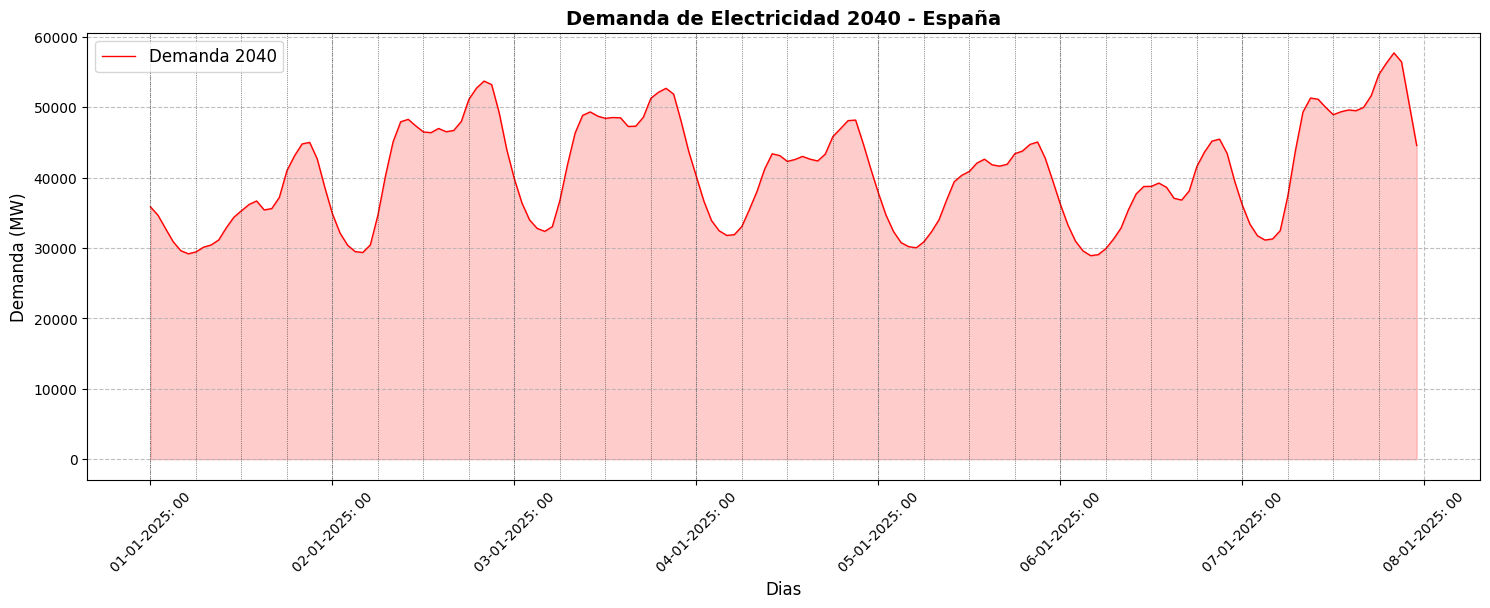

In [94]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - España",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

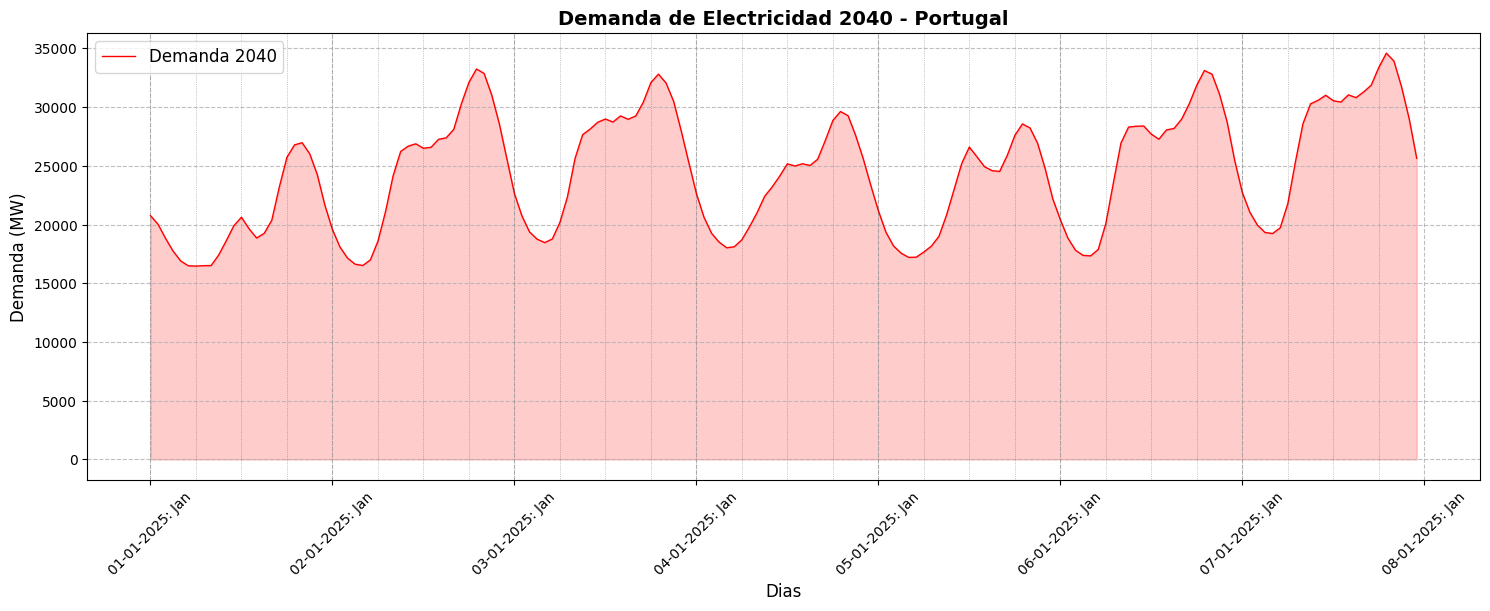

In [95]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - Portugal",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

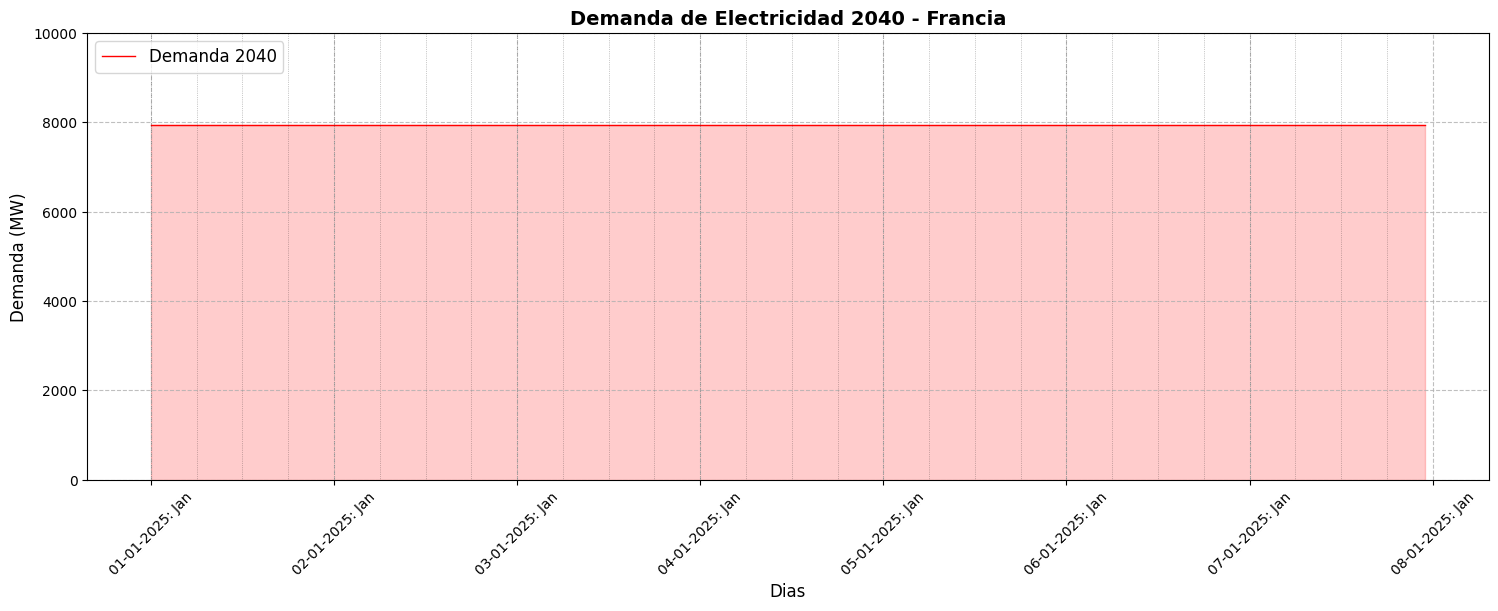

In [96]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, FR_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, FR_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - Francia",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(0,10000)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

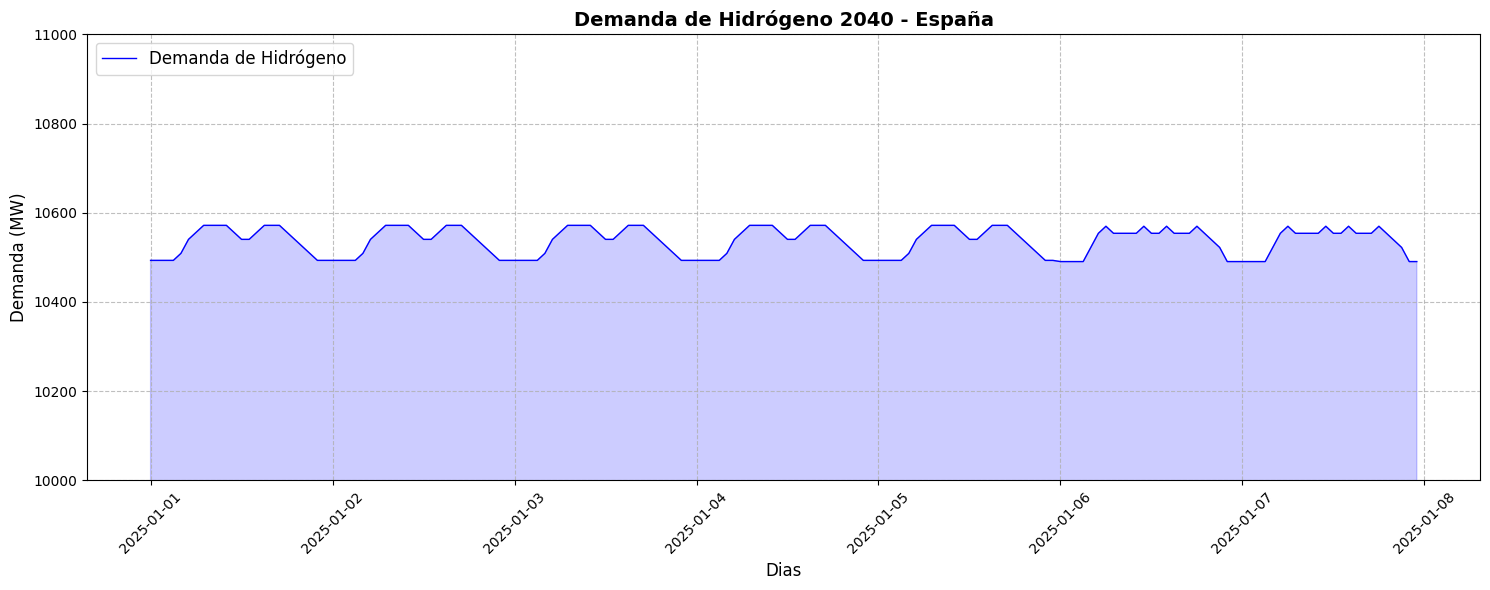

In [97]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydrogen_demand, label="Demanda de Hidrógeno", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno 2040 - España",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(10000, 11000)

plt.xticks(rotation=45)
plt.show()

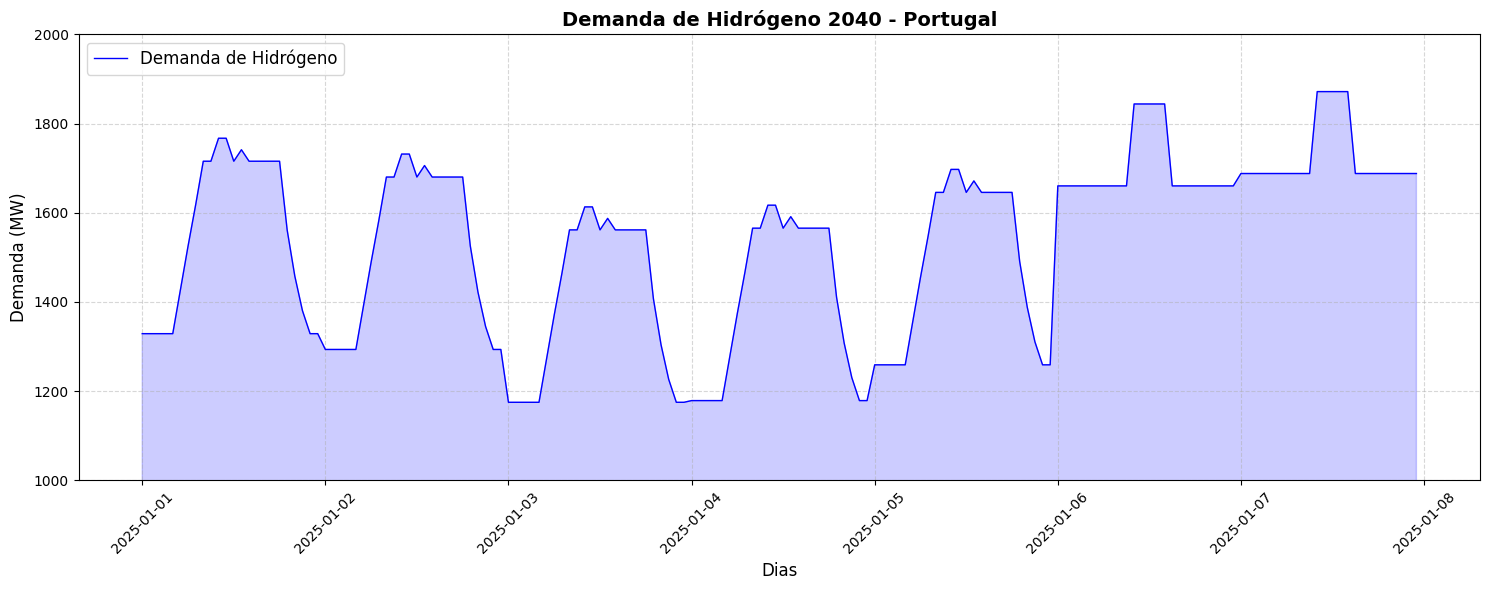

In [98]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydrogen_demand, label="Demanda de Hidrógeno", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno 2040 - Portugal",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(1000,2000)

plt.xticks(rotation=45)
plt.show()

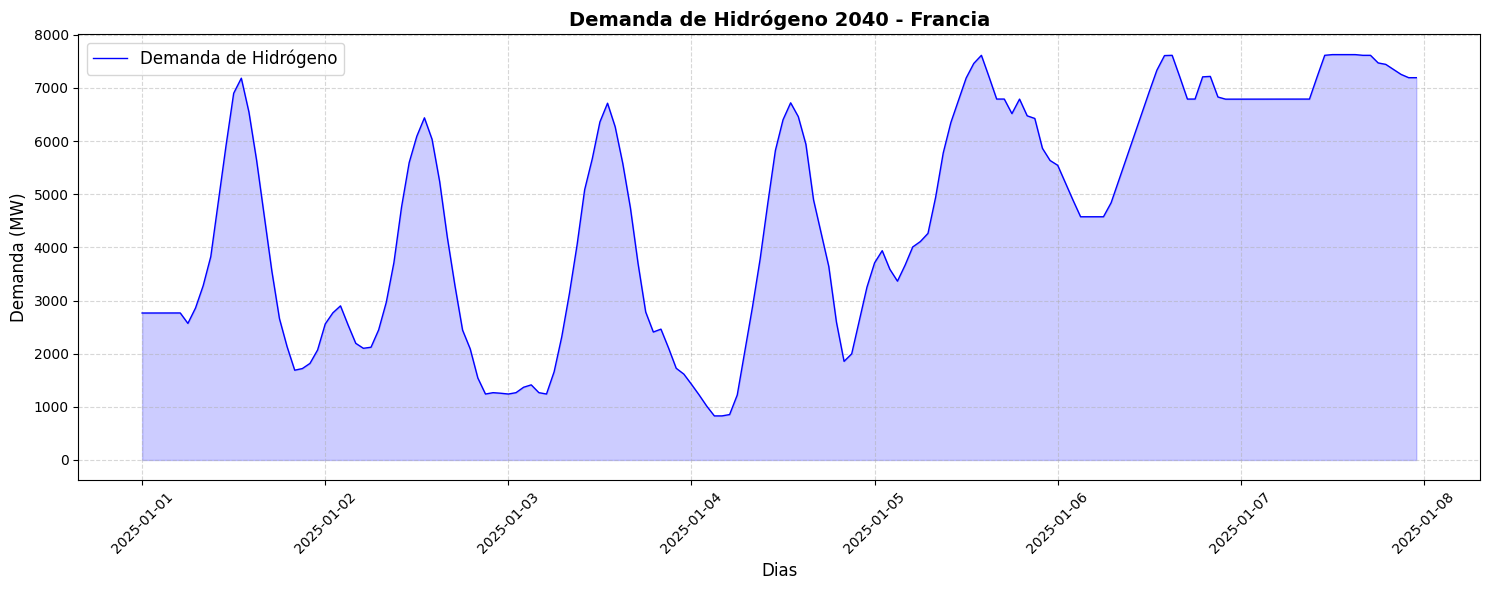

In [99]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, FR_hydrogen_demand, label="Demanda de Hidrógeno", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, FR_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno 2040 - Francia",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()


plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

In [100]:
# CARRIERS
df_carriers = data["carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier",
        carrier["name"].strip(),
        overwrite=carrier["overwrite"]
    )

# Verificación con API moderna
print("\n=== Carriers añadidos ===")
print(network.carriers.static)


=== Carriers añadidos ===
               co2_emissions color nice_name  max_growth  max_relative_growth
name                                                                         
AC                       0.0                         inf                  0.0
water                    0.0                         inf                  0.0
wind                     0.0                         inf                  0.0
gas                      0.0                         inf                  0.0
solar                    0.0                         inf                  0.0
grid_import              0.0                         inf                  0.0
biomass                  0.0                         inf                  0.0
hydrogen                 0.0                         inf                  0.0
load_shedding            0.0                         inf                  0.0
nuclear                  0.0                         inf                  0.0


In [101]:
# BUSES
df_buses = data["buses"]

for _, bus in df_buses.iterrows():
    network.add(
        "Bus",
        bus["name"].strip(),
        carrier=bus["carrier"].strip(),
        overwrite=bus["overwrite"],
        x=float(bus["x"]) if "x" in df_buses.columns and pd.notna(bus["x"]) else np.nan,
        y=float(bus["y"]) if "y" in df_buses.columns and pd.notna(bus["y"]) else np.nan,
    )

# Verificación con API moderna
print("\n=== Buses añadidos ===")
print(network.buses.static)  



=== Buses añadidos ===
                           v_nom type       x        y   carrier unit  \
name                                                                    
ES_electricity_market_bus    1.0      -3.7038  40.4168        AC        
ES_water_bus                 1.0      -3.7038  40.4168     water        
ES_gas_bus                   1.0      -3.7038  40.4168       gas        
ES_hydrogen_bus              1.0      -3.7038  40.4168  hydrogen        
ES_SRES_bus                  1.0      -3.7038  40.4168        AC        
PT_electricity_market_bus    1.0      -9.1393  38.7223        AC        
PT_water_bus                 1.0      -9.1393  38.7223     water        
PT_gas_bus                   1.0      -9.1393  38.7223       gas        
PT_hydrogen_bus              1.0      -9.1393  38.7223  hydrogen        
PT_SRES_bus                  1.0      -9.1393  38.7223        AC        
FR_electricity_market_bus    1.0       2.3522  48.8566        AC        
FR_hydrogen_bus            

In [102]:
# GENERADORES

df_generators = data["generators"]

for _, gen in df_generators.iterrows(): 
    gen_name = gen["name"].strip() 
    carrier_key = gen["carrier"].strip().lower() 
    
    # Detectar si es ES o PT según el bus
    country = gen["bus"][:2]   # ES / PT

    # Crear el generador estático
    network.add( 
        "Generator",
        gen_name,
        bus=gen["bus"],
        p_nom=gen["p_nom"],
        # p_nom_extendable=gen["p_nom_extendable"],
        # p_nom_max=gen["p_nom_max"],
        ramp_limit_up=gen["ramp_limit_up"],
        ramp_limit_down=gen["ramp_limit_down"],
        marginal_cost=gen["marginal_cost"],
        carrier=gen["carrier"],
        overwrite=gen["overwrite"]
    )

    # Seleccionar perfil correcto según país + carrier
    if carrier_key == "solar":
        profile = ES_solar_profile if country == "ES" else PT_solar_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "wind":
        profile = ES_wind_profile if country == "ES" else PT_wind_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "water":
        profile = ES_hydraulic_profile if country == "ES" else PT_hydraulic_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "nuclear":
        profile = FR_nuclear_profile if country == "FR" else None
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    else:
        continue  # carrier no renovable → no tiene perfil dinámico



In [103]:
print(network.generators)
print(network.generators.dynamic["p_max_pu"].columns)

'Generator' Components
Index(['ES_solar', 'ES_wind', 'ES_water', 'ES_SRES_solar', 'ES_SRES_wind',
       'PT_solar', 'PT_wind', 'PT_water', 'PT_SRES_solar', 'PT_SRES_wind',
       'FR_nuclear'],
      dtype='object', name='name')


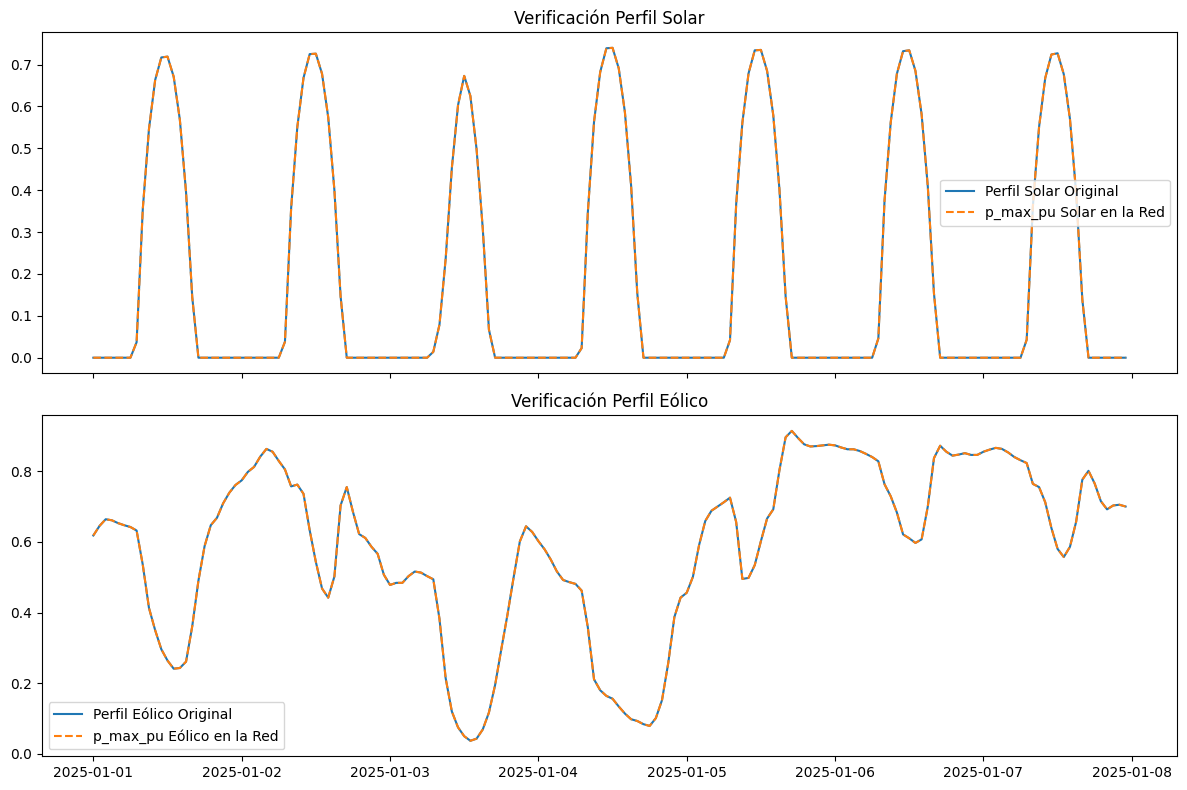

In [104]:
# Verificación de perfiles asignados correctamente: ES
ES_solar_profile.index = network.snapshots[:len(ES_solar_profile)]
ES_wind_profile.index = network.snapshots[:len(ES_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["ES_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["ES_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], ES_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], ES_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()



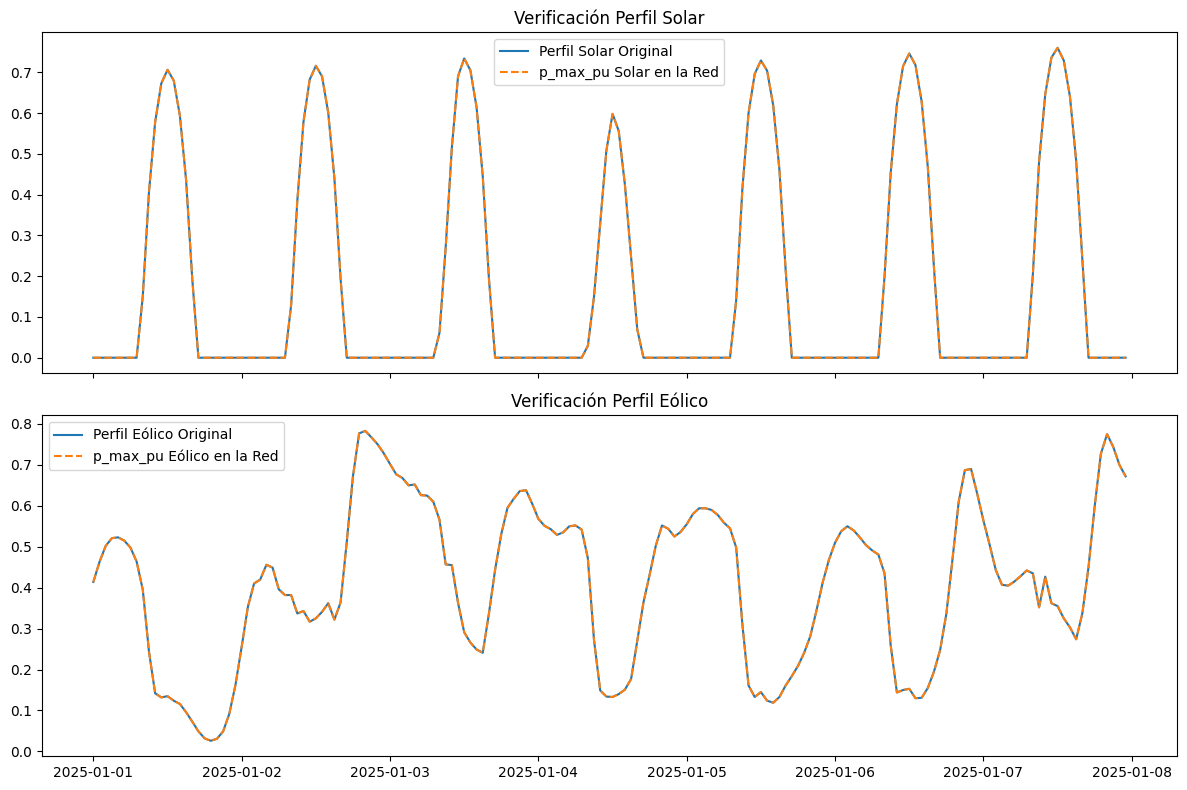

In [105]:
# Verificación de perfiles asignados correctamente: PT
PT_solar_profile.index = network.snapshots[:len(PT_solar_profile)]
PT_wind_profile.index = network.snapshots[:len(PT_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["PT_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["PT_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], PT_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], PT_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()


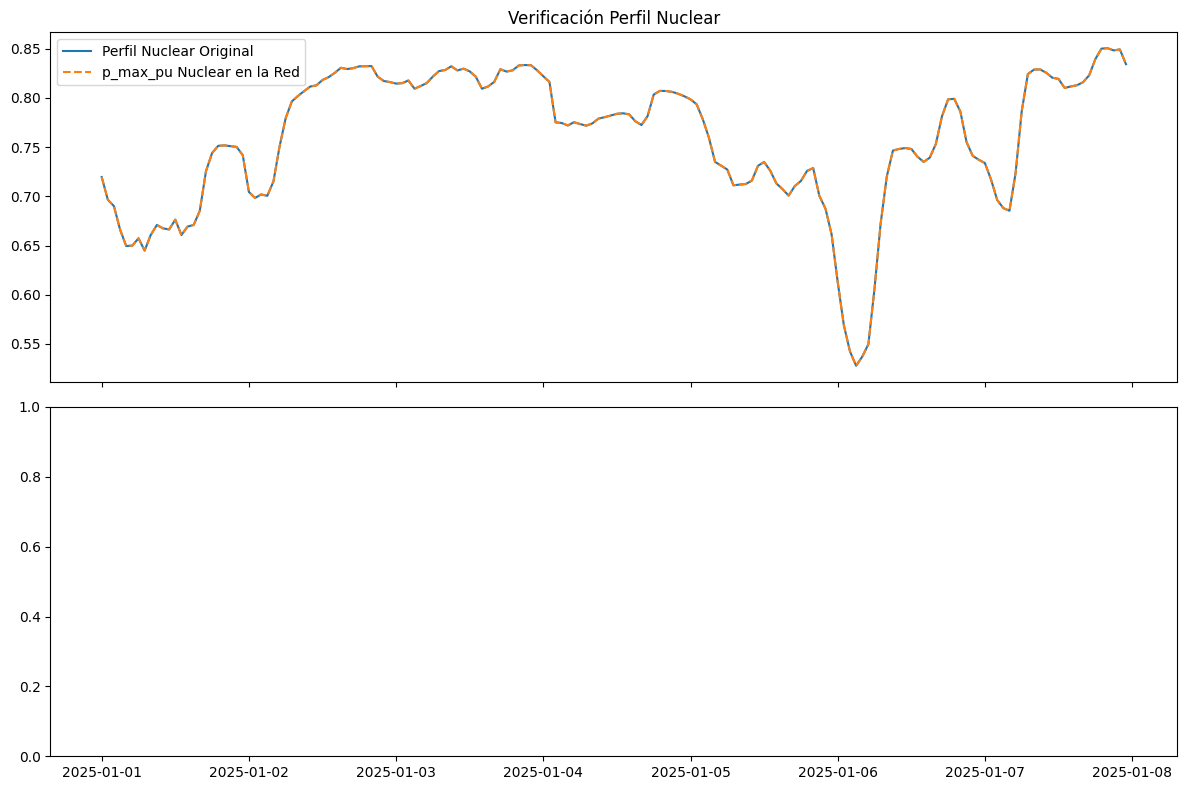

In [106]:
# Verificación de perfiles asignados correctamente: FR
FR_nuclear_profile.index = network.snapshots[:len(FR_nuclear_profile)]


# Extraer perfiles desde la red
nuclear_pm = network.generators.dynamic["p_max_pu"]["FR_nuclear"]


# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(nuclear_pm)], FR_nuclear_profile, label="Perfil Nuclear Original")
axes[0].plot(network.snapshots[:len(nuclear_pm)], nuclear_pm, linestyle="--", label="p_max_pu Nuclear en la Red")
axes[0].set_title("Verificación Perfil Nuclear")
axes[0].legend()

plt.tight_layout()
plt.show()


In [107]:
# LOADS

# CREAR SERIES DE DEMANDA
    #ESPAÑA
ES_demand_hydrogen_series = pd.Series(df_demand2040['ES_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
ES_demand_series = pd.Series(df_demand2040['ES_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)
    #PORTUGAL
PT_demand_hydrogen_series = pd.Series(df_demand2040['PT_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
PT_demand_series = pd.Series(df_demand2040['PT_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)

#Francia

FR_demand_hydrogen_series = pd.Series(df_demand2040['FR_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
FR_demand_series = pd.Series(df_demand2040['FR_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)


# Añadir variables estáticas
df_loads = data["loads"]
for _, load in df_loads.iterrows():
    network.add(
        "Load",
        load["name"].strip(),
        bus=load["bus"].strip(),
        carrier=load["carrier"].strip(),
        overwrite=load["overwrite"]
    )

# Asignar variables dinámicas
    #ESPAÑA
network.loads.dynamic["p_set"]["ES_hydrogen_demand"] = ES_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["ES_demand_2040"] = ES_demand_series.values
    #PORTUGAL
network.loads.dynamic["p_set"]["PT_hydrogen_demand"] = PT_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["PT_demand_2040"] = PT_demand_series.values
    #FRANCIA
network.loads.dynamic["p_set"]["FR_hydrogen_demand"] = FR_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["FR_demand_2040"] = FR_demand_series.values


# Verificación con API moderna
print("\n=== Loads estáticos ===")
print(network.loads.static)

print("\n=== Primeras filas de p_set dinámico ===")
print(network.loads.dynamic["p_set"].head())



=== Loads estáticos ===
                                          bus   carrier type  p_set  q_set  \
name                                                                         
ES_demand_2040      ES_electricity_market_bus        AC         0.0    0.0   
ES_hydrogen_demand            ES_hydrogen_bus  hydrogen         0.0    0.0   
PT_demand_2040      PT_electricity_market_bus        AC         0.0    0.0   
PT_hydrogen_demand            PT_hydrogen_bus  hydrogen         0.0    0.0   
FR_demand_2040      FR_electricity_market_bus        AC         0.0    0.0   
FR_hydrogen_demand            FR_hydrogen_bus  hydrogen         0.0    0.0   

                    sign  active  
name                              
ES_demand_2040      -1.0    True  
ES_hydrogen_demand  -1.0    True  
PT_demand_2040      -1.0    True  
PT_hydrogen_demand  -1.0    True  
FR_demand_2040      -1.0    True  
FR_hydrogen_demand  -1.0    True  

=== Primeras filas de p_set dinámico ===
name                 ES_hydr

In [108]:
df_links = data["links"]

for _, lk in df_links.iterrows():

    name = lk["name"].strip().lower()
    link_name = lk["name"].strip()

    # Detectar país desde bus0
    country = lk["bus0"][:2]   # ES / PT

    # Añadir link estático
    network.add(
        "Link",
        link_name,
        bus0=lk["bus0"].strip(),
        bus1=lk["bus1"].strip(),
        p_nom=lk["p_nom"],
        #p_max_pu=lk["p_max_pu"],
        #p_min_pu=lk["p_min_pu"],
        efficiency=lk["efficiency"],
        marginal_cost=lk["marginal_cost"],
        carrier=lk["carrier"],
        capital_cost=lk["capital_cost"],
        overwrite=lk["overwrite"]
    )



In [109]:
# Verificación
     
print("\n=== Resumen de todos los Links en la red ===")
print(network.links.static[['bus0','bus1','p_nom','efficiency','marginal_cost','carrier']])
for link_name in ["CCGT", "turbina", "pump", "electrolyzer"]:
        if link_name in network.links.static.index:
            row = network.links.static.loc[link_name]
            print(f"\n--- Detalle de {link_name} ---")
            print(f"Origen (bus0):        {row['bus0']}")
            print(f"Destino (bus1):       {row['bus1']}")
            print(f"Capacidad (p_nom):    {row['p_nom']} MW")
            print(f"Eficiencia:           {row['efficiency']*100:.1f}%")
            print(f"Coste marginal:       {row['marginal_cost']} €/MWh")
            print(f"Carrier:              {row['carrier']}")
            # Ramp limits solo para CCGT
            #if link_name == "CCGT":
            #    print(f"Ramp up limit:        {row['ramp_limit_up']} MW/h")
            #    print(f"Ramp down limit:      {row['ramp_limit_down']} MW/h")
        else:
            print(f"\n⚠️ El link '{link_name}' no se encontró en la red.")


=== Resumen de todos los Links en la red ===
                                                       bus0  \
name                                                          
ES_CCGT                                          ES_gas_bus   
ES_turbina                                     ES_water_bus   
ES_pump                           ES_electricity_market_bus   
ES_electrolyzer                   ES_electricity_market_bus   
ES_SRES_electrolyzer                            ES_SRES_bus   
ES_SRES_excedentes                              ES_SRES_bus   
PT_CCGT                                          PT_gas_bus   
PT_turbina                                     PT_water_bus   
PT_pump                           PT_electricity_market_bus   
PT_electrolyzer                   PT_electricity_market_bus   
PT_SRES_electrolyzer                            PT_SRES_bus   
PT_SRES_excedentes                              PT_SRES_bus   
ES_PT_interconexion_electricidad  ES_electricity_market_bus   
ES_PT_int

In [110]:
print("\nLINKS ESTÁTICOS:")
print(network.links.static.index)

print("\nCOLUMNAS EN p_max_pu:")
print(network.links.dynamic["p_max_pu"].columns)

print("\nCOLUMNAS EN p0:")
print(network.links_t.p0.columns)


LINKS ESTÁTICOS:
Index(['ES_CCGT', 'ES_turbina', 'ES_pump', 'ES_electrolyzer',
       'ES_SRES_electrolyzer', 'ES_SRES_excedentes', 'PT_CCGT', 'PT_turbina',
       'PT_pump', 'PT_electrolyzer', 'PT_SRES_electrolyzer',
       'PT_SRES_excedentes', 'ES_PT_interconexion_electricidad',
       'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_electricidad',
       'PT_ES_interconexion_hidrogeno', 'ES_FR_interconexion_electricidad',
       'FR_ES_interconexion_electricidad', 'ES_FR_interconexion_hidrogeno'],
      dtype='object', name='name')

COLUMNAS EN p_max_pu:
Index([], dtype='object', name='name')

COLUMNAS EN p0:
Index([], dtype='object', name='name')


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\4154381567.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [111]:

df_storage = data["storage_units"]

for _, st in df_storage.iterrows():
    name = st["name"].strip()

    soc0=0.5*st["p_nom"]*st["max_hours"]  # Estado de carga inicial al 50%

    # Añadir atributos estáticos
    network.add(
        "StorageUnit",
        name,
        bus=st["bus"].strip(),
        p_nom=st["p_nom"],
        max_hours=st["max_hours"],
        efficiency_store=st["efficiency_store"],
        efficiency_dispatch=st["efficiency_dispatch"],
        marginal_cost=st["marginal_cost"],
        carrier=st["carrier"],
        overwrite=st["overwrite"],
        #capital_cost=st("capital_cost"),  
        state_of_charge_initial= soc0, 
        cyclic_state_of_charge=False
    )

    print(f"✅ StorageUnit '{name}' añadida en bus {st['bus']}: {st['p_nom']} MW · {st['max_hours']} h")

# Verificación
print("\n=== Storage Units estáticos ===")
print(network.storage_units.static.head())

print("\n=== Storage Units dinámicos ===")
print(network.storage_units.dynamic.keys())


✅ StorageUnit 'ES_electricity_market_battery' añadida en bus ES_electricity_market_bus: 26698.52 MW · 4 h
✅ StorageUnit 'ES_hydrogen_storage' añadida en bus ES_hydrogen_bus: 10000.0 MW · 1000 h
✅ StorageUnit 'PT_electricity_market_battery' añadida en bus PT_electricity_market_bus: 3000.0 MW · 4 h

=== Storage Units estáticos ===
                                                     bus control type  \
name                                                                    
ES_electricity_market_battery  ES_electricity_market_bus      PQ        
ES_hydrogen_storage                      ES_hydrogen_bus      PQ        
PT_electricity_market_battery  PT_electricity_market_bus      PQ        

                                  p_nom  p_nom_mod  p_nom_extendable  \
name                                                                   
ES_electricity_market_battery  26698.52        0.0             False   
ES_hydrogen_storage            10000.00        0.0             False   
PT_electricity_

In [112]:
df_store = data["store"].copy()
 
# normaliza la columna a boolean REAL
df_store["cyclic_state_of_charge"] = (
    df_store["cyclic_state_of_charge"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False, "nan": False})
)
 
# si algo no mapea, lo dejamos en False (o lanza error si prefieres)
df_store["cyclic_state_of_charge"] = df_store["cyclic_state_of_charge"].fillna(False)

In [113]:


for _, store in df_store.iterrows():
    network.add(
        "Store",
        store["name"].strip(),
        bus=store["bus"].strip(),
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"],
        e_max_pu=store["e_max_pu"],
        e_cyclic=store["cyclic_state_of_charge"],
        #capital_cost=store["capital_cost"],
        marginal_cost=store["marginal_cost"],
        carrier=store["carrier"],
        overwrite=store["overwrite"]
    )

    print(f"✅ Store '{store['name']}' añadida en bus {store['bus']}: "
          f"{store['e_nom']} MWh · inicial {store['e_initial']} MWh · "
          f"min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · "
          f"coste marginal {store['marginal_cost']}")

# Verificación con API moderna
print("\n=== Stores estáticos ===")
print(network.stores.static.head())


✅ Store 'ES_embalse' añadida en bus ES_water_bus: 1387684000 MWh · inicial 1248915600 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1
✅ Store 'PT_embalse' añadida en bus PT_water_bus: 3307600 MWh · inicial 2976840 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1

=== Stores estáticos ===
                     bus type carrier         e_nom  e_nom_mod  \
name                                                             
ES_embalse  ES_water_bus        water  1.387684e+09        0.0   
PT_embalse  PT_water_bus        water  3.307600e+06        0.0   

            e_nom_extendable  e_nom_min  e_nom_max  e_nom_set  e_min_pu  ...  \
name                                                                     ...   
ES_embalse             False        0.0        inf        NaN       0.2  ...   
PT_embalse             False        0.0        inf        NaN       0.2  ...   

            sign  marginal_cost  marginal_cost_quadratic  \
name                                                       
ES_e

RESTRICCIONES

In [114]:
# Precio de CO2 y factor de emisión
co2_price = 50  # €/tCO2
emission_factor = 0.202  # tCO2/MWh

# Coste adicional por CO2
co2_cost = co2_price * emission_factor  # 20.2 €/MWh

# Acceso correcto en tu versión de PyPSA
network.links.df.loc["ES_CCGT", "marginal_cost"] += co2_cost
network.links.df.loc["PT_CCGT", "marginal_cost"] += co2_cost

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\3704443078.py:9: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\3704443078.py:10: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



# --- SOC inicial = el que ya tienes en Excel/código (state_of_charge_initial)
# --- SOC final = 50% (constraint)

def fix_batt_soc_final_50pct(n, snapshots):
    su = n.storage_units.static

    batt = [b for b in ["ES_electricity_market_battery", "PT_electricity_market_battery", "ES_hydrogen_storage"] if b in su.index]
    if not batt:
        raise ValueError("No encuentro ES/PT electricity_market_battery en storage_units.static")

   # Energía máxima (MWh) = p_nom * max_hours
    emax = su.loc[batt, "p_nom"].astype(float) * su.loc[batt, "max_hours"].astype(float)
    target = 0.5 * emax  # 50%

    tN = snapshots[-1]
    soc = n.model["StorageUnit-state_of_charge"]

    # Fijar SOC FINAL al 50%
    n.model.add_constraints(
        soc.loc[tN, batt] >= target.values,
        name="fix_soc_final_50pct"
    )

# Asegura que NO es cyclic (si no, puede ignorar/alterar el inicial)
su = network.storage_units.static
mask_batt = su.index.str.contains("electricity_market_battery", case=False)
su.loc[mask_batt, "cyclic_state_of_charge"] = False

In [115]:
def enforce_soc_min_start_end_50pct(n, snapshots):
    su = n.storage_units.static

    batt = [b for b in ["ES_electricity_market_battery",
                        "PT_electricity_market_battery",
                        "ES_hydrogen_storage"]
            if b in su.index]
    if not batt:
        raise ValueError("No encuentro baterías/almacenamientos objetivo en storage_units.static")

    # Emax = p_nom * max_hours (MWh)
    emax = su.loc[batt, "p_nom"].astype(float) * su.loc[batt, "max_hours"].astype(float)
    target = 0.5 * emax  # 50%

    # Asegura SOC inicial del parámetro = 50%
    su.loc[batt, "state_of_charge_initial"] = target.values
    su.loc[batt, "cyclic_state_of_charge"] = False

    soc = n.model["StorageUnit-state_of_charge"]

    t0 = snapshots[0]
    tN = snapshots[-1]

    # SOC al final de la 1ª hora >= 50%
    n.model.add_constraints(
        soc.loc[t0, batt] >= target.values,
        name="soc_min_50pct_at_t0"
    )

    # SOC al final de la última hora >= 50%
    n.model.add_constraints(
        soc.loc[tN, batt] >= target.values,
        name="soc_min_50pct_at_tN"
    )

In [116]:
import numpy as np
import xarray as xr

def enforce_sres_h2_priority_hard(n, snapshots, countries=("ES","PT"), tol=0.0):
    """
    Restricción DURA:
        Link-p (SRES_electrolyzer) >= rhs(t)
    donde rhs(t)=min(D_H2/eff, SRES_avail, p_nom_ely).

    tol permite relajar un pelín por tolerancias numéricas (p.ej. 1e-3).
    """
    m = n.model
    p_link = m.variables["Link-p"]

    # detectar dims
    dims = list(p_link.dims)
    snap_dim = "snapshot" if "snapshot" in dims else dims[0]
    link_dim = [d for d in dims if d != snap_dim][0]

    links = n.links.static
    gens  = n.generators.static

    # p_max_pu (por seguridad)
    pmax = n.generators_t.p_max_pu.reindex(snapshots).fillna(0.0)

    for c in countries:
        l_ely = f"{c}_SRES_electrolyzer"
        if l_ely not in links.index:
            continue

        eff = float(links.at[l_ely, "efficiency"])
        cap = float(links.at[l_ely, "p_nom"])

        load = f"{c}_hydrogen_demand"
        h2 = n.loads_t.p_set[load].reindex(snapshots).fillna(0.0).values  # MW_H2  
        req = h2 / eff                                                    # MW_e

        sres_bus = f"{c}_SRES_bus"
        gens_sres = gens.index[gens["bus"] == sres_bus]
        if len(gens_sres) == 0:
            raise KeyError(f"No hay generadores en {sres_bus}")

        p_nom = gens.loc[gens_sres, "p_nom"].astype(float)
        avail = (pmax[gens_sres].mul(p_nom, axis=1)).sum(axis=1).values   # MW_e

        rhs = np.minimum(req, np.minimum(avail, cap))                     # MW_e

        rhs_da = xr.DataArray(rhs, coords={snap_dim: snapshots}, dims=[snap_dim])

        p_ely = p_link.sel({link_dim: l_ely, snap_dim: snapshots})

        # OJO: si descubres que el signo va al revés, cambia a (-p_ely >= rhs_da - tol)
        m.add_constraints(p_ely == rhs_da - tol, name=f"{c}_sres_ely_min_for_h2_hard")

In [117]:
def extra_functionality_combined(n, snapshots):
    enforce_soc_min_start_end_50pct(n, snapshots)
    enforce_sres_h2_priority_hard(n, snapshots, countries=("ES","PT"), tol=1e-3)

PARTE III: OPTIMIZACIÓN

In [118]:
network.optimize(
    solver_name="highs",
    extra_functionality=extra_functionality_combined
)

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\3380068504.py:24: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\3380068504.py:35: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\3380068504.py:35: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.25s
Status: warning
Termination condition: infeasible
Solution: 0 primals, 0 duals
Objective: nan
Solver model: available
Solv

('warning', 'infeasible')

In [119]:
b = "PT_electricity_market_battery"

su = network.storage_units.static.loc[b]
Emax = float(su.p_nom) * float(su.max_hours)

soc_initial_param = float(su.state_of_charge_initial)
print("SOC inicial (param) %:", 100*soc_initial_param/Emax)

# y el SOC al final de la primera hora:
t0 = network.snapshots[0]
soc_t0 = float(network.storage_units_t.state_of_charge.loc[t0, b])
print("SOC en t0 (fin 1ª hora) %:", 100*soc_t0/Emax)

SOC inicial (param) %: 50.0


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_16240\4034907928.py:11: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



KeyError: 'PT_electricity_market_battery'

PARTE IV: OBTENCIÓN DE RESULTADOS.

In [ ]:
# Guardar resultados en un archivo Excel
network.export_to_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos.xlsx",
    engine="openpyxl"
)

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos.xlsx contains: carriers, storage_units, links, sub_networks, stores, loads, generators, buses


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:33: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:45: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:49: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:50: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:65: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:78: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be rem

Links dibujados: ['ES_PT_interconexion_electricidad', 'PT_ES_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_hidrogeno', 'ES_electrolyzer', 'PT_electrolyzer']
ES elec<->ES H2 detectado: ['ES_electrolyzer']
PT elec<->PT H2 detectado: ['PT_electrolyzer']


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:315: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:317: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:410: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:411: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:410: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykern

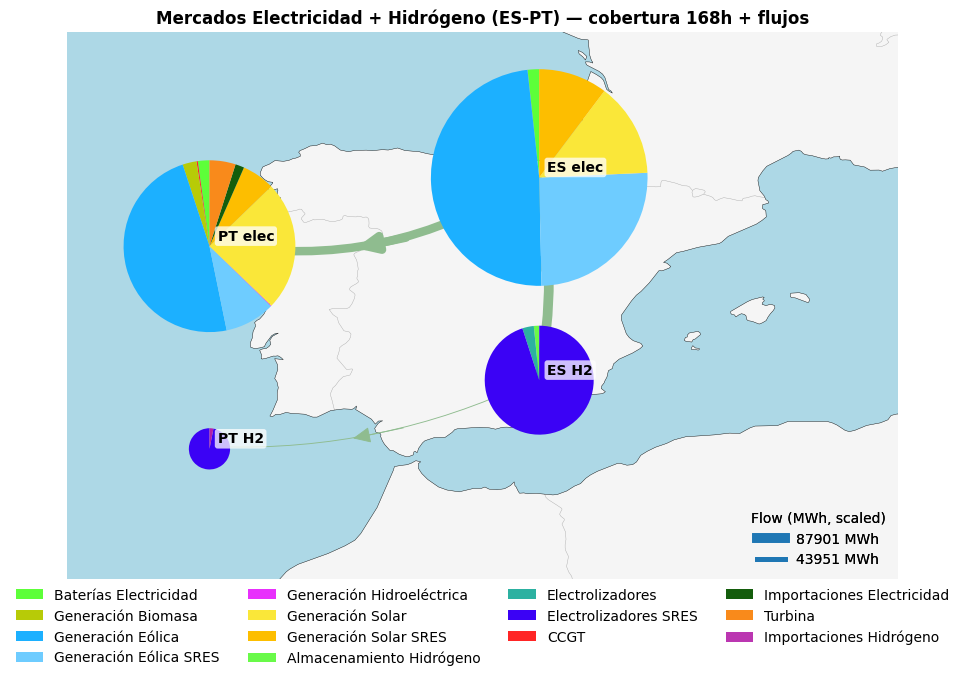

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2850427374.py:482: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [ ]:
# ============================================================
# MAPA "IMAGEN 1" — PIES = COBERTURA DEMANDA (ETIQUETAS CLARAS)
#  MOD: dividir SRES excedentes en SRES solar + SRES eólica
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot import add_legend_lines, add_legend_patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

n = network

# ------------------------------
# 0) Ajustes visuales
# ------------------------------
extent_iberia = (-14.0, 6.5, 33.0, 46.5)

dx, dy = 1.35, 2.50
bus_size_factor = 1e6

# ------------------------------
# 1) Buses objetivo
# ------------------------------
b_e_es = "ES_electricity_market_bus"
b_h_es = "ES_hydrogen_bus"
b_e_pt = "PT_electricity_market_bus"
b_h_pt = "PT_hydrogen_bus"

wanted_buses = [b_e_es, b_h_es, b_e_pt, b_h_pt]
wanted_buses = [b for b in wanted_buses if b in n.buses.df.index]
wanted_bus_set = set(wanted_buses)

# ------------------------------
# 2) Links a dibujar
# ------------------------------
links_cross = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]
links_cross = [l for l in links_cross if hasattr(n, "links") and l in n.links.df.index]

es_internal_links, pt_internal_links = [], []
internal_links = []
if hasattr(n, "links") and len(n.links.df):
    L = n.links.df

    def find_internal(prefix):
        be = f"{prefix}_electricity_market_bus"
        bh = f"{prefix}_hydrogen_bus"
        mask = (((L.bus0 == be) & (L.bus1 == bh)) | ((L.bus0 == bh) & (L.bus1 == be)))
        return list(L.index[mask])

    es_internal_links = find_internal("ES")
    pt_internal_links = find_internal("PT")
    internal_links = es_internal_links + pt_internal_links

wanted_links = list(dict.fromkeys(links_cross + internal_links))

if hasattr(n, "links") and len(wanted_links):
    Lsel = n.links.df.loc[wanted_links, ["bus0", "bus1"]]
    wanted_links = [
        l for l in wanted_links
        if (Lsel.loc[l, "bus0"] in wanted_bus_set) and (Lsel.loc[l, "bus1"] in wanted_bus_set)
    ]

print("Links dibujados:", wanted_links)
print("ES elec<->ES H2 detectado:", es_internal_links)
print("PT elec<->PT H2 detectado:", pt_internal_links)

# ------------------------------
# 3) Reposicionar buses
# ------------------------------
orig_xy = n.buses.df.loc[wanted_buses, ["x", "y"]].copy()

def is_elec(bus): return "electricity_market" in bus
def is_h2(bus):   return "hydrogen" in bus

base = orig_xy.copy()
new_xy = base.copy()

for b in new_xy.index:
    x0, y0 = base.loc[b, ["x", "y"]]
    if b.startswith("ES_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 - dy]
    if b.startswith("PT_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 - dy]

n.buses.df.loc[wanted_buses, ["x","y"]] = new_xy

# ------------------------------
# 4) Helpers de tecnologías
# ------------------------------
def tech_from_generator(name, carrier):
    cl = str(carrier).lower()
    if "load_shedding" in cl or "shedding" in cl:
        return None
    if "solar" in cl: return "Generación Solar"
    if "wind"  in cl: return "Generación Eólica"
    if "water" in cl or "hydro" in cl: return "Generación Hidroeléctrica"
    if "biomass" in cl: return "Generación Biomasa"
    return str(carrier)

def tech_from_link(name, bus0, bus1):
    nl = str(name).lower()
    if "load_shedding" in nl or "shedding" in nl:
        return None
    if "interconexion" in nl and "electricidad" in nl: return "Importaciones Electricidad"
    if "interconexion" in nl and "hidrogeno" in nl:    return "Importaciones Hidrógeno"
    if "ccgt" in nl: return "CCGT"
    if "turbina" in nl or "turbine" in nl: return "Turbina"

    # 👇 OJO: ya NO devolvemos "Excedentes SRES"
    # lo vamos a dividir a mano en 6.B
    if "sres" in nl and "exced" in nl: return "SRES_EXCEDENTES_SPLIT_ME"

    if "sres" in nl and "electrolyzer" in nl: return "Electrolizadores SRES"
    if "electrolyzer" in nl or "electrol" in nl: return "Electrolizadores"
    if "pump" in nl: return "Bomba/Pump"
    return str(name)

def tech_from_storage(name, carrier):
    nl = str(name).lower()
    cl = str(carrier).lower()
    if "battery" in nl or "battery" in cl: return "Baterías Electricidad"
    if "hydrogen" in nl or "hydrogen" in cl or "h2" in nl: return "Almacenamiento Hidrógeno"
    return str(carrier)

# ------------------------------
# 5) dt para MW -> MWh
# ------------------------------
T = n.snapshots
dt_h = (T[1] - T[0]).total_seconds() / 3600.0 if len(T) > 1 else 1.0

# ------------------------------
# 6) PIES = COBERTURA (MWh en 168h)
# ------------------------------
rows = []

def add_mwh(bus, tech, series_mw):
    if bus not in wanted_bus_set:
        return
    if tech is None or series_mw is None:
        return
    s = series_mw.reindex(T).fillna(0.0)
    mwh = float((s * dt_h).sum())
    if mwh > 1e-6:
        rows.append((bus, tech, mwh))

# Helper: split SRES excedentes en solar/wind (por país)
def split_sres_excedentes_to_solar_wind(n, country, aporte_mw):
    """
    aporte_mw: Series MW que entra al mercado elec desde el link SRES_excedentes.
    Devuelve (aporte_solar, aporte_wind) en MW, repartidos por generación SRES solar/wind real.
    """
    sres_bus = f"{country}_SRES_bus"
    gens = n.generators.df
    gens_sres = gens.index[gens["bus"] == sres_bus]

    if len(gens_sres) == 0:
        # si no hay gens en SRES_bus, no podemos repartir
        zero = aporte_mw * 0.0
        return zero, zero

    # generación SRES solar/wind (MW)
    carriers = gens.loc[gens_sres, "carrier"].astype(str).str.lower()
    gens_solar = list(gens_sres[carriers.str.contains("solar")])
    gens_wind  = list(gens_sres[carriers.str.contains("wind")])

    p = n.generators_t.p.reindex(T).fillna(0.0)

    solar = p[gens_solar].sum(axis=1) if len(gens_solar) else pd.Series(0.0, index=T)
    wind  = p[gens_wind].sum(axis=1)  if len(gens_wind)  else pd.Series(0.0, index=T)
    total = (solar + wind)

    # reparto proporcional (evita 0/0)
    share_solar = solar.div(total.where(total > 0.0, np.nan)).fillna(0.0)
    share_wind  = wind.div(total.where(total > 0.0, np.nan)).fillna(0.0)

    return aporte_mw * share_solar, aporte_mw * share_wind


# 6.A Electricidad: Generators -> elec buses
if hasattr(n, "generators") and len(n.generators.df):
    g = n.generators.df.copy()
    g = g[g.bus.isin([b_e_es, b_e_pt])]
    for name, row in g.iterrows():
        if name in n.generators_t.p.columns:
            tech = tech_from_generator(name, row["carrier"])
            add_mwh(row["bus"], tech, n.generators_t.p[name].clip(lower=0))

# 6.B Electricidad: Links que entregan al mercado elec (aporte = -p1 negativo)
if hasattr(n, "links") and len(n.links.df) and hasattr(n, "links_t") and hasattr(n.links_t, "p1"):
    Ldf = n.links.df.copy()
    Lin_e = Ldf[Ldf.bus1.isin([b_e_es, b_e_pt])]

    for name, row in Lin_e.iterrows():
        if name not in n.links_t.p1.columns:
            continue

        tech = tech_from_link(name, row["bus0"], row["bus1"])
        aporte = (-n.links_t.p1[name].clip(upper=0))  # MW que entra al bus1 (mercado elec)

        # 👇 AQUI: split de SRES excedentes a SRES solar + SRES eólica
        if tech == "SRES_EXCEDENTES_SPLIT_ME":
            country = row["bus1"][:2]  # "ES" o "PT" (porque bus1 es ES_elec o PT_elec)
            aporte_solar, aporte_wind = split_sres_excedentes_to_solar_wind(n, country, aporte)

            add_mwh(row["bus1"], "Generación Solar SRES", aporte_solar)
            add_mwh(row["bus1"], "Generación Eólica SRES", aporte_wind)
        else:
            add_mwh(row["bus1"], tech, aporte)

# 6.C Electricidad: StorageUnits descarga -> elec buses
if hasattr(n, "storage_units") and len(n.storage_units.df):
    su = n.storage_units.df.copy()
    su = su[su.bus.isin([b_e_es, b_e_pt])]
    for name, row in su.iterrows():
        if name in n.storage_units_t.p.columns:
            tech = tech_from_storage(name, row["carrier"])
            add_mwh(row["bus"], tech, n.storage_units_t.p[name].clip(lower=0))

# 6.D Hidrógeno: Links que entregan a bus H2 (aporte = -p1 negativo)
if hasattr(n, "links") and len(n.links.df) and hasattr(n, "links_t") and hasattr(n.links_t, "p1"):
    Ldf = n.links.df.copy()
    Lin_h2 = Ldf[Ldf.bus1.isin([b_h_es, b_h_pt])]
    for name, row in Lin_h2.iterrows():
        if name not in n.links_t.p1.columns:
            continue
        tech = tech_from_link(name, row["bus0"], row["bus1"])
        aporte_h2 = (-n.links_t.p1[name].clip(upper=0))
        add_mwh(row["bus1"], tech, aporte_h2)

# 6.E Hidrógeno: StorageUnits descarga -> H2 buses
if hasattr(n, "storage_units") and len(n.storage_units.df):
    su = n.storage_units.df.copy()
    su = su[su.bus.isin([b_h_es, b_h_pt])]
    for name, row in su.iterrows():
        if name in n.storage_units_t.p.columns:
            tech = tech_from_storage(name, row["carrier"])
            add_mwh(row["bus"], tech, n.storage_units_t.p[name].clip(lower=0))

eb = pd.Series(
    data=[r[2] for r in rows],
    index=pd.MultiIndex.from_tuples([(r[0], r[1]) for r in rows], names=["bus", "tech"])
).groupby(["bus", "tech"]).sum()

eb_plot = eb.copy()
eb_plot.index = eb_plot.index.set_names(["bus", "carrier"])

# ------------------------------
# 7) Colores por tech (añadimos SRES solar/wind)
# ------------------------------
techs = list(eb_plot.index.get_level_values("carrier").unique())

tech_color = {}
for t in techs:
    tl = str(t).lower()
    if tl == "electrolizadores":                 tech_color[t] = "#2CB1A1"
    elif tl == "electrolizadores sres":          tech_color[t] = "#3B02F5"
    elif tl == "importaciones hidrógeno":        tech_color[t] = "#B41FA8E5"
    elif tl == "almacenamiento hidrógeno":       tech_color[t] = "#69FA49"
    elif tl == "generación eólica":              tech_color[t] = "#1CB0FF"
    elif tl == "generación solar":               tech_color[t] = "#FAE739"
    elif tl == "generación hidroeléctrica":      tech_color[t] = "#E830FC"
    elif tl == "generación biomasa":             tech_color[t] = "#B7CB07"
    elif tl == "ccgt" or "gas" in tl:            tech_color[t] = "#FF2525"
    elif tl == "turbina":                        tech_color[t] = "#F98A1B"
    elif tl == "importaciones electricidad":     tech_color[t] = "#145D0C"
    elif "baterías electricidad" in tl:          tech_color[t] = "#5DFF39"

    # 👇 NUEVOS: SRES solar/wind en el mercado eléctrico
    elif tl == "generación solar sres":          tech_color[t] = "#FDBE00"
    elif tl == "generación eólica sres":         tech_color[t] = "#6ECCFF"
    else:                                        tech_color[t] = "#BAB0AC"



# carriers temporales con color
if "color" not in n.carriers.df.columns:
    n.carriers.df["color"] = pd.NA
n.carriers.df["color"] = n.carriers.df["color"].replace("", pd.NA)

for t in techs:
    if t not in n.carriers.df.index:
        n.add("Carrier", t)
    n.carriers.df.loc[t, "color"] = tech_color[t]

# ------------------------------
# 8) Plot base + pies (links PyPSA invisibles)
# ------------------------------
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
empty_link_widths = pd.Series(0.0, index=n.links.df.index)

n.plot(
    ax=ax,
    geomap_color=True,
    bus_sizes=(eb_plot / bus_size_factor) if len(eb_plot) else None,
    bus_split_circle=False,
    link_widths=empty_link_widths,
)

ax.set_extent(extent_iberia, crs=ccrs.PlateCarree())
ax.set_title("Mercados Electricidad + Hidrógeno (ES-PT) — cobertura 168h + flujos", fontweight="bold")

# ------------------------------
# 9) Links curvos (igual que tu versión)
# ------------------------------
Ldf = n.links.df
if len(wanted_links):
    p0 = n.links_t.p0[wanted_links].reindex(T).fillna(0.0)
    e_fwd = (p0.clip(lower=0) * dt_h).sum(axis=0)
    e_rev = ((-p0.clip(upper=0)) * dt_h).sum(axis=0)
else:
    e_fwd = pd.Series(dtype=float)
    e_rev = pd.Series(dtype=float)

RAD = {
    ("ES_PT_interconexion_electricidad", "fwd"): +0.20,
    ("ES_PT_interconexion_electricidad", "rev"): -0.20,
    ("PT_ES_interconexion_electricidad", "fwd"): +0.20,
    ("PT_ES_interconexion_electricidad", "rev"): -0.20,
    ("ES_PT_interconexion_hidrogeno",    "fwd"): +0.12,
    ("ES_PT_interconexion_hidrogeno",    "rev"): -0.12,
    ("PT_ES_interconexion_hidrogeno",    "fwd"): +0.12,
    ("PT_ES_interconexion_hidrogeno",    "rev"): -0.12,
}
for l in (es_internal_links + pt_internal_links):
    RAD.setdefault((l, "fwd"), +0.10)
    RAD.setdefault((l, "rev"), -0.10)

maxE = float(pd.concat([e_fwd, e_rev]).max()) if (len(e_fwd) or len(e_rev)) else 1.0
def lw(E):
    return max(0.6, 7.0 * (float(E) / maxE))

def shrink_endpoints(x0, y0, x1, y1, shrink_deg=0.25):
    dx_ = x1 - x0
    dy_ = y1 - y0
    dist = float(np.hypot(dx_, dy_))
    if dist < 1e-9:
        return x0, y0, x1, y1
    ux, uy = dx_ / dist, dy_ / dist
    return (x0 + shrink_deg*ux, y0 + shrink_deg*uy,
            x1 - shrink_deg*ux, y1 - shrink_deg*uy)

def draw_curved_mid_arrow(ax, x0, y0, x1, y1, rad, width, color,
                          alpha=0.95, arrow_len_frac=0.18, shrink_deg=0.25):
    x0, y0, x1, y1 = shrink_endpoints(x0, y0, x1, y1, shrink_deg=shrink_deg)

    dx_ = x1 - x0
    dy_ = y1 - y0
    dist = float(np.hypot(dx_, dy_))
    if dist < 1e-9:
        return

    nx, ny = -dy_ / dist, dx_ / dist
    mx, my = 0.5*(x0 + x1), 0.5*(y0 + y1)
    cx, cy = mx + rad * dist * nx, my + rad * dist * ny

    path = Path([(x0, y0), (cx, cy), (x1, y1)],
                [Path.MOVETO, Path.CURVE3, Path.CURVE3])

    curve = FancyArrowPatch(
        path=path,
        arrowstyle='-',
        linewidth=width,
        color=color,
        alpha=1,
        transform=ccrs.PlateCarree(),
        zorder=3
    )
    ax.add_patch(curve)

    t = 0.5
    xm = (1-t)**2*x0 + 2*(1-t)*t*cx + t**2*x1
    ym = (1-t)**2*y0 + 2*(1-t)*t*cy + t**2*y1

    tx = 2*(1-t)*(cx - x0) + 2*t*(x1 - cx)
    ty = 2*(1-t)*(cy - y0) + 2*t*(y1 - cy)
    norm = float(np.hypot(tx, ty))
    if norm < 1e-9:
        return
    tx, ty = tx / norm, ty / norm

    arrow_len = arrow_len_frac * dist
    xa0, ya0 = xm - 0.5*arrow_len*tx, ym - 0.5*arrow_len*ty
    xa1, ya1 = xm + 0.5*arrow_len*tx, ym + 0.5*arrow_len*ty

    arrow = FancyArrowPatch(
        (xa0, ya0), (xa1, ya1),
        arrowstyle="-|>,head_length=11,head_width=5",
        linewidth=width,
        color=color,
        alpha=1,
        mutation_scale=1,
        transform=ccrs.PlateCarree(),
        zorder=3
    )
    ax.add_patch(arrow)

for l in wanted_links:
    b0 = Ldf.at[l, "bus0"]
    b1 = Ldf.at[l, "bus1"]
    x0, y0 = n.buses.df.loc[b0, ["x", "y"]]
    x1, y1 = n.buses.df.loc[b1, ["x", "y"]]

    is_internal = (b0[:3] == b1[:3])
    _shrink = 0.10 if is_internal else 0.25
    _alen   = 0.12 if is_internal else 0.18

    Ef = float(e_fwd.get(l, 0.0))
    if Ef > 1e-6:
        draw_curved_mid_arrow(
            ax, x0, y0, x1, y1,
            rad=RAD.get((l, "fwd"), +0.15),
            width=lw(Ef),
            color="darkseagreen",
            alpha=0.95,
            arrow_len_frac=_alen,
            shrink_deg=_shrink
        )

    Er = float(e_rev.get(l, 0.0))
    if Er > 1e-6:
        draw_curved_mid_arrow(
            ax, x1, y1, x0, y0,
            rad=RAD.get((l, "rev"), -0.15),
            width=lw(Er),
            color="darkseagreen",
            alpha=0.95,
            arrow_len_frac=_alen,
            shrink_deg=_shrink
        )

# ------------------------------
# 10) Etiquetas buses
# ------------------------------
label_map = {b_e_es:"ES elec", b_h_es:"ES H2", b_e_pt:"PT elec", b_h_pt:"PT H2"}
for b in wanted_buses:
    x, y = n.buses.df.loc[b, ["x", "y"]]
    ax.text(
        x + 0.20, y + 0.15, label_map.get(b, b),
        transform=ccrs.PlateCarree(),
        fontsize=10, fontweight="bold",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

# ------------------------------
# 11) Leyendas
# ------------------------------
if len(techs):
    add_legend_patches(
        ax,
        colors=[tech_color[t] for t in techs],
        labels=[str(t) for t in techs],
        legend_kw={"loc": "lower center", "bbox_to_anchor": (0.5, -0.18), "ncol": 4, "frameon": False},
    )

if (len(e_fwd) or len(e_rev)):
    maxf = max(float(e_fwd.max() if len(e_fwd) else 0.0),
               float(e_rev.max() if len(e_rev) else 0.0))
    add_legend_lines(
        ax,
        sizes=[lw(maxf), lw(0.5*maxf)],
        labels=[f"{maxf:.0f} MWh", f"{0.5*maxf:.0f} MWh"],
        legend_kw={"loc": "lower right", "frameon": False, "title": "Flow (MWh, scaled)"},
    )

plt.tight_layout()
plt.show()

# ------------------------------
# 12) Restaurar coords
# ------------------------------
n.buses.df.loc[wanted_buses, ["x","y"]] = orig_xy

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:39: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:51: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:55: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:66: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:77: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:94: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be rem

Links dibujados: ['ES_PT_interconexion_electricidad', 'PT_ES_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_hidrogeno', 'PT_electrolyzer']


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:309: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:309: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:309: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:309: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



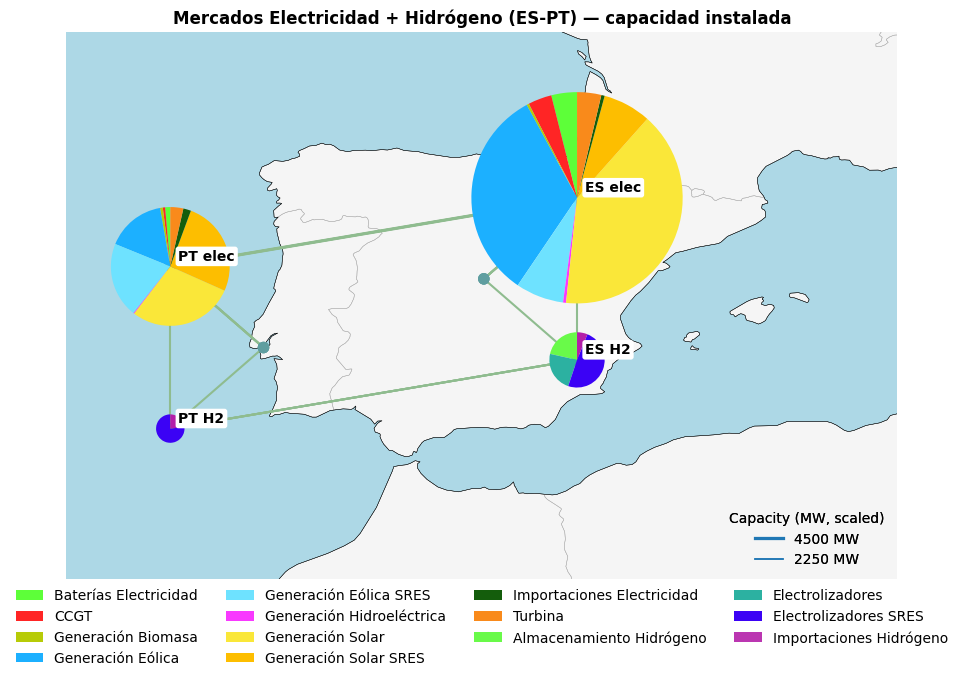

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3633272395.py:341: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [ ]:
# ============================================================
# MAPA "CAPACIDAD INSTALADA" — MISMO FORMATO QUE TU FOTO
#  - 4 buses: ES/PT electricidad + H2
#  - Pies = capacidad instalada (MW) por tecnología
#  - Links = capacidad instalada (MW) (sin flechas de flow)
#  MOD:
#   ✅ dividir SRES excedentes en "Generación Solar SRES" + "Generación Eólica SRES"
#   ✅ nombres/colores en español como indicas
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot import add_legend_lines, add_legend_patches

n = network

# ------------------------------
# 0) Ajustes visuales (igual que tu mapa)
# ------------------------------
extent_iberia = (-14.0, 6.5, 33.0, 46.5)

dx, dy = 2.3, 2.0# separación buses

bus_size_factor     = 1e5 # baja => pies más grandes
branch_width_factor = 2e3   # baja => links más gordos
branch_flow_factor  = 1e1   # (no se usa aquí)

# ------------------------------
# 1) Buses objetivo
# ------------------------------
b_e_es = "ES_electricity_market_bus"
b_h_es = "ES_hydrogen_bus"
b_e_pt = "PT_electricity_market_bus"
b_h_pt = "PT_hydrogen_bus"

wanted_buses = [b_e_es, b_h_es, b_e_pt, b_h_pt]
wanted_buses = [b for b in wanted_buses if b in n.buses.df.index]
wanted_bus_set = set(wanted_buses)

# ------------------------------
# 2) Links a dibujar (interconexiones + PT elec<->PT H2 auto)
# ------------------------------
links_cross = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]
links_cross = [l for l in links_cross if l in n.links.df.index]

# Detecta PT elec <-> PT H2 automáticamente (si existe)
pt_internal_links = []
L = n.links.df
mask = (
    ((L.bus0 == b_e_pt) & (L.bus1 == b_h_pt)) |
    ((L.bus0 == b_h_pt) & (L.bus1 == b_e_pt))
)
pt_internal_links = list(L.index[mask])

wanted_links = list(dict.fromkeys(links_cross + pt_internal_links))

# Filtra links que conecten SOLO entre los 4 buses
if len(wanted_links):
    Lsel = n.links.df.loc[wanted_links, ["bus0", "bus1"]]
    wanted_links = [
        l for l in wanted_links
        if (Lsel.loc[l, "bus0"] in wanted_bus_set) and (Lsel.loc[l, "bus1"] in wanted_bus_set)
    ]

print("Links dibujados:", wanted_links)

# ------------------------------
# 3) Reposicionar buses (sin solape) = igual que tu mapa
# ------------------------------
orig_xy = n.buses.df.loc[wanted_buses, ["x", "y"]].copy()

def is_elec(bus): return "electricity_market" in bus
def is_h2(bus):   return "hydrogen" in bus

base = orig_xy.copy()
new_xy = base.copy()

for b in new_xy.index:
    x0, y0 = base.loc[b, ["x", "y"]]
    if b.startswith("ES_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 - dy]
    if b.startswith("PT_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 - dy]

n.buses.df.loc[wanted_buses, ["x","y"]] = new_xy

# ------------------------------
# 4) Helpers de tecnologías (TU BLOQUE en español)
# ------------------------------
def tech_from_generator(name, carrier):
    cl = str(carrier).lower()
    if "load_shedding" in cl or "shedding" in cl:
        return None
    if "solar" in cl: return "Generación Solar"
    if "wind"  in cl: return "Generación Eólica"
    if "water" in cl or "hydro" in cl: return "Generación Hidroeléctrica"
    if "biomass" in cl: return "Generación Biomasa"
    return str(carrier)

def tech_from_link(name, bus0, bus1):
    nl = str(name).lower()
    if "load_shedding" in nl or "shedding" in nl:
        return None
    if "interconexion" in nl and "electricidad" in nl: return "Importaciones Electricidad"
    if "interconexion" in nl and "hidrogeno" in nl:    return "Importaciones Hidrógeno"
    if "ccgt" in nl: return "CCGT"
    if "turbina" in nl or "turbine" in nl: return "Turbina"

    # 👇 lo dividimos a mano en el paso 5.C
    if "sres" in nl and "exced" in nl: return "SRES_EXCEDENTES_SPLIT_ME"

    if "sres" in nl and "electrolyzer" in nl: return "Electrolizadores SRES"
    if "electrolyzer" in nl or "electrol" in nl: return "Electrolizadores"
    if "pump" in nl: return "Bomba/Pump"
    return str(name)

def tech_from_storage(name, carrier):
    nl = str(name).lower()
    cl = str(carrier).lower()
    if "battery" in nl or "battery" in cl: return "Baterías Electricidad"
    if "hydrogen" in nl or "hydrogen" in cl or "h2" in nl: return "Almacenamiento Hidrógeno"
    return str(carrier)

# ------------------------------
# 5) Construir PIES = CAPACIDAD INSTALADA (MW)
# ------------------------------
rows = []

def add_cap(bus, tech, cap_mw):
    if bus not in wanted_bus_set:
        return
    cap_mw = float(cap_mw)
    if tech is None:
        return
    if cap_mw > 1e-6:
        rows.append((bus, tech, cap_mw))

def p_nom_like(df, name):
    if "p_nom_opt" in df.columns and pd.notna(df.loc[name, "p_nom_opt"]):
        return float(df.loc[name, "p_nom_opt"])
    return float(df.loc[name, "p_nom"])

# Helper: split SRES excedentes en solar/wind (por país) usando CAPACIDAD en *_SRES_bus
def split_sres_excedentes_cap_to_solar_wind(n, country, cap_mw):
    """
    cap_mw: MW de capacidad del link SRES_excedentes que entra al mercado elec.
    Se reparte proporcionalmente a la capacidad instalada SRES solar/wind en {country}_SRES_bus.
    """
    sres_bus = f"{country}_SRES_bus"
    gens = n.generators.df
    gens_sres = gens.index[gens["bus"] == sres_bus]

    if len(gens_sres) == 0:
        return 0.0, 0.0

    carriers = gens.loc[gens_sres, "carrier"].astype(str).str.lower()
    gens_solar = list(gens_sres[carriers.str.contains("solar")])
    gens_wind  = list(gens_sres[carriers.str.contains("wind")])

    solar_cap = 0.0
    wind_cap  = 0.0

    for g in gens_solar:
        solar_cap += p_nom_like(n.generators.df, g)
    for g in gens_wind:
        wind_cap  += p_nom_like(n.generators.df, g)

    total = solar_cap + wind_cap
    if total <= 0:
        return 0.0, 0.0

    return cap_mw * (solar_cap / total), cap_mw * (wind_cap / total)

# 5.A Generators en buses eléctricos (ES/PT)
G = n.generators.df.copy()
Gsel = G[G.bus.isin([b_e_es, b_e_pt])]
for name, r in Gsel.iterrows():
    tech = tech_from_generator(name, r["carrier"])
    cap = p_nom_like(n.generators.df, name)
    add_cap(r["bus"], tech, cap)

# 5.B StorageUnits en buses eléctricos y H2
SU = n.storage_units.df.copy()
SUse = SU[SU.bus.isin([b_e_es, b_e_pt, b_h_es, b_h_pt])]
for name, r in SUse.iterrows():
    tech = tech_from_storage(name, r["carrier"])
    cap = p_nom_like(n.storage_units.df, name)
    add_cap(r["bus"], tech, cap)

# 5.C Links que "aportan" a bus eléctrico (bus1 mercado elec)
Ldf = n.links.df.copy()
L_e = Ldf[Ldf.bus1.isin([b_e_es, b_e_pt])]
for name, r in L_e.iterrows():
    tech = tech_from_link(name, r["bus0"], r["bus1"])
    cap = p_nom_like(n.links.df, name)

    # 👇 split SRES excedentes en solar/wind SRES
    if tech == "SRES_EXCEDENTES_SPLIT_ME":
        country = r["bus1"][:2]  # ES o PT
        cap_solar, cap_wind = split_sres_excedentes_cap_to_solar_wind(n, country, cap)
        add_cap(r["bus1"], "Generación Solar SRES", cap_solar)
        add_cap(r["bus1"], "Generación Eólica SRES", cap_wind)
    else:
        add_cap(r["bus1"], tech, cap)

# 5.D Links que aportan a bus H2 (bus1 H2)
L_h2 = Ldf[Ldf.bus1.isin([b_h_es, b_h_pt])]
for name, r in L_h2.iterrows():
    tech = tech_from_link(name, r["bus0"], r["bus1"])
    pnom = p_nom_like(n.links.df, name)

    eff = float(n.links.df.loc[name, "efficiency"]) if "efficiency" in n.links.df.columns and pd.notna(n.links.df.loc[name, "efficiency"]) else 1.0

    # Si es electrolizador, convertimos a capacidad H2 (MW_H2) = p_nom_el * eff
    if tech in ["Electrolizadores", "Electrolizadores SRES"]:
        cap = pnom * eff
    else:
        cap = pnom

    add_cap(r["bus1"], tech, cap)

# Serie final (bus, tech) -> MW
eb = pd.Series(
    data=[r[2] for r in rows],
    index=pd.MultiIndex.from_tuples([(r[0], r[1]) for r in rows], names=["bus", "tech"])
).groupby(["bus", "tech"]).sum()

eb_plot = eb.copy()
eb_plot.index = eb_plot.index.set_names(["bus", "carrier"])

# ------------------------------
# 6) Colores (TUS COLORES + TUS NOMBRES)
# ------------------------------
techs = list(eb_plot.index.get_level_values("carrier").unique())

tech_color = {}
for t in techs:
    tl = str(t).lower()
    if tl == "electrolizadores":                 tech_color[t] = "#2CB1A1"
    elif tl == "electrolizadores sres":          tech_color[t] = "#3B02F5"
    elif tl == "importaciones hidrógeno":        tech_color[t] = "#B41FA8E5"
    elif tl == "almacenamiento hidrógeno":       tech_color[t] = "#69FA49"
    elif tl == "generación eólica":              tech_color[t] = "#1CB0FF"
    elif tl == "generación solar":               tech_color[t] = "#FAE739"
    elif tl == "generación hidroeléctrica":      tech_color[t] = "#F839FF"
    elif tl == "generación biomasa":             tech_color[t] = "#B7CB07"
    elif tl == "ccgt" or "gas" in tl:            tech_color[t] = "#FF2525"
    elif tl == "turbina":                        tech_color[t] = "#F98A1B"
    elif tl == "importaciones electricidad":     tech_color[t] = "#145D0C"
    elif "baterías electricidad" in tl:          tech_color[t] = "#5DFF39"
    elif tl == "generación solar sres":          tech_color[t] = "#FDBE00"
    elif tl == "generación eólica sres":         tech_color[t] = "#6EE2FF"
    else:                                        tech_color[t] = "#BAB0AC"

# Asegurar carriers con color para PyPSA
if "color" not in n.carriers.df.columns:
    n.carriers.df["color"] = pd.NA
n.carriers.df["color"] = n.carriers.df["color"].replace("", pd.NA)

for t in techs:
    if t not in n.carriers.df.index:
        n.add("Carrier", t)
    n.carriers.df.loc[t, "color"] = tech_color[t]

# ------------------------------
# 7) Link widths = capacidad instalada (MW)
# ------------------------------
link_cap = pd.Series(dtype=float)
if len(wanted_links):
    if "p_nom_opt" in n.links.df.columns:
        link_cap = n.links.df.loc[wanted_links, "p_nom_opt"].fillna(n.links.df.loc[wanted_links, "p_nom"]).astype(float)
    else:
        link_cap = n.links.df.loc[wanted_links, "p_nom"].astype(float)

# ------------------------------
# 8) Plot (mismo look & feel)
# ------------------------------
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})
empty_link_widths = pd.Series(0.0, index=n.links.df.index)

n.plot(ax=ax, geomap_color=True)

n.plot(
    ax=ax,
    geomap_color=True,
    bus_size=(eb_plot / bus_size_factor) if len(eb_plot) else None,
    bus_split_circle=False,
    link_width=(link_cap / branch_width_factor) if len(link_cap) else None,
    # SIN link_flow: aquí no queremos flechas por energía
)

ax.set_extent(extent_iberia, crs=ccrs.PlateCarree())
ax.set_title("Mercados Electricidad + Hidrógeno (ES-PT) — capacidad instalada", fontweight="bold")



# etiquetas buses
label_map = {b_e_es:"ES elec", b_h_es:"ES H2", b_e_pt:"PT elec", b_h_pt:"PT H2"}
for b in wanted_buses:
    x, y = n.buses.df.loc[b, ["x", "y"]]
    ax.text(
        x + 0.20, y + 0.15, label_map.get(b, b),
        transform=ccrs.PlateCarree(),
        fontsize=10, fontweight="bold",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=1),
    )

# leyenda tech (pies)
if len(techs):
    add_legend_patches(
        ax,
        colors=[tech_color[t] for t in techs],
        labels=[str(t) for t in techs],
        legend_kw={"loc": "lower center", "bbox_to_anchor": (0.5, -0.18), "ncol": 4, "frameon": False},
    )

# leyenda links (capacidad)
if len(link_cap):
    maxc = float(link_cap.max())
    add_legend_lines(
        ax,
        sizes=[maxc/branch_width_factor, 0.5*maxc/branch_width_factor],
        labels=[f"{maxc:.0f} MW", f"{0.5*maxc:.0f} MW"],
        legend_kw={"loc": "lower right", "frameon": False, "title": "Capacity (MW, scaled)"},
    )

plt.tight_layout()
plt.show()

# restaurar coords
n.buses.df.loc[wanted_buses, ["x","y"]] = orig_xy

In [ ]:
# imprime los valores que estas poniendo en el mapa anterior, el de cobertura de 168h
print("\nCobertura total en 168h por bus y tecnología:")
print(eb.unstack(level="bus").fillna(0).T)



Cobertura total en 168h por bus y tecnología:
tech                       Almacenamiento Hidrógeno  Baterías Electricidad  \
bus                                                                          
ES_electricity_market_bus                       0.0               26698.52   
ES_hydrogen_bus                             10000.0                   0.00   
PT_electricity_market_bus                       0.0                3000.00   
PT_hydrogen_bus                                 0.0                   0.00   

tech                           CCGT  Electrolizadores  Electrolizadores SRES  \
bus                                                                            
ES_electricity_market_bus  24559.64               0.0                    0.0   
ES_hydrogen_bus                0.00           10850.0                22820.0   
PT_electricity_market_bus   1357.00               0.0                    0.0   
PT_hydrogen_bus                0.00               0.0                 9434.6   

tec

In [ ]:
#imprime la capacidad de cada tecnologia en bus españa y portugal de hidrógeno y electricidad
print("\nCapacidad instalada por tecnología en cada bus:")
for bus in wanted_buses:
    print(f"\nBus: {bus}")
    for tech in techs:
        cap = eb_plot.get((bus, tech), 0.0)
        if cap > 1e-6:
            print(f"  {tech}: {cap:.2f} MW")
            


Capacidad instalada por tecnología en cada bus:

Bus: ES_electricity_market_bus
  Batería: 26698.52 MW
  Biomass: 2462.66 MW
  CCGT: 24559.64 MW
  Import elec: 3500.00 MW
  SRES excedentes: 100000.00 MW
  Solar: 272338.68 MW
  Turbina: 25140.27 MW
  Water: 3117.92 MW
  Wind: 221599.27 MW

Bus: ES_hydrogen_bus
  Electrolyzer: 10850.00 MW
  H2 Storage: 10000.00 MW
  Import H2: 2850.00 MW
  SRES Electrolyzer: 22820.00 MW

Bus: PT_electricity_market_bus
  Batería: 3000.00 MW
  Biomass: 1607.00 MW
  CCGT: 1357.00 MW
  Import elec: 4500.00 MW
  SRES excedentes: 100000.00 MW
  Solar: 61741.10 MW
  Turbina: 7604.90 MW
  Water: 508.30 MW
  Wind: 34501.20 MW

Bus: PT_hydrogen_bus
  Import H2: 2850.00 MW
  SRES Electrolyzer: 9434.60 MW


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2384848145.py:23: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2384848145.py:24: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2384848145.py:39: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2384848145.py:42: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



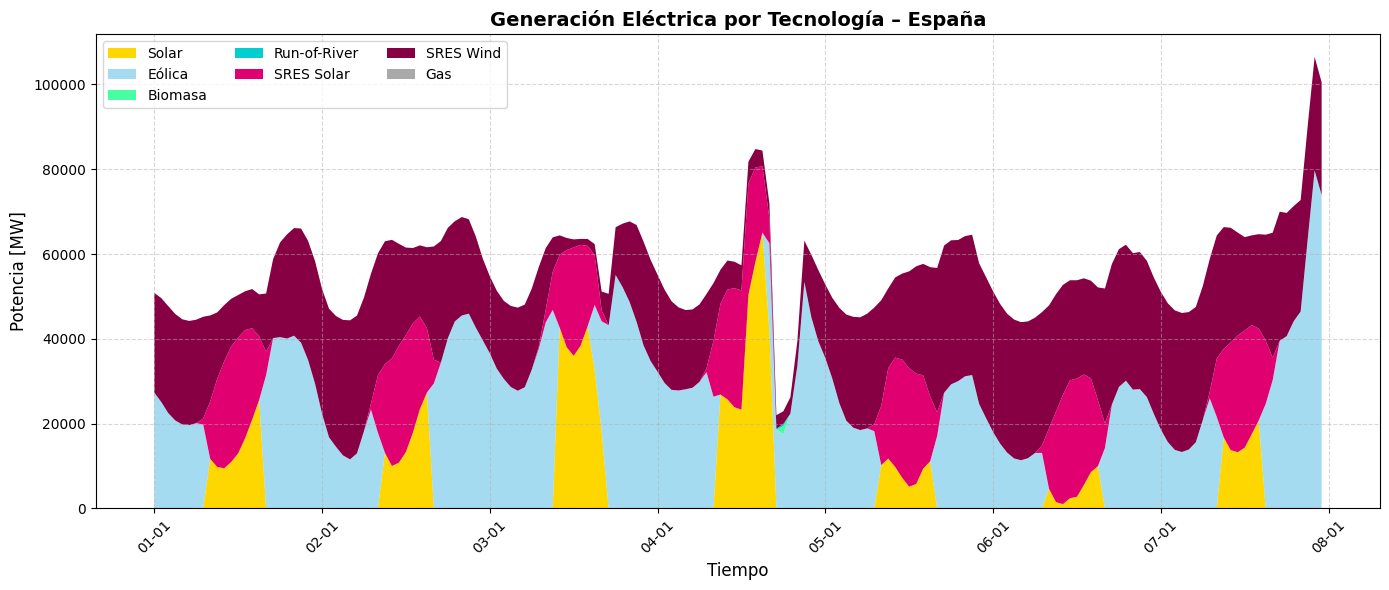

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# GENERACIÓN ELÉCTRICA EN ESPAÑA (MW) — FORMATO "FOTO 2"
#  - Stackplot por tecnología (no por generador individual)
#  - Solo activos conectados a buses ES_ (o nombre ES_)
#  - Sin load shedding
# ============================================================

def plot_generacion_es_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00"):
    n = network

    # --- snapshots / rango ---
    hours = pd.date_range(start=start, end=end, freq="h")
    # si tus snapshots ya son exactamente ese rango, esto igual te da igual
    times = hours

    # --- DF de generadores y buses (compatibilidad) ---
    try:
        gen_df = n.components["Generator"].df
        buses_df = n.components["Bus"].df
    except Exception:
        gen_df = n.generators if hasattr(n, "generators") else n.generators.df
        buses_df = n.buses if hasattr(n, "buses") else n.buses.df

    # --- Buses ES_ ---
    es_buses = set(buses_df.index.to_series().astype(str)[buses_df.index.to_series().astype(str).str.startswith("ES_")])

    # --- Generadores en buses ES_ (fallback por nombre ES_) ---
    if "bus" in gen_df.columns:
        gens_es = list(gen_df.index[gen_df["bus"].isin(es_buses)])
    else:
        gens_es = list(gen_df.index[gen_df.index.to_series().astype(str).str.startswith("ES_")])

    # --- Generación temporal ---
    if not hasattr(n, "generators_t") or not hasattr(n.generators_t, "p"):
        raise ValueError("No existe network.generators_t.p (¿has corrido el modelo?).")

    p = n.generators_t.p

    # solo columnas disponibles
    gens_es = [g for g in gens_es if g in p.columns]
    if len(gens_es) == 0:
        print("No se encontraron generadores ES_* en network.generators_t.p")
        return

    # --- Clasificación por tecnología (ajusta aquí si tus nombres difieren) ---
    def tech_from_gen_name(gname, carrier=None):
        s = str(gname).lower()
        c = str(carrier).lower() if carrier is not None else ""

        # quitar load shedding
        if "load_shedding" in s or "shedding" in s or "load shedding" in c:
            return None

        # SRES (si quieres separarlo)
        if "sres" in s:
            if "solar" in s: return "SRES Solar"
            if "wind"  in s: return "SRES Wind"
            return "SRES"

        # normal
        if "solar" in s or "solar" in c: return "Solar"
        if "wind"  in s or "eolic" in s or "wind" in c: return "Eólica"
        if "biomass" in s or "biomasa" in s or "biomass" in c: return "Biomasa"
        if "water" in s or "hydro" in s or "river" in s or "water" in c or "hydro" in c:
            return "Run-of-River"
        if "gas" in s or "ccgt" in s or "gas" in c: return "Gas"
        return "Otros"

    # --- Construir series agregadas (MW) ---
    series = {}
    for g in gens_es:
        carrier = gen_df.loc[g, "carrier"] if "carrier" in gen_df.columns and g in gen_df.index else None
        tech = tech_from_gen_name(g, carrier)
        if tech is None:
            continue
        series.setdefault(tech, 0.0)
        series[tech] = series[tech] + p[g].reindex(times).fillna(0.0)

    if len(series) == 0:
        print("Tras filtrar load shedding, no queda nada que pintar.")
        return

    # --- Orden de tecnologías (estilo foto 2: pocas y claras) ---
    preferred_order = [
        "Solar", "Eólica", "Biomasa", "Run-of-River",
        "SRES Solar", "SRES Wind", "SRES",
        "Gas", "Otros"
    ]
    techs = [t for t in preferred_order if t in series] + [t for t in series if t not in preferred_order]

    df_plot = pd.DataFrame({t: series[t] for t in techs}, index=times)

    # --- Colores (como tu foto 2 / tu paleta) ---
    colors = {
        "Solar": "#FFD700",
        "Eólica": "#87CFEBBE",
        "Biomasa": "#46FFA2",
        "Run-of-River": "#00CED1",
        "Gas": "#A9A9A9",
        "SRES Solar": "#E00070",    # tono parecido a lo que se ve en tus gráficas (ajústalo si quieres)
        "SRES Wind": "#860043",    # rosa
        "SRES": "#32CD32",           # verde
        "Otros": "#BAB0AC",
    }
    color_list = [colors.get(t, "#BAB0AC") for t in techs]

    # ============================================================
    # PLOT (stackplot tipo foto 2)
    # ============================================================
    plt.figure(figsize=(14, 6))

    plt.stackplot(
        df_plot.index,
        [df_plot[t].values for t in techs],
        labels=techs,
        colors=color_list,
        linewidth=0.0
    )

    plt.title("Generación Eléctrica por Tecnología – España", fontsize=14, fontweight="bold")
    plt.xlabel("Tiempo", fontsize=12)
    plt.ylabel("Potencia [MW]", fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Leyenda compacta como foto 2
    plt.legend(loc="upper left", fontsize=10, ncol=3)

    # Formato eje X como foto 2 (día-mes)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))

    plt.tight_layout()
    plt.show()


# Ejecuta:
plot_generacion_es_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00")

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4946591.py:21: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4946591.py:22: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4946591.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4946591.py:44: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



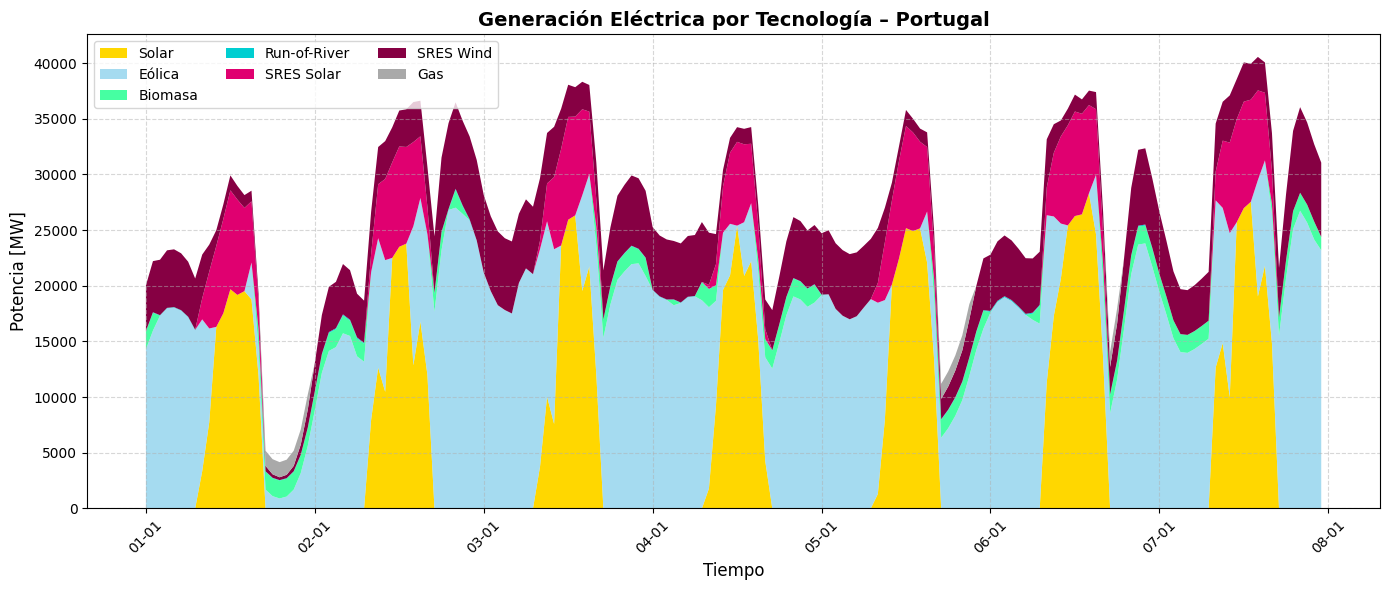

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================
# GENERACIÓN ELÉCTRICA EN PORTUGAL (MW) — FORMATO "FOTO 2"
#  - Stackplot por tecnología (no por generador individual)
#  - Solo activos conectados a buses PT_ (o nombre PT_)
#  - Sin load shedding
# ============================================================

def plot_generacion_pt_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00"):
    n = network

    # --- rango temporal ---
    times = pd.date_range(start=start, end=end, freq="h")

    # --- DF de generadores y buses (compatibilidad) ---
    try:
        gen_df = n.components["Generator"].df
        buses_df = n.components["Bus"].df
    except Exception:
        gen_df = n.generators if hasattr(n, "generators") else n.generators.df
        buses_df = n.buses if hasattr(n, "buses") else n.buses.df

    # --- Buses PT_ ---
    pt_buses = set(
        buses_df.index.to_series().astype(str)[
            buses_df.index.to_series().astype(str).str.startswith("PT_")
        ]
    )

    # --- Generadores en buses PT_ (fallback por nombre PT_) ---
    if "bus" in gen_df.columns:
        gens_pt = list(gen_df.index[gen_df["bus"].isin(pt_buses)])
    else:
        gens_pt = list(gen_df.index[gen_df.index.to_series().astype(str).str.startswith("PT_")])

    # --- Generación temporal ---
    if not hasattr(n, "generators_t") or not hasattr(n.generators_t, "p"):
        raise ValueError("No existe network.generators_t.p (¿has corrido el modelo?).")

    p = n.generators_t.p

    # solo columnas disponibles
    gens_pt = [g for g in gens_pt if g in p.columns]
    if len(gens_pt) == 0:
        print("No se encontraron generadores PT_* en network.generators_t.p")
        return

    # --- Clasificación por tecnología ---
    def tech_from_gen_name(gname, carrier=None):
        s = str(gname).lower()
        c = str(carrier).lower() if carrier is not None else ""

        # quitar load shedding
        if "load_shedding" in s or "shedding" in s or "load shedding" in c:
            return None

        # SRES
        if "sres" in s:
            if "solar" in s: return "SRES Solar"
            if "wind"  in s: return "SRES Wind"
            return "SRES"

        # normal
        if "solar" in s or "solar" in c: return "Solar"
        if "wind" in s or "eolic" in s or "wind" in c: return "Eólica"
        if "biomass" in s or "biomasa" in s or "biomass" in c: return "Biomasa"
        if "water" in s or "hydro" in s or "river" in s or "water" in c or "hydro" in c:
            return "Run-of-River"
        if "gas" in s or "ccgt" in s or "gas" in c: return "Gas"
        return "Otros"

    # --- Construir series agregadas (MW) ---
    series = {}
    for g in gens_pt:
        carrier = gen_df.loc[g, "carrier"] if ("carrier" in gen_df.columns and g in gen_df.index) else None
        tech = tech_from_gen_name(g, carrier)
        if tech is None:
            continue
        series.setdefault(tech, 0.0)
        series[tech] = series[tech] + p[g].reindex(times).fillna(0.0)

    if len(series) == 0:
        print("Tras filtrar load shedding, no queda nada que pintar.")
        return

    # --- Orden de tecnologías ---
    preferred_order = [
        "Solar", "Eólica", "Biomasa", "Run-of-River",
        "SRES Solar", "SRES Wind", "SRES",
        "Gas", "Otros"
    ]
    techs = [t for t in preferred_order if t in series] + [t for t in series if t not in preferred_order]

    df_plot = pd.DataFrame({t: series[t] for t in techs}, index=times)

    # --- Colores (misma lógica que España; ajusta si quieres) ---
    colors = {
        "Solar": "#FFD700",
        "Eólica": "#87CFEBBE",
        "Biomasa": "#46FFA2",
        "Run-of-River": "#00CED1",
        "Gas": "#A9A9A9",
        "SRES Solar": "#E00070",    # tono parecido a lo que se ve en tus gráficas (ajústalo si quieres)
        "SRES Wind": "#860043",    # rosa
        "SRES": "#32CD32",           # verde
        "Otros": "#BAB0AC",
    }
    color_list = [colors.get(t, "#BAB0AC") for t in techs]

    # --- Plot (stackplot tipo foto 2) ---
    plt.figure(figsize=(14, 6))
    plt.stackplot(
        df_plot.index,
        [df_plot[t].values for t in techs],
        labels=techs,
        colors=color_list,
        linewidth=0.0
    )

    plt.title("Generación Eléctrica por Tecnología – Portugal", fontsize=14, fontweight="bold")
    plt.xlabel("Tiempo", fontsize=12) 
    plt.ylabel("Potencia [MW]", fontsize=12)

    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left", fontsize=10, ncol=3)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m"))
    plt.tight_layout()
    plt.show()


# Ejecuta:
plot_generacion_pt_formato_foto2(network, start="2025-01-01", end="2025-01-07 23:00")

In [ ]:
print("PT demanda max (MW):", network.loads_t.p_set["PT_demand_2040"].max())
print("ES demanda max (MW):", network.loads_t.p_set["ES_demand_2040"].max())

# y el shedding:
names = network.generators.static.index[network.generators.static.carrier=="load_shedding"]
print(network.generators_t.p[names].max())

PT demanda max (MW): 34597.00195694716
ES demanda max (MW): 57703.08642907063
name
ES_load_shedding          -0.000000
PT_load_shedding       12616.352188
ES_load_shedding_h2       -0.000000
PT_load_shedding_h2       -0.000000
dtype: float64


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3006000797.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3006000797.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3006000797.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3842336258.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3842336258.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3842336258.py:38: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3842336258.py:39: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information.

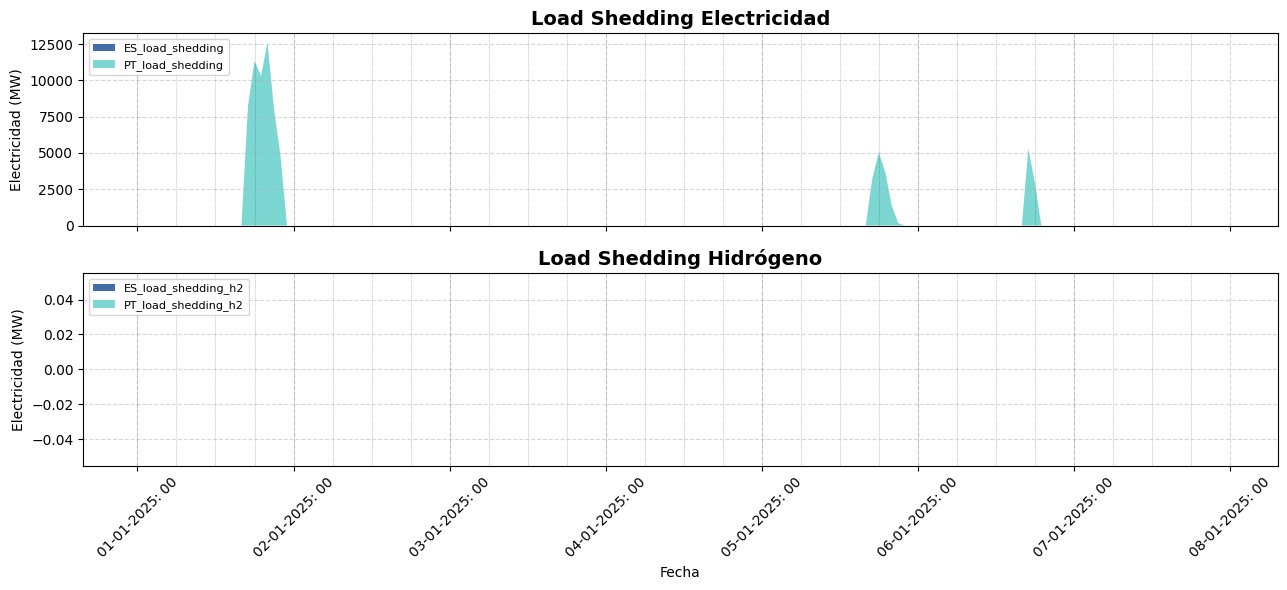

In [ ]:
# ---------------------------------------------------------------------
plt.style.use('default')
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# ===================== (1) ELECTRICIDAD =====================
generadores_elec = [
    "ES_load_shedding",
    "PT_load_shedding",
]

series = []
labels = []

for gen in generadores_elec:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

colors = ["#2F5D9F", "#6ED3CF"]

axes[0].stackplot(hours, series, labels=labels, colors=colors[:len(series)], alpha=0.9)
axes[0].set_title("Load Shedding Electricidad", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Electricidad (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left", fontsize=8)


# ===================== (2) HIDRÓGENO =====================
generadores_h2 = [
    "ES_load_shedding_h2",
    "PT_load_shedding_h2",
]

series = []
labels = []

for gen in generadores_h2:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

axes[1].stackplot(hours, series, labels=labels, colors=colors[:len(series)], alpha=0.9)
axes[1].set_title("Load Shedding Hidrógeno", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Electricidad (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left", fontsize=8)


# ===================== FORMATO COMÚN =====================
for ax in axes:
    # Líneas verticales cada 6 horas
    for day in pd.date_range("2025-01-01", "2025-01-07"):
        for hour in [0, 6, 12, 18]:
            timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
            ax.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

    # Formato del eje X
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# ---------------------------------------------------------------------

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3175466517.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



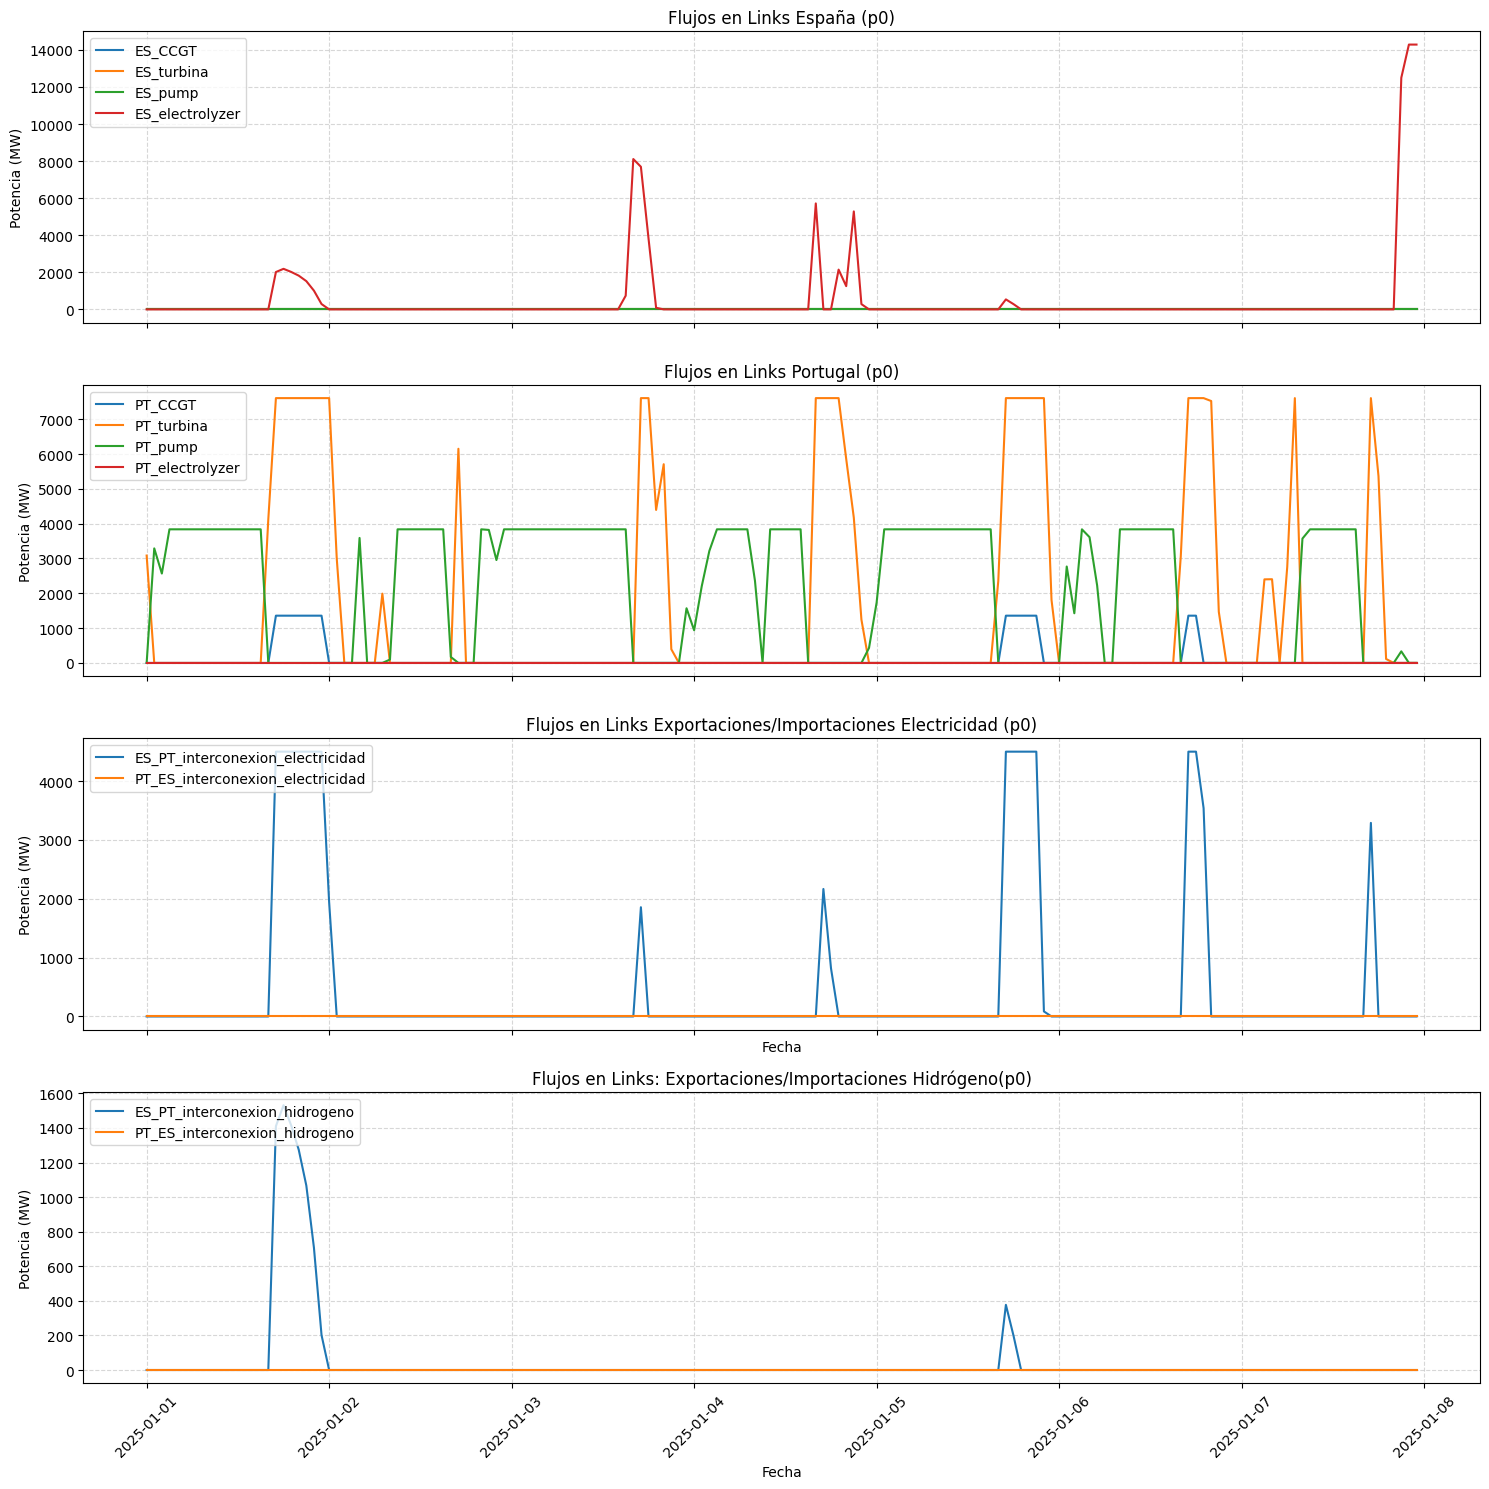

In [ ]:
p0 = network.links_t.p0
links_ES = [
    "ES_CCGT",
    "ES_turbina",
    "ES_pump",
    "ES_electrolyzer",
]

links_PT = [
    "PT_CCGT",
    "PT_turbina",
    "PT_pump",
    "PT_electrolyzer",
]

links_exportaciones_electricidad = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
]

links_exportaciones_hidrogeno = [
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]

# --- Crear figura con 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(15, 15), sharex=True)  # 3 filas, 1 columna
 
# --- GRAFICO ESPAÑA ---
for link in links_ES:
    if link in p0.columns:
        axes[0].plot(network.snapshots, p0[link], label=link)
axes[0].set_title("Flujos en Links España (p0)")
axes[0].set_ylabel("Potencia (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")
 
# --- GRAFICO PORTUGAL ---
for link in links_PT:
    if link in p0.columns:
        axes[1].plot(network.snapshots, p0[link], label=link)
axes[1].set_title("Flujos en Links Portugal (p0)")
axes[1].set_ylabel("Potencia (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left")
 
# --- GRAFICO EXPORTACIONES electricidad ---
for link in links_exportaciones_electricidad:
    if link in p0.columns:
        axes[2].plot(network.snapshots, p0[link], label=link)
axes[2].set_title("Flujos en Links Exportaciones/Importaciones Electricidad (p0)")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Potencia (MW)")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="upper left")

 

# --- GRAFICO EXPORTACIONES hidrogeno---
for link in links_exportaciones_hidrogeno:
    if link in p0.columns:
        axes[3].plot(network.snapshots, p0[link], label=link)
axes[3].set_title("Flujos en Links: Exportaciones/Importaciones Hidrógeno(p0)")
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("Potencia (MW)")
axes[3].grid(True, linestyle="--", alpha=0.5)
axes[3].legend(loc="upper left")

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3066871197.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



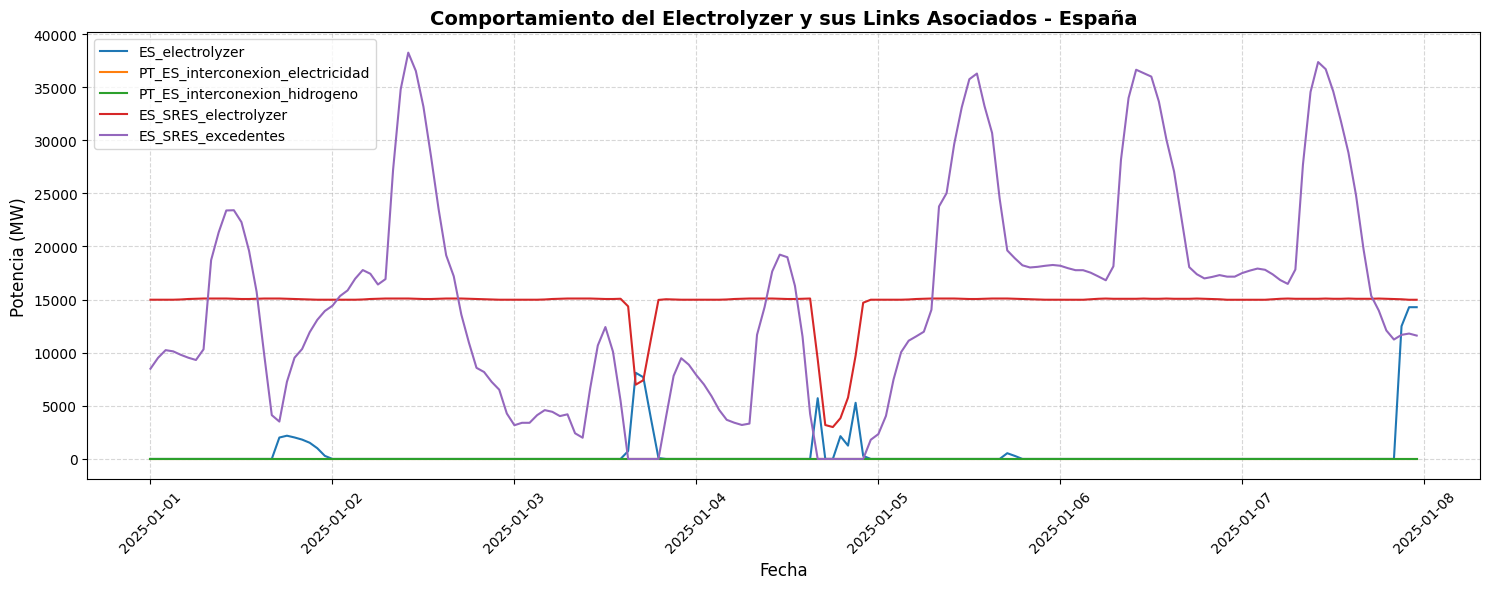

In [ ]:
p0 = network.links_t.p0
comportamiento_electrolyzer = [
    "ES_electrolyzer",
    "PT_ES_interconexion_electricidad",
    "PT_ES_interconexion_hidrogeno",
    "ES_SRES_electrolyzer",
    "ES_SRES_excedentes"

]

# haz una grafica donde estén los links relacionados con el comportamiento del electrolyzer en España y Portugal
plt.figure(figsize=(15,6))
for link in comportamiento_electrolyzer:
    if link in p0.columns:
        plt.plot(network.snapshots, p0[link], label=link)
plt.title("Comportamiento del Electrolyzer y sus Links Asociados - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2819107919.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



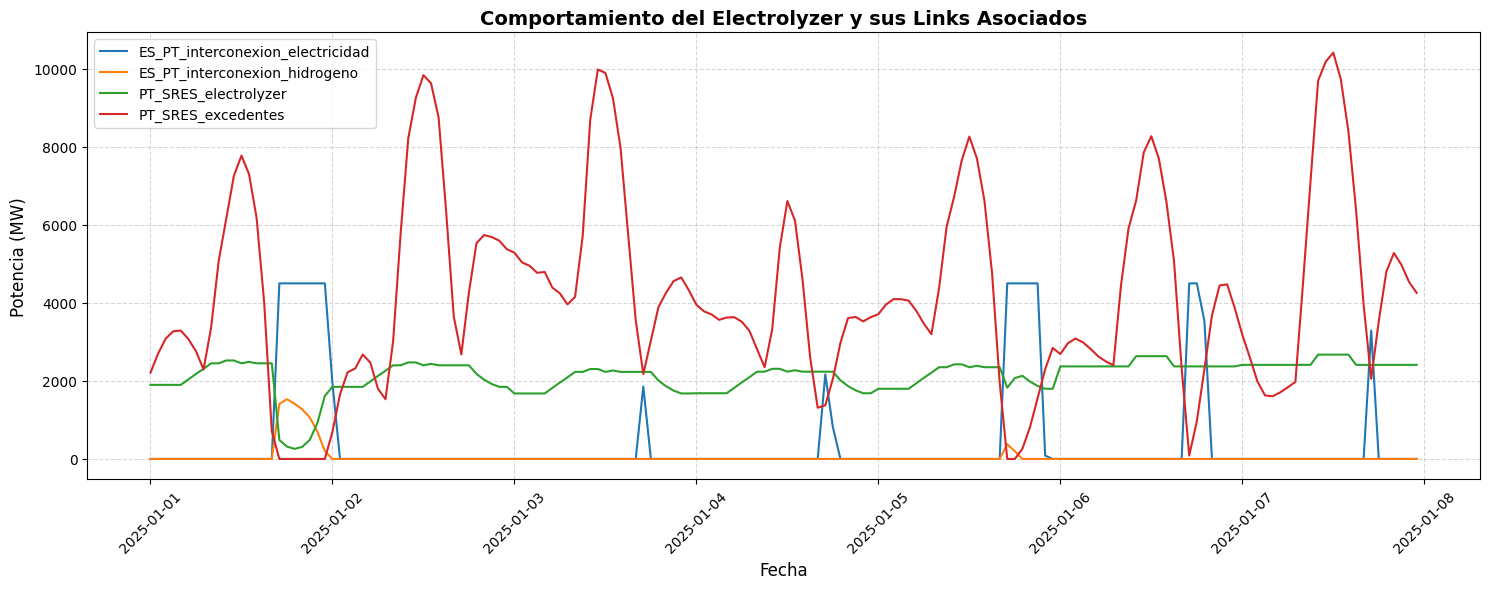

In [ ]:
p0 = network.links_t.p0
comportamiento_electrolyzer = [

    "ES_PT_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_SRES_electrolyzer",
    "PT_SRES_excedentes"

]

# haz una grafica donde estén los links relacionados con el comportamiento del electrolyzer en España y Portugal
plt.figure(figsize=(15,6))
for link in comportamiento_electrolyzer:
    if link in p0.columns:
        plt.plot(network.snapshots, p0[link], label=link)
plt.title("Comportamiento del Electrolyzer y sus Links Asociados", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3711410758.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3711410758.py:19: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3711410758.py:26: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



[PT] Horas donde el SRES electrolizador NO cumple prioridad: 0 / 168


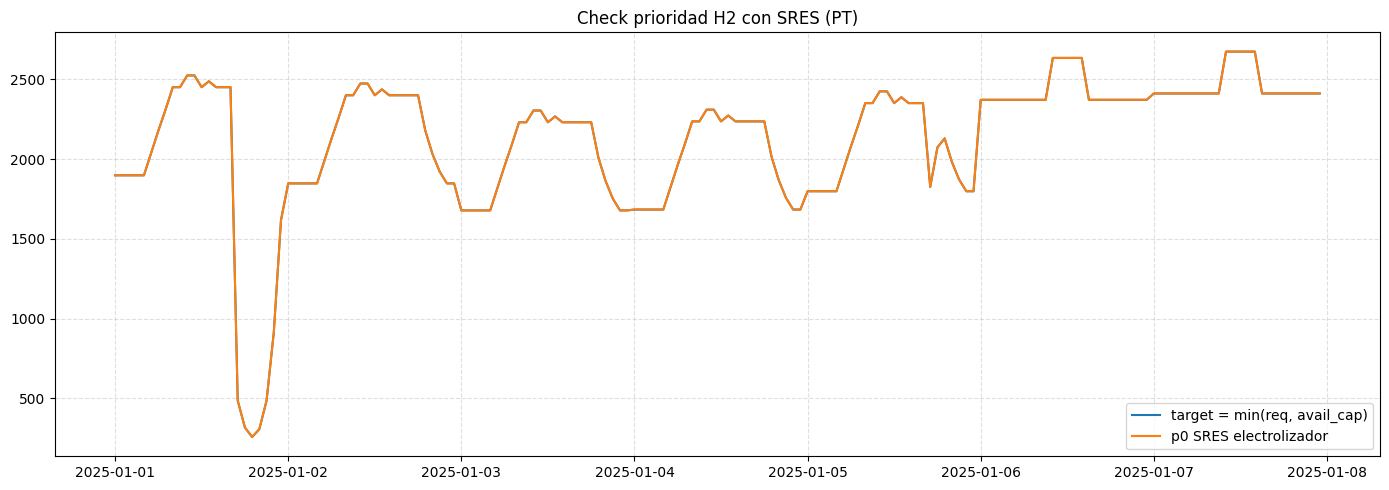

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3711410758.py:12: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3711410758.py:19: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3711410758.py:26: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



[ES] Horas donde el SRES electrolizador NO cumple prioridad: 0 / 168


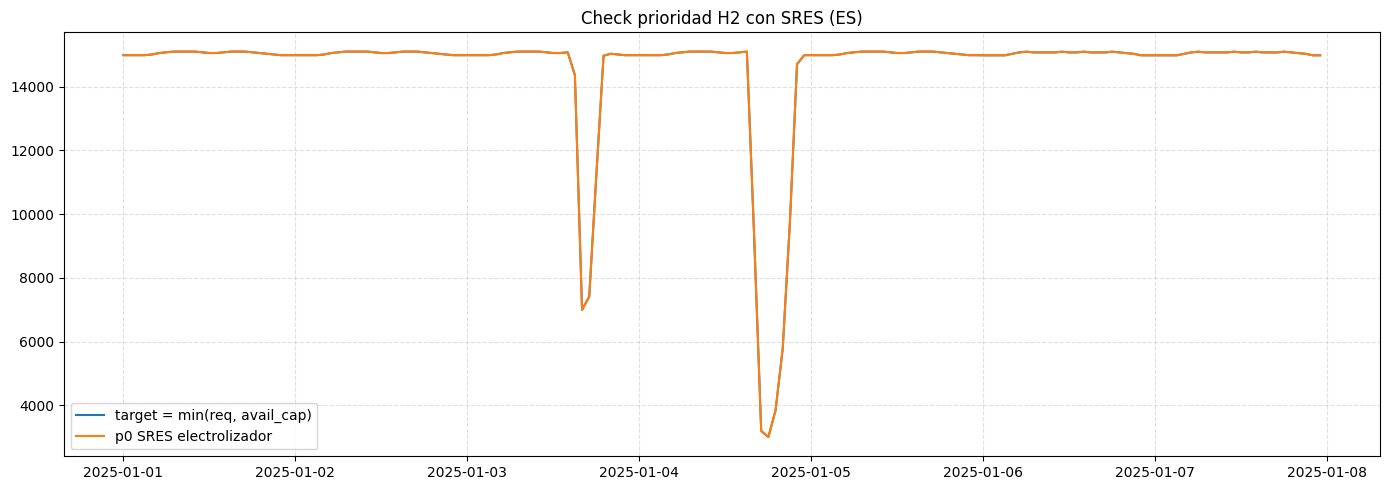

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def check_sres_h2_priority(network, country="PT", tol=1e-3):
    l_ely = f"{country}_SRES_electrolyzer"
    eff   = float(network.links.static.loc[l_ely, "efficiency"])
    cap   = float(network.links.static.loc[l_ely, "p_nom"])

    # demanda H2
    load = f"{country}_hydrogen_demand"
    h2 = network.loads_t.p_set[load].values  # MW_H2
    req = h2 / eff                            # MW_e

    # SRES disponible
    sres_bus = f"{country}_SRES_bus"
    gens_sres = network.generators.static.index[network.generators.static["bus"] == sres_bus]
    p_nom = network.generators.static.loc[gens_sres, "p_nom"].astype(float)
    pmax  = network.generators_t.p_max_pu[gens_sres]
    avail = (pmax.mul(p_nom, axis=1)).sum(axis=1).values

    avail_cap = np.minimum(avail, cap)
    target = np.minimum(req, avail_cap)

    # electrolizador real (ojo: aquí uso p0 como tú vienes haciendo)
    p_ely = network.links_t.p0[l_ely].clip(lower=0).values  # MW_e

    bad = p_ely + tol < target
    print(f"[{country}] Horas donde el SRES electrolizador NO cumple prioridad: {bad.sum()} / {len(bad)}")

    plt.figure(figsize=(14,5))
    plt.plot(network.snapshots, target, label="target = min(req, avail_cap)")
    plt.plot(network.snapshots, p_ely, label="p0 SRES electrolizador")
    plt.title(f"Check prioridad H2 con SRES ({country})")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

check_sres_h2_priority(network, "PT")
check_sres_h2_priority(network, "ES")

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4070002592.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4070002592.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4070002592.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4070002592.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.

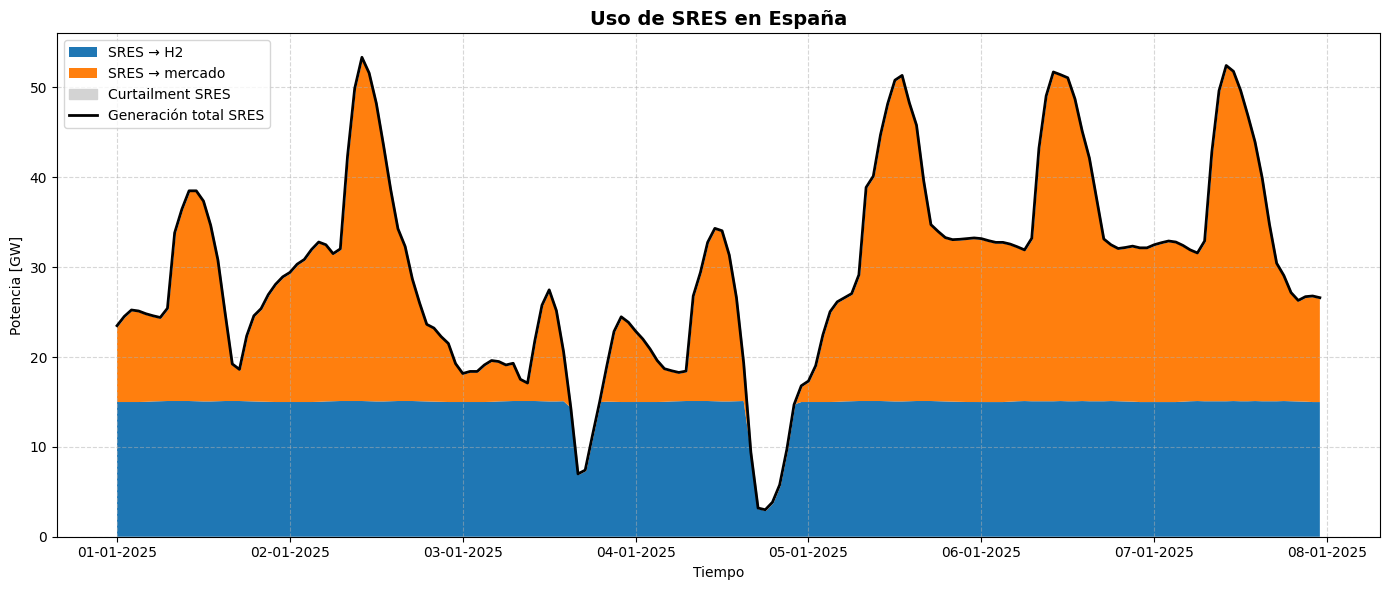

In [ ]:
# Generación SRES total (GW)
pt_sres_total = (
    network.generators_t.p["ES_SRES_wind"]
    + network.generators_t.p["ES_SRES_solar"]
) / 1e3

# Uso de SRES
pt_h2_sres = network.links_t.p0["ES_SRES_electrolyzer"].abs() / 1e3
pt_excess  = network.links_t.p0["ES_SRES_excedentes"].abs() / 1e3

# 🔥 CURTAILMENT (BLANCO)
pt_curtailment = (
    pt_sres_total
    - pt_h2_sres
    - pt_excess
).clip(lower=0)


pt_week = slice(
    pt_sres_total.index[0],
    pt_sres_total.index[0] + pd.Timedelta(hours=167)
)

pt_sres_w   = pt_sres_total.loc[pt_week]
pt_h2_w     = pt_h2_sres.loc[pt_week]
pt_excess_w= pt_excess.loc[pt_week]
pt_curt_w  = pt_curtailment.loc[pt_week]


plt.figure(figsize=(14, 6))

# Áreas usadas
plt.stackplot(
    pt_sres_w.index,
    pt_h2_w,
    pt_excess_w,
    labels=["SRES → H2", "SRES → mercado"],
    linewidth=0.0,
)

# Área blanca = curtailment
plt.fill_between(
    pt_sres_w.index,
    pt_h2_w + pt_excess_w,
    pt_sres_w,
    color="lightgrey",
    label="Curtailment SRES"
)

# Línea total SRES
plt.plot(
    pt_sres_w.index,
    pt_sres_w,
    color="black",
    linewidth=2,
    label="Generación total SRES"
)

plt.title("Uso de SRES en España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo")
plt.ylabel("Potencia [GW]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\183571576.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\183571576.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\183571576.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\183571576.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dyna

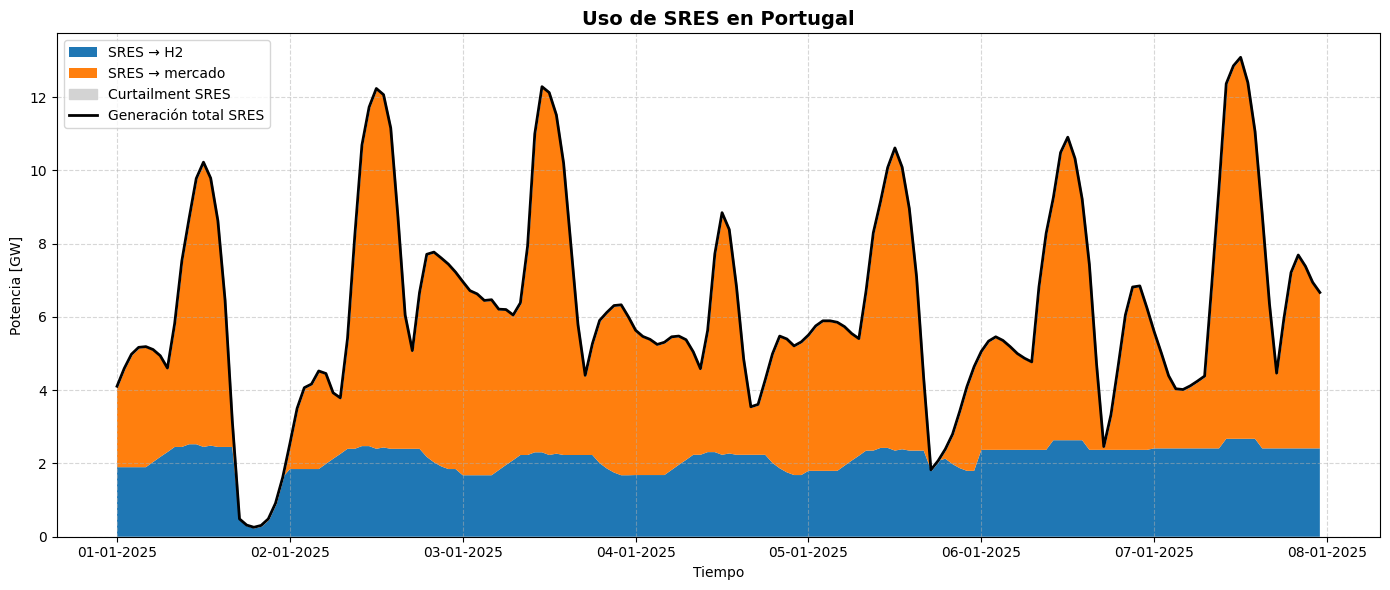

In [ ]:
# Generación SRES total (GW)
pt_sres_total = (
    network.generators_t.p["PT_SRES_wind"]
    + network.generators_t.p["PT_SRES_solar"]
) / 1e3

# Uso de SRES
pt_h2_sres = network.links_t.p0["PT_SRES_electrolyzer"].abs() / 1e3
pt_excess  = network.links_t.p0["PT_SRES_excedentes"].abs() / 1e3

# CURTAILMENT (BLANCO)
pt_curtailment = (
    pt_sres_total
    - pt_h2_sres
    - pt_excess
).clip(lower=0)


pt_week = slice(
    pt_sres_total.index[0],
    pt_sres_total.index[0] + pd.Timedelta(hours=167)
)

pt_sres_w   = pt_sres_total.loc[pt_week]
pt_h2_w     = pt_h2_sres.loc[pt_week]
pt_excess_w= pt_excess.loc[pt_week]
pt_curt_w  = pt_curtailment.loc[pt_week]


plt.figure(figsize=(14, 6))

# Áreas usadas
plt.stackplot(
    pt_sres_w.index,
    pt_h2_w,
    pt_excess_w,
    labels=["SRES → H2", "SRES → mercado"],
    linewidth=0.0,
)

# Área blanca = curtailment
plt.fill_between(
    pt_sres_w.index,
    pt_h2_w + pt_excess_w,
    pt_sres_w,
    color="lightgrey",
    label="Curtailment SRES"
)

# Línea total SRES
plt.plot(
    pt_sres_w.index,
    pt_sres_w,
    color="black",
    linewidth=2,
    label="Generación total SRES"
)

plt.title("Uso de SRES en Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo")
plt.ylabel("Potencia [GW]")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

In [ ]:
sres = network.generators.df.index[
    network.generators.df.carrier == "solar"
]

available = (
    network.generators.df.loc[sres, "p_nom"]
    * network.generators_t.p_max_pu[sres]
)

used = network.generators_t.p[sres]

curtailment_sres = (available - used).clip(lower=0)

curtailment_sres_MWh = (
    curtailment_sres
    .mul(network.snapshot_weightings.generators, axis=0)
    .sum()
    .sum()
)
network.statistics.curtailment()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3079050324.py:1: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3079050324.py:2: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3079050324.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3079050324.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3079050324.py:10: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dyna

component    carrier      
Generator    biomass          2.938945e+07
             gas              1.752000e+18
             load_shedding    3.503960e+11
             solar            4.553224e+08
             water            4.750294e+06
             wind             9.690745e+08
StorageUnit  AC               2.626354e+08
             hydrogen         8.760000e+07
dtype: float64

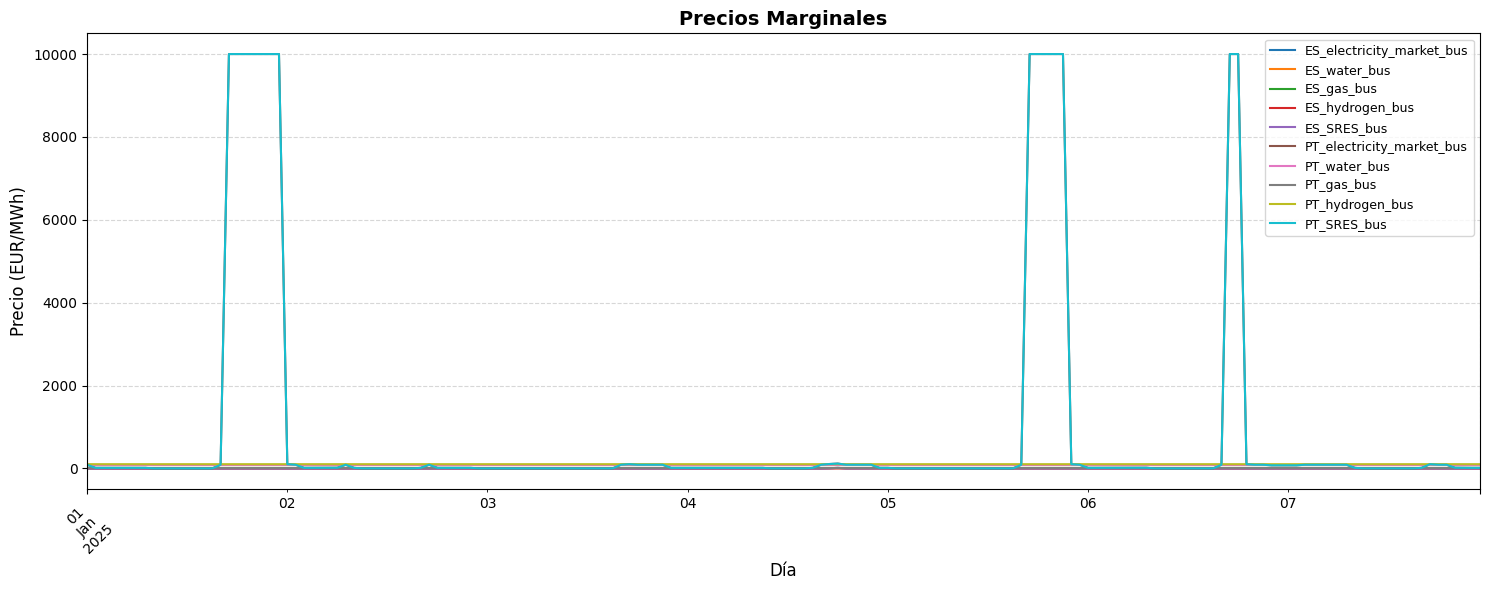

In [ ]:
# PRECIOS MARGINALES con API moderna. 
# MIRAR SI PONER LINKS EN VEZ DE BUSES
network.buses.dynamic["marginal_price"].plot(figsize=(15,6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

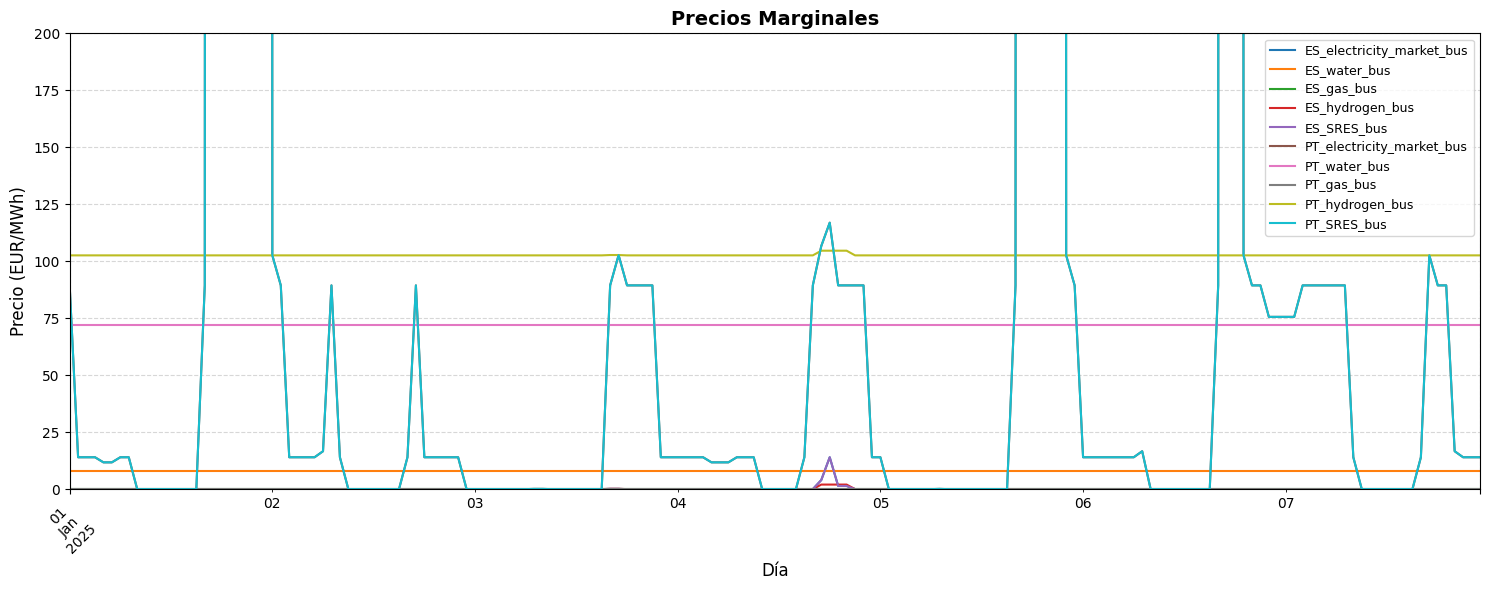

In [ ]:
# PRECIOS MARGINALES con API moderna
network.buses.dynamic["marginal_price"].plot(figsize=(15,6), title="Precios Marginales")

# Personalización
plt.title("Precios Marginales", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=9)

plt.ylim(0, 200)  # Ajusta el límite del eje Y según sea necesario
plt.tight_layout()
plt.show()

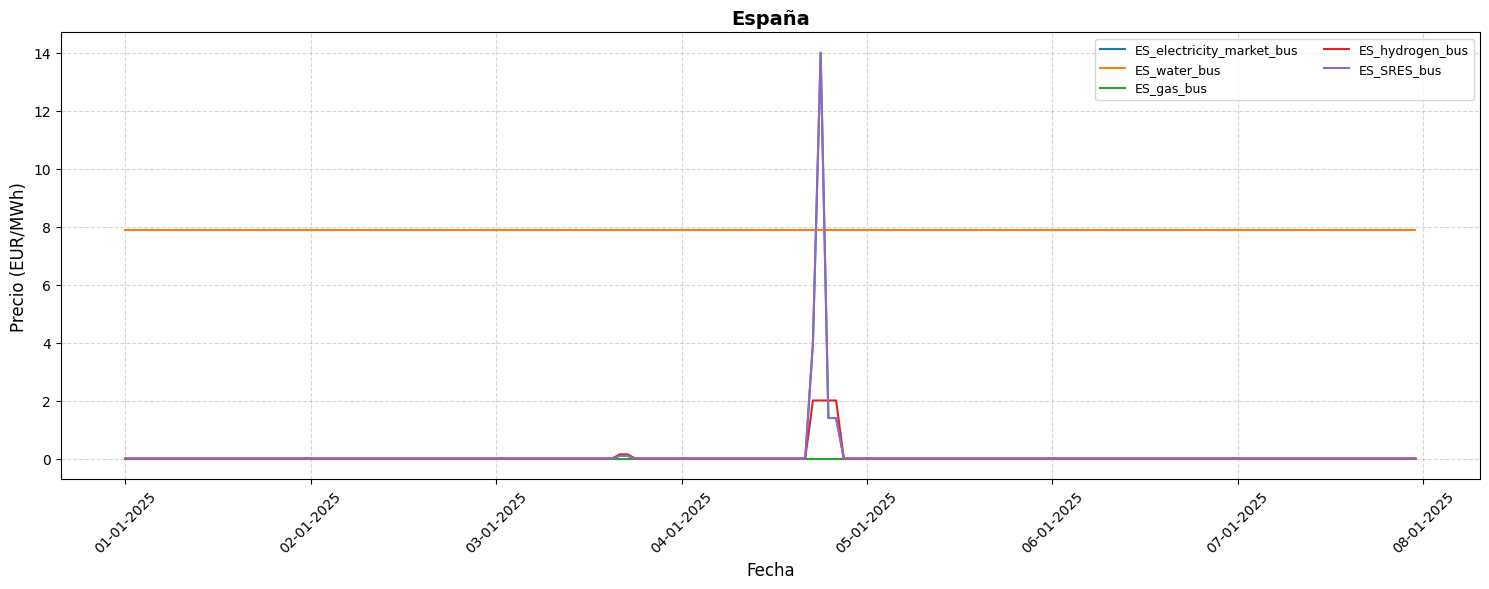

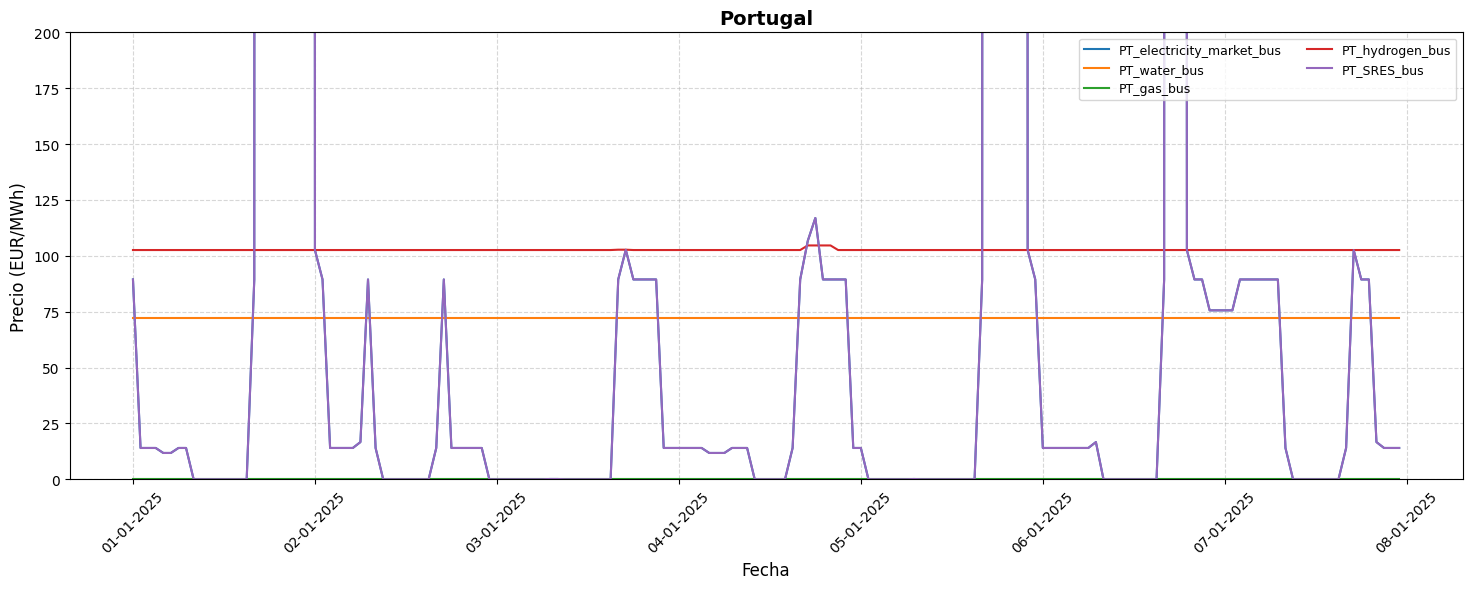

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- helper: obtener lista de buses ----------
def get_bus_index(n):
    # API nueva
    if hasattr(n.buses, "static"):
        return n.buses.static.index
    # API vieja
    return n.buses.index

# ---------- helper: obtener marginal_price ----------
def get_marginal_prices(n):
    # API nueva
    if hasattr(n.buses, "dynamic") and "marginal_price" in n.buses.dynamic:
        return n.buses.dynamic["marginal_price"]
    # API vieja
    if hasattr(n, "buses_t") and hasattr(n.buses_t, "marginal_price"):
        return n.buses_t.marginal_price
    raise AttributeError("No encuentro marginal_price en la red (¿has optimizado ya?).")

bus_index = get_bus_index(network)
marginal_prices = get_marginal_prices(network)

# ---------- España ----------
es_buses = [b for b in bus_index if str(b).startswith("ES_")]
es_prices = marginal_prices[es_buses]  # DataFrame

plt.figure(figsize=(15,6))
for b in es_buses:
    if b in es_prices.columns:
        plt.plot(network.snapshots, es_prices[b], label=b)

plt.title("España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

# ---------- Portugal ----------
pt_buses = [b for b in bus_index if str(b).startswith("PT_")]
pt_prices = marginal_prices[pt_buses]

plt.figure(figsize=(15,6))
for b in pt_buses:
    if b in pt_prices.columns:
        plt.plot(network.snapshots, pt_prices[b], label=b)

plt.title("Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=9, ncol=2)
plt.tight_layout()
plt.ylim(0, 200)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

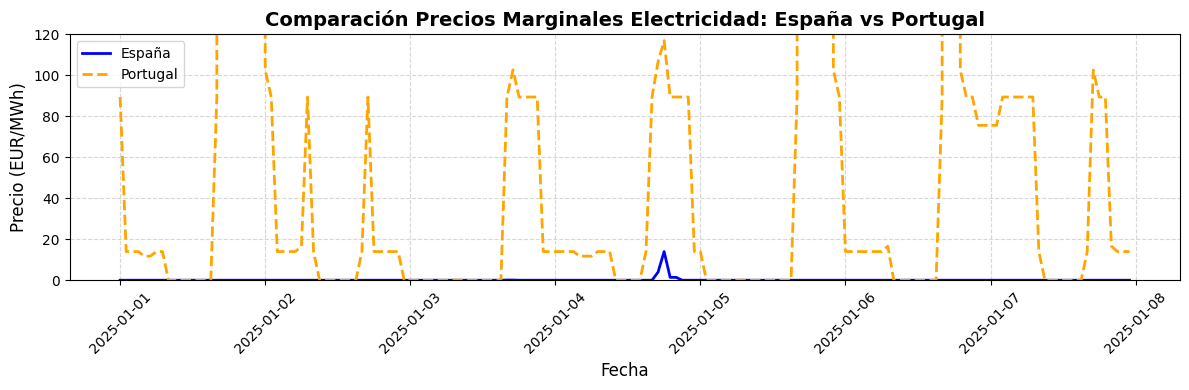

In [ ]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "PT_electricity_market_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_electricity_market_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Electricidad: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.ylim(0, 120)
plt.tight_layout()
plt.show()

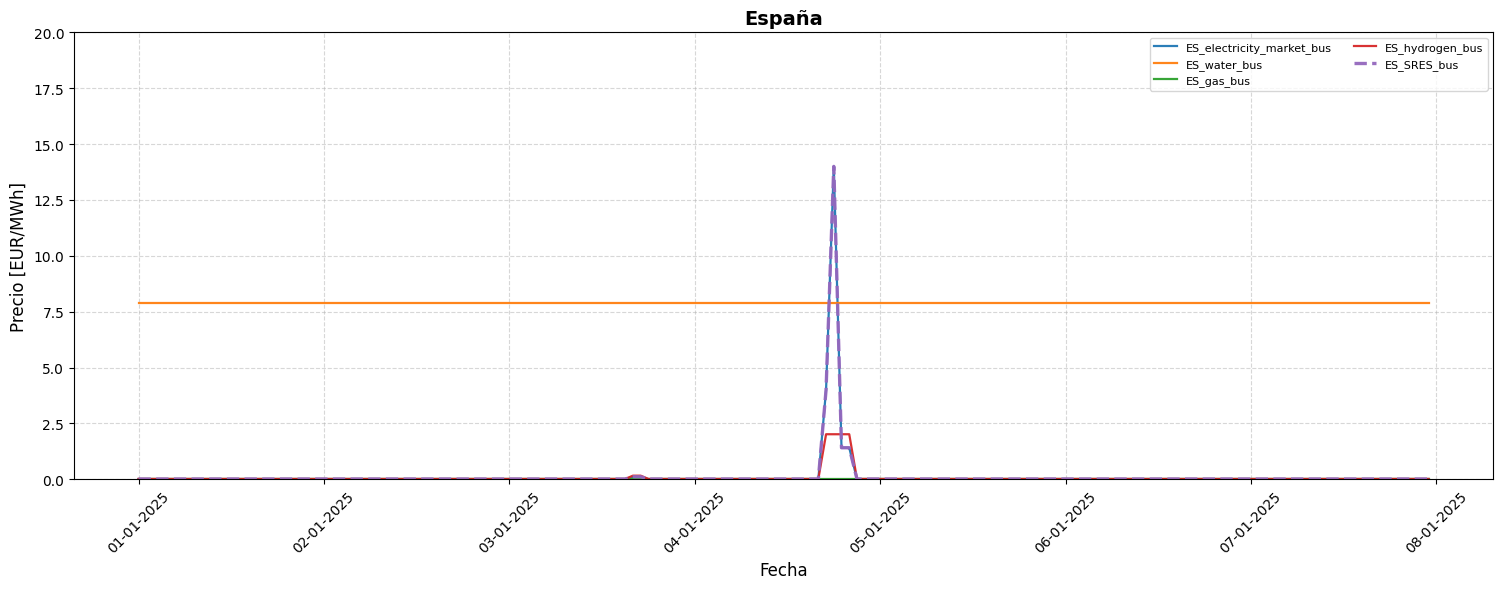

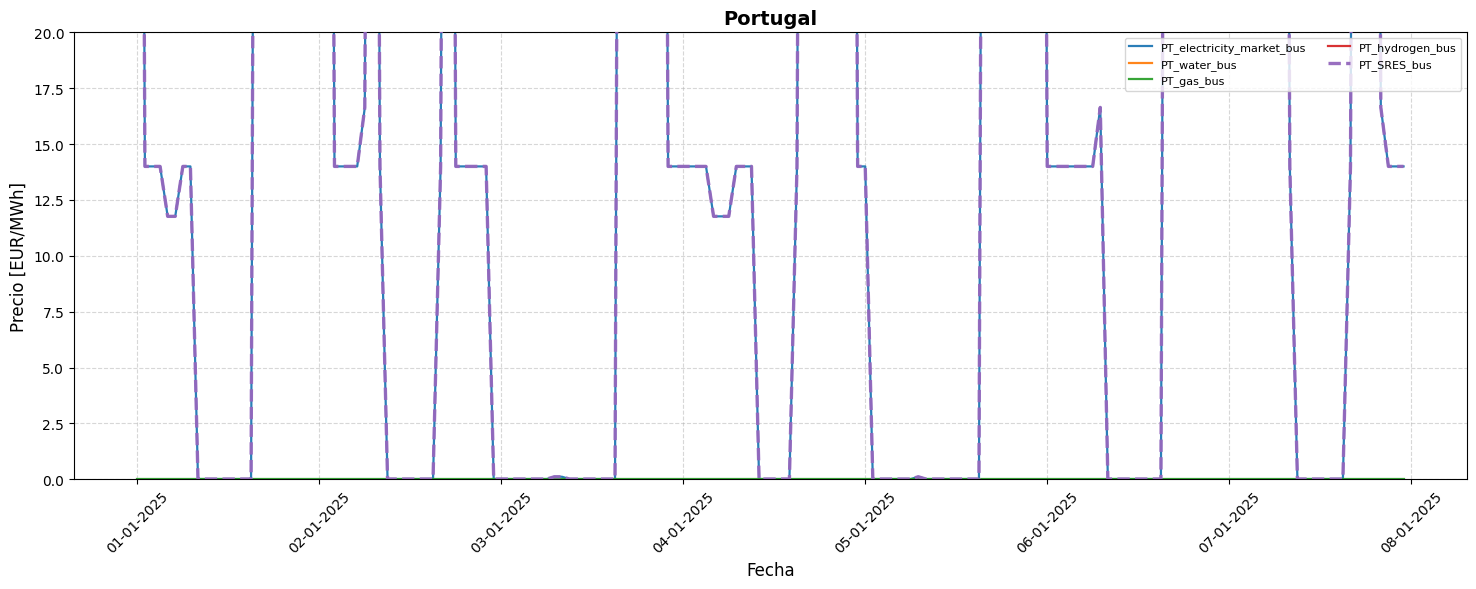

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---------- helpers robustos PyPSA ----------
def get_bus_index(n):
    if hasattr(n.buses, "static"):   # API nueva
        return n.buses.static.index
    return n.buses.index             # API vieja

def get_marginal_prices(n):
    if hasattr(n.buses, "dynamic") and "marginal_price" in n.buses.dynamic:  # API nueva
        return n.buses.dynamic["marginal_price"]
    if hasattr(n, "buses_t") and hasattr(n.buses_t, "marginal_price"):       # API vieja
        return n.buses_t.marginal_price
    raise AttributeError("No encuentro marginal_price (¿has optimizado ya?).")

# ---------- agrupar series idénticas (o casi) ----------
def group_identical_columns(df, tol=1e-6, decimals=6):
    """
    Agrupa columnas con series idénticas (tras redondeo).
    tol no se usa aquí porque agrupamos por redondeo; ajusta decimals si quieres más/menos sensibilidad.
    """
    groups = {}
    for col in df.columns:
        key = tuple(np.round(df[col].to_numpy(dtype=float), decimals))
        groups.setdefault(key, []).append(col)
    return list(groups.values())

def plot_country_prices(network, prefix="ES_", title=None, decimals=6):
    bus_index = get_bus_index(network)
    mp = get_marginal_prices(network)

    buses = [b for b in bus_index if str(b).startswith(prefix)]
    if not buses:
        raise ValueError(f"No hay buses que empiecen por {prefix}")

    df = mp[buses].reindex(network.snapshots).fillna(0.0)

    # grupos de líneas coincidentes
    groups = group_identical_columns(df, decimals=decimals)

    # estilos dentro de cada grupo
    style_cycle = ["-", "--", ":", "-."]

    plt.figure(figsize=(15, 6))

    # 1) pinta primero los "representantes" (continuas) para que queden debajo
    for g in groups:
        b0 = g[0]
        plt.plot(network.snapshots, df[b0], linestyle="-", linewidth=1.6, alpha=0.95, label=b0, zorder=2)

    # 2) pinta después los duplicados con discontinua/punteada para que se vean encima
    for g in groups:
        for i, b in enumerate(g[1:], start=1):
            ls = style_cycle[min(i, len(style_cycle)-1)]
            plt.plot(network.snapshots, df[b], linestyle=ls, linewidth=2.4, alpha=0.95, label=b, zorder=4)

    plt.title(title or f"Precios marginales ({prefix.rstrip('_')})", fontsize=14, fontweight="bold")
    plt.xlabel("Fecha", fontsize=12)
    plt.ylabel("Precio [EUR/MWh]", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.ylim(0, 20)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
    plt.show()

# --- usarlo ---
plot_country_prices(network, "ES_", title="España", decimals=6)
plot_country_prices(network, "PT_", title="Portugal", decimals=6)

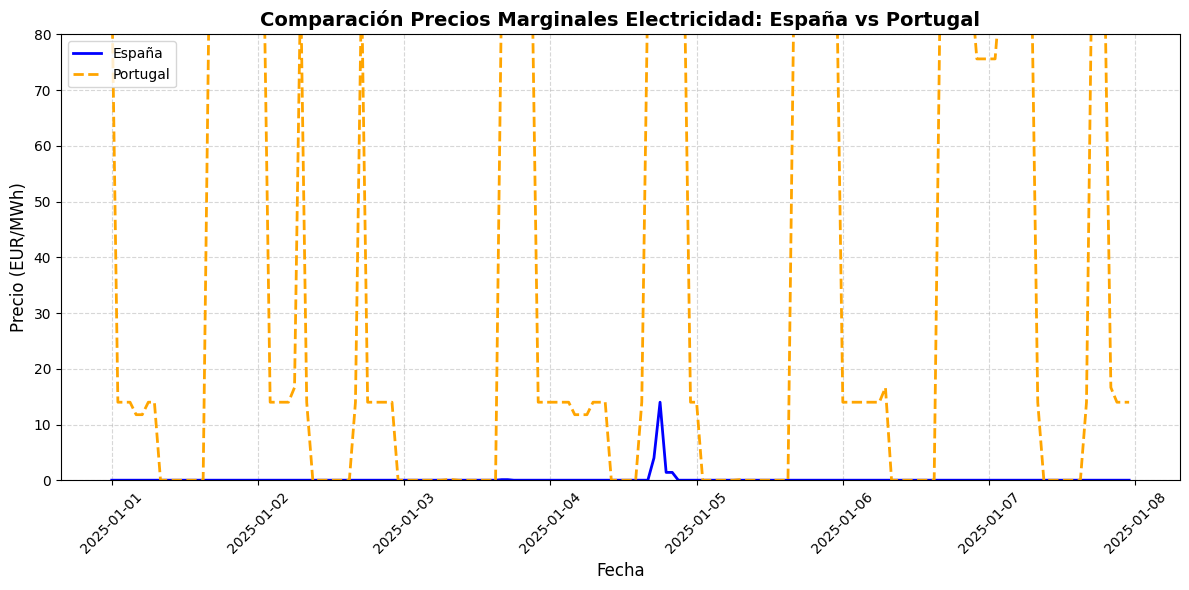

In [ ]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "PT_electricity_market_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,6))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_electricity_market_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Electricidad: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0, 80) 
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

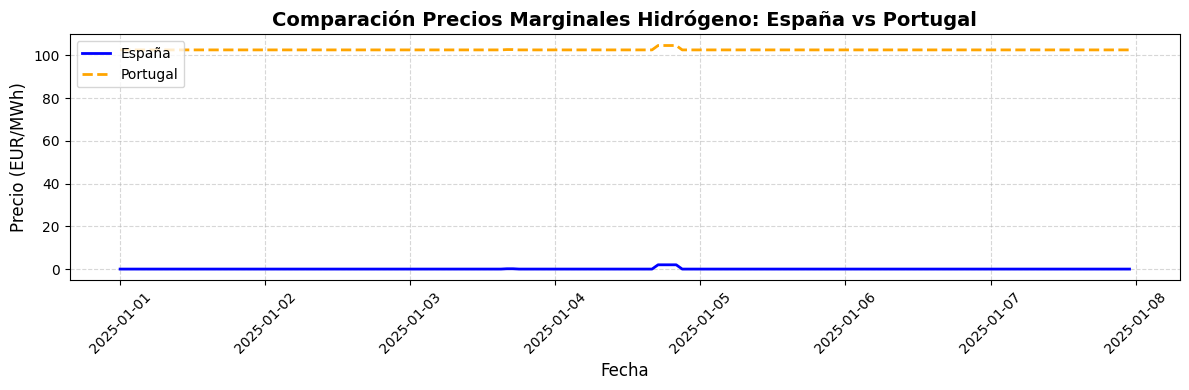

In [ ]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_hydrogen_bus", "PT_hydrogen_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_hydrogen_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_hydrogen_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Hidrógeno: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


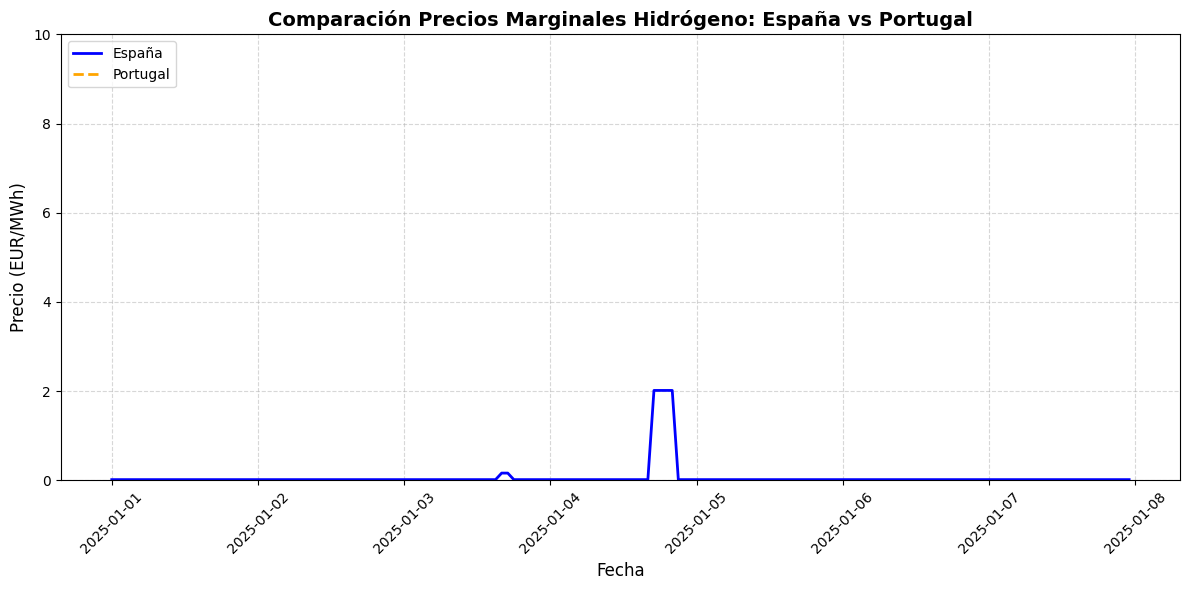

In [ ]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_hydrogen_bus", "PT_hydrogen_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,6))

if "ES_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_hydrogen_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_hydrogen_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Hidrógeno: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\1122075521.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\1122075521.py:29: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\1122075521.py:38: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\1122075521.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic

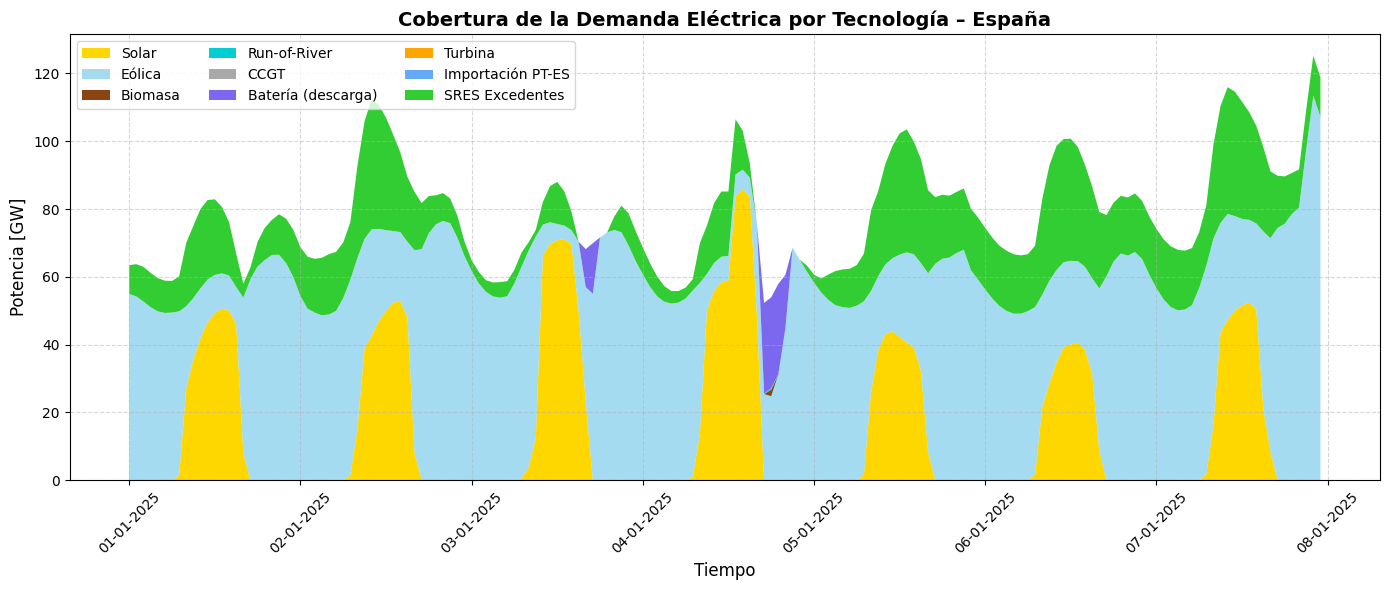

In [ ]:
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "ES_Solar":   "es_solar",  
    "ES_Eólica":  "es_wind",
    "ES_Biomasa": "es_biomass",
    "ES_Water":   "es_water",
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "es_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "es_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion PT-ES Eléctricidad
import_es_pt = network.links_t.p1["PT_ES_interconexion_electricidad"].clip(upper=0)

# Link 4: sres_excedentes (excedentes renovables)
sres_excedentes_name = [
    n for n in network.links.static.index
    if "es_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'es_sres_excedentes'")
sres_excedentes = -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "es_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "es_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "ES_Solar":         renew_series["ES_Solar"]     / 1e3,
    "ES_Eólica":        renew_series["ES_Eólica"]      / 1e3,
    "ES_Biomasa":       renew_series["ES_Biomasa"]   / 1e3,
    "ES_Run-of-River":  renew_series["ES_Water"]     / 1e3,
    "ES_CCGT":          CCGT                      / 1e3,
    "ES_electricity_market_battery":      battery_discharge         / 1e3,
    "ES_turbina":       turb                      / 1e3,
    "PT_ES_interconexion_electricidad": import_es_pt / 1e3,
    "ES_sres_excedentes": sres_excedentes / 1e3,
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "ES_Solar":                           "#FFD700",
    "ES_Eólica":                          "#87CFEBBE",
    "ES_Biomasa":                         "#8B4513",
    "ES_Run-of-River":                    "#00CED1",
    "ES_CCGT":                            "#A9A9A9",
    "ES_electricity_market_battery":      "#7B68EE",
    "ES_turbina":                         "#FFA500",
    "ES_sres_excedentes":               "#32CD32",
    "PT_ES_interconexion_electricidad":   "#2386F7B2",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["ES_Solar"], df_plot["ES_Eólica"], df_plot["ES_Biomasa"], df_plot["ES_Run-of-River"], df_plot["ES_CCGT"], df_plot["ES_electricity_market_battery"], df_plot["ES_turbina"], df_plot["PT_ES_interconexion_electricidad"],df_plot["ES_sres_excedentes"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES", "SRES Excedentes"],
    colors=[colors["ES_Solar"],colors["ES_Eólica"],colors["ES_Biomasa"],colors["ES_Run-of-River"],colors["ES_CCGT"],colors["ES_electricity_market_battery"],colors["ES_turbina"],colors["PT_ES_interconexion_electricidad"], colors["ES_sres_excedentes"]],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\301567258.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\301567258.py:31: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\301567258.py:40: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\301567258.py:43: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as

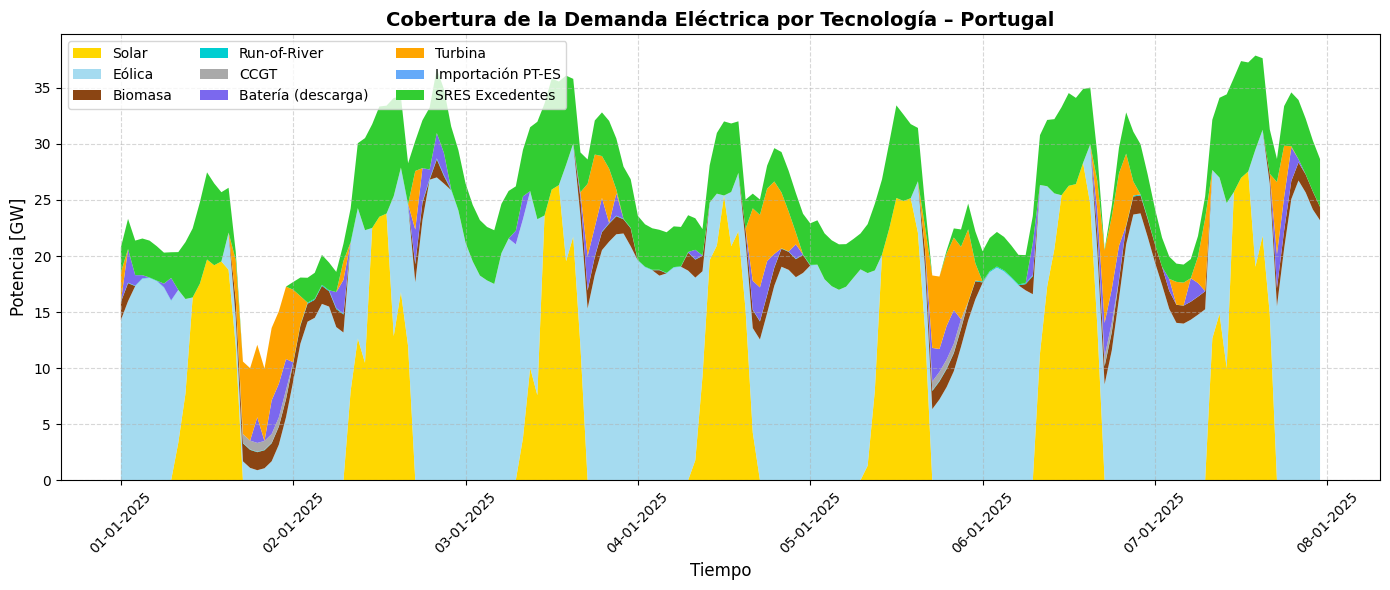

In [ ]:
# PORTUGAL. OJO PONER LOAD SHEDDING
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "PT_Solar":   "pt_solar",  
    "PT_Eólica":  "pt_wind",
    "PT_Biomasa": "pt_biomass",
    "PT_Water":   "pt_water",
   # "PT_Load_shedding": "pt_load_shedding"
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "pt_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "pt_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion ES-PT Eléctricidad
import_pt_es = network.links_t.p1["ES_PT_interconexion_electricidad"].clip(upper=0)



# Link 4: sres_excedentes (excedentes renovables)
sres_excedentes_name = [
    n for n in network.links.static.index
    if "pt_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'pt_sres_excedentes'")
sres_excedentes = -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "pt_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "pt_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "PT_Solar":         renew_series["PT_Solar"]     / 1e3,
    "PT_Eólica":        renew_series["PT_Eólica"]      / 1e3,
    "PT_Biomasa":       renew_series["PT_Biomasa"]   / 1e3,
    "PT_Run-of-River":  renew_series["PT_Water"]     / 1e3,
    "PT_CCGT":          CCGT                      / 1e3,
    "PT_electricity_market_battery":      battery_discharge         / 1e3,
    "PT_turbina":       turb                      / 1e3,
    "ES_PT_interconexion_electricidad": import_es_pt / 1e3,
    "PT_sres_excedentes": sres_excedentes / 1e3,
    
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "PT_Solar":                           "#FFD700",
    "PT_Eólica":                          "#87CFEBBE",
    "PT_Biomasa":                         "#8B4513",
    "PT_Run-of-River":                    "#00CED1",
    "PT_CCGT":                            "#A9A9A9",
    "PT_electricity_market_battery":      "#7B68EE",
    "PT_turbina":                         "#FFA500",
    "PT_sres_excedentes":               "#32CD32",
    "ES_PT_interconexion_electricidad":   "#2386F7B2",
    "ES_load_shedding":                   "#FF0000",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["PT_Solar"], df_plot["PT_Eólica"], df_plot["PT_Biomasa"], df_plot["PT_Run-of-River"], df_plot["PT_CCGT"], df_plot["PT_electricity_market_battery"], df_plot["PT_turbina"], df_plot["ES_PT_interconexion_electricidad"],df_plot["PT_sres_excedentes"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES", "SRES Excedentes"],
    colors=[colors["PT_Solar"],colors["PT_Eólica"],colors["PT_Biomasa"],colors["PT_Run-of-River"],colors["PT_CCGT"],colors["PT_electricity_market_battery"],colors["PT_turbina"],colors["ES_PT_interconexion_electricidad"], colors["PT_sres_excedentes"]],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – Portugal",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3971182198.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3971182198.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3971182198.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3971182198.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dyna

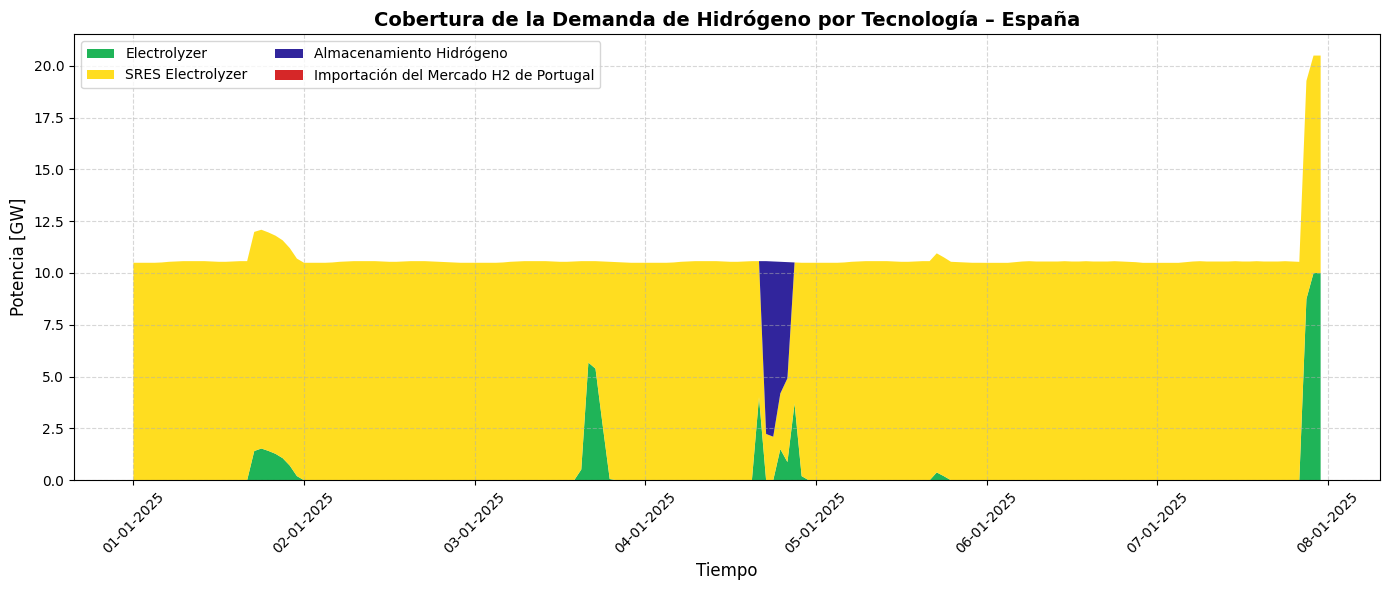

In [ ]:
# una grafica con la cobertura de la demanda hidrogeno en España,, que etenemos que tener en cuenta, electrolyzer, electrolyzer_sres, hydrogen_storage, interconexion_hidrogeno
df_h2_plot = pd.DataFrame({
    "ES_electrolyzer":         -network.links_t.p1["ES_electrolyzer"]     / 1e3,
    "ES_SRES_electrolyzer":    -network.links_t.p1["ES_SRES_electrolyzer"] / 1e3,
    "ES_hydrogen_storage":      network.storage_units_t.p["ES_hydrogen_storage"].clip(lower=0) / 1e3,
    "PT_ES_interconexion_hidrogeno": -network.links_t.p1["PT_ES_interconexion_hidrogeno"].clip(upper=0) / 1e3,
}, index=times)
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_h2_plot.index,
    df_h2_plot["ES_electrolyzer"], df_h2_plot["ES_SRES_electrolyzer"], df_h2_plot["ES_hydrogen_storage"], df_h2_plot["PT_ES_interconexion_hidrogeno"],
    labels=["Electrolyzer","SRES Electrolyzer","Almacenamiento Hidrógeno","Importación del Mercado H2 de Portugal"],
    colors=["#1fb458", "#ffdb0eec", "#31259c", "#d62728"],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2476281058.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2476281058.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



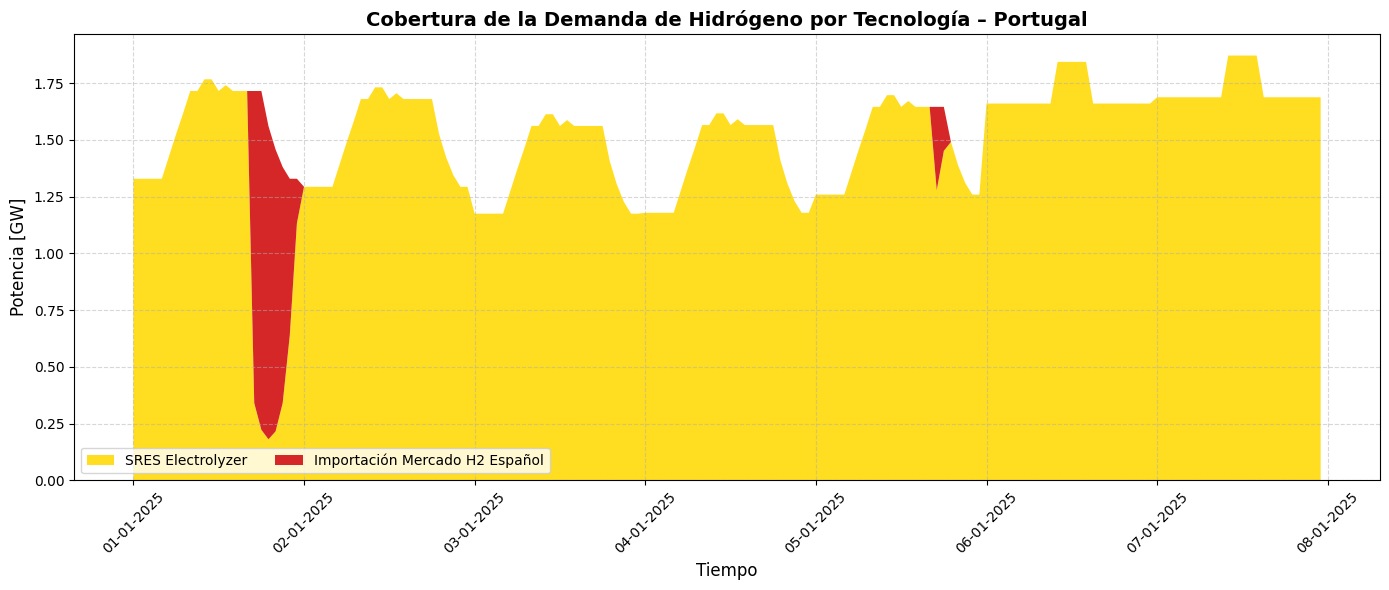

In [ ]:
# una grafica con la cobertura de la demanda hidrogeno en España,, que etenemos que tener en cuenta, electrolyzer, electrolyzer_sres, hydrogen_storage, interconexion_hidrogeno
df_h2_plot = pd.DataFrame({

    "PT_SRES_electrolyzer":    -network.links_t.p1["PT_SRES_electrolyzer"] / 1e3,
    "ES_PT_interconexion_hidrogeno": -network.links_t.p1["ES_PT_interconexion_hidrogeno"].clip(upper=0) / 1e3,

}, index=times)
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_h2_plot.index,
    df_h2_plot["PT_SRES_electrolyzer"], df_h2_plot["ES_PT_interconexion_hidrogeno"],
    labels=["SRES Electrolyzer","Importación Mercado H2 Español"],
    colors=[ "#ffdb0eec", "#d62728"],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – Portugal",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=10, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2794580189.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2794580189.py:19: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2794580189.py:26: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2794580189.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information

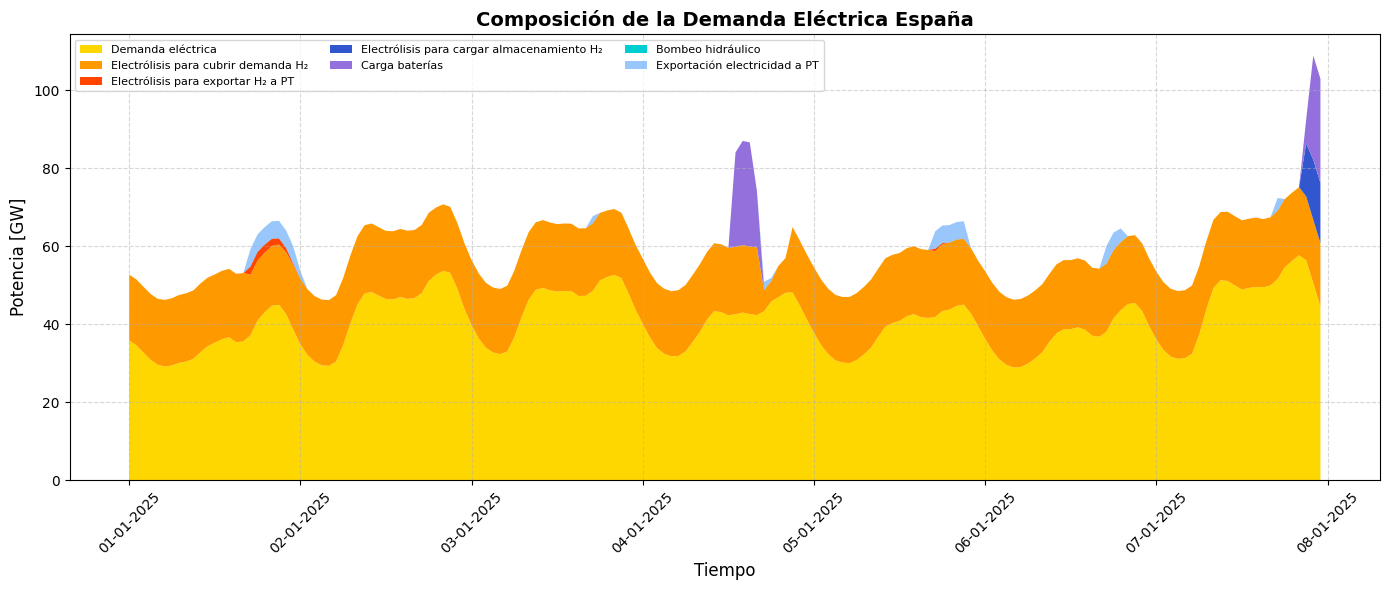

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ----------------------------- DEMANDA ELÉCTRICA (LOAD) -----------------------------
# Ajusta este nombre si tu load se llama distinto
national_electricity_demand = network.loads_t.p_set["ES_demand_2040"] / 1e3  # MW -> GW

# ----------------------------- ÍNDICES ROBUSTOS -------------------------------------
link_index = network.links.static.index
su_index   = network.storage_units.static.index

# ----------------------------- STORAGE UNITS ----------------------------------------
battery_sus = [n for n in su_index if "es_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in su_index if "es_hydrogen_storage" in n.lower()]

battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)          # carga = valores negativos
    .sum(axis=1)
    .abs() / 1e3            # MW -> GW
) if len(battery_sus) else 0.0

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
) if len(h2_sus) else 0.0

# ----------------------------- BOMBEO HIDRÁULICO ------------------------------------
pumped_links = [l for l in link_index if ("es_pump" in l.lower()) or ("es_turbina" in l.lower())]

pumping_demand = (
    network.links_t.p0[pumped_links]
    .clip(lower=0)          # según tu convención: p0 positivo = consumo eléctrico
    .sum(axis=1) / 1e3
) if len(pumped_links) else 0.0

# ----------------------------- EXPORT ELECTRICIDAD ES -> PT -------------------------
exportelectricity_links = [l for l in link_index if "es_pt_interconexion_electricidad" in l.lower()]

exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
) if len(exportelectricity_links) else 0.0

# ----------------------------- ELECTROLIZADORES (ELECTRICIDAD CONSUMIDA) ------------
electrolyzer_links = [l for l in link_index if "es_electrolyzer" in l.lower()]

electrolyzer_electricity = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)          # según tu convención: p0 positivo = consumo eléctrico
    .sum(axis=1) / 1e3
) if len(electrolyzer_links) else 0.0

# ========================= PARTIR ELECTRÓLISIS EN 3 (H2) ============================
# 1) Demanda H2 (load): si la tienes como load en loads_t.p_set
#    (si tu H2-demand NO está en loads, dímelo y lo adaptamos a stores/links)
h2_load_names = [n for n in network.loads_t.p_set.columns if "es_hydrogen_demand" in n.lower()]
h2_demand = (
    network.loads_t.p_set[h2_load_names].sum(axis=1) / 1e3
) if len(h2_load_names) else 0.0

# 2) Export H2 ES -> PT: link interconexión hidrógeno
export_h2_links = [l for l in link_index if "es_pt_interconexion_hidrogeno" in l.lower()]

export_h2 = (
    network.links_t.p0[export_h2_links]
    .clip(lower=0)          # asumiendo misma convención: p0 positivo = "sale" del sistema ES (demanda interna)
    .sum(axis=1) / 1e3
) if len(export_h2_links) else 0.0

# 3) Carga almacenamiento H2 (ya calculada arriba): h2_charge

# Reparto proporcional de la electricidad de electrólisis por sumideros de H2
# (si en una hora no hay sumidero, asigna 0 a las tres categorías)
h2_sinks_total = (h2_demand + export_h2 + h2_charge)

# evitar división 0
with np.errstate(divide='ignore', invalid='ignore'):
    share_demand = np.where(h2_sinks_total != 0, h2_demand / h2_sinks_total, 0.0)
    share_export = np.where(h2_sinks_total != 0, export_h2 / h2_sinks_total, 0.0)
    share_store  = np.where(h2_sinks_total != 0, h2_charge / h2_sinks_total, 0.0)

# Series (alineadas en índice temporal)
idx = national_electricity_demand.index
def to_series(x):
    if isinstance(x, (int, float)):
        return pd.Series(0.0, index=idx)
    return x.reindex(idx).fillna(0.0)

electrolyzer_electricity = to_series(electrolyzer_electricity)
h2_demand  = to_series(h2_demand)
export_h2  = to_series(export_h2)
h2_charge  = to_series(h2_charge)
battery_charge = to_series(battery_charge)
pumping_demand = to_series(pumping_demand)
exportelectricity_demand = to_series(exportelectricity_demand)

elec_for_h2_demand  = electrolyzer_electricity * pd.Series(share_demand, index=idx)
elec_for_h2_export  = electrolyzer_electricity * pd.Series(share_export, index=idx)
elec_for_h2_storage = electrolyzer_electricity * pd.Series(share_store,  index=idx)

# ----------------------------- GRÁFICA STACKPLOT -----------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
    idx,
    national_electricity_demand,
    elec_for_h2_demand,
    elec_for_h2_export,
    elec_for_h2_storage,
    battery_charge,
    pumping_demand,
    exportelectricity_demand,
    labels=[
        "Demanda eléctrica",
        "Electrólisis para cubrir demanda H₂",
        "Electrólisis para exportar H₂ a PT",
        "Electrólisis para cargar almacenamiento H₂",
        "Carga baterías",
        "Bombeo hidráulico",
        "Exportación electricidad a PT",
    ],
    colors=[
        "#FFD700",  # Demanda eléctrica
        "#FF9900",  # Electrólisis -> H2 demanda
        "#FF4500",  # Electrólisis -> H2 export
        "#3256CD",  # Electrólisis -> H2 storage
        "#9370DB",  # Baterías
        "#00CED1",  # Bombeo
        "#2386F776" # Export elec
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8 , ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\963890452.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\963890452.py:17: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\963890452.py:27: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\963890452.py:35: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynam

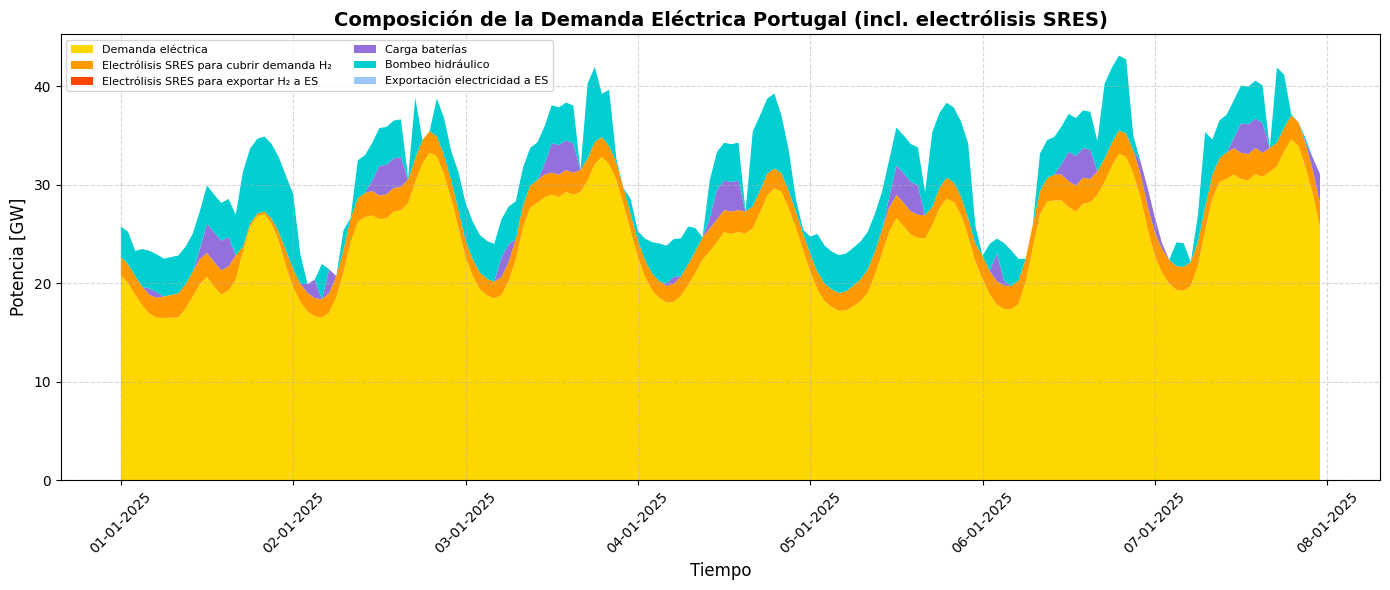

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ----------------------------- DEMANDA ELÉCTRICA (LOAD) -----------------------------
national_electricity_demand = network.loads_t.p_set["PT_demand_2040"] / 1e3  # MW -> GW

link_index = network.links.static.index
su_index   = network.storage_units.static.index

# ----------------------------- STORAGE UNITS ----------------------------------------
battery_sus = [n for n in su_index if "pt_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in su_index if "pt_hydrogen_storage" in n.lower()]

battery_charge = (
    network.storage_units_t.p[battery_sus].clip(upper=0).sum(axis=1).abs() / 1e3
) if len(battery_sus) else pd.Series(0.0, index=network.snapshots)

h2_charge = (
    network.storage_units_t.p[h2_sus].clip(upper=0).sum(axis=1).abs() / 1e3
) if len(h2_sus) else pd.Series(0.0, index=network.snapshots)

# ----------------------------- BOMBEO HIDRÁULICO ------------------------------------
pumped_links = [l for l in link_index if ("pt_pump" in l.lower()) or ("pt_turbina" in l.lower())]
pumping_demand = (
    network.links_t.p0[pumped_links].clip(lower=0).sum(axis=1) / 1e3
) if len(pumped_links) else pd.Series(0.0, index=network.snapshots)

# ----------------------------- EXPORT ELECTRICIDAD PT -> ES -------------------------
# (en tu naming, esto es "PT_ES_interconexion_electricidad")
export_elec_name = "PT_ES_interconexion_electricidad"
exportelectricity_demand = (
    network.links_t.p0[export_elec_name].clip(lower=0) / 1e3
) if export_elec_name in network.links_t.p0.columns else pd.Series(0.0, index=network.snapshots)

# ----------------------------- ELECTROLIZADOR SRES PT (electricidad consumida) ------
ely_sres_name = "PT_SRES_electrolyzer"
electrolyzer_electricity = (
    network.links_t.p0[ely_sres_name].clip(lower=0) / 1e3
) if ely_sres_name in network.links_t.p0.columns else pd.Series(0.0, index=network.snapshots)

# ========================= PARTIR ELECTRÓLISIS EN 2 (H2) ============================
# 1) Demanda H2 PT
h2_demand = network.loads_t.p_set["PT_hydrogen_demand"] / 1e3  # MW_H2 -> GW_H2 (en tus unidades)

# 2) Export H2 PT -> ES (si existe)
export_h2_name = "PT_ES_interconexion_hidrogeno"
export_h2 = (
    network.links_t.p0[export_h2_name].clip(lower=0) / 1e3
) if export_h2_name in network.links_t.p0.columns else pd.Series(0.0, index=network.snapshots)

# (Opcional) 3) Carga almacenamiento H2 (ya calculada): h2_charge

# Reparto proporcional de la electricidad del electrolizador SRES por sumideros de H2
h2_sinks_total = (h2_demand + export_h2 + h2_charge).replace(0.0, np.nan)

share_demand = (h2_demand / h2_sinks_total).fillna(0.0)
share_export = (export_h2 / h2_sinks_total).fillna(0.0)
share_store  = (h2_charge / h2_sinks_total).fillna(0.0)

elec_for_h2_demand  = electrolyzer_electricity * share_demand
elec_for_h2_export  = electrolyzer_electricity * share_export
elec_for_h2_storage = electrolyzer_electricity * share_store

# ----------------------------- GRÁFICA STACKPLOT -----------------------------------
idx = national_electricity_demand.index

plt.figure(figsize=(14, 6))
plt.stackplot(
    idx,
    national_electricity_demand.reindex(idx).fillna(0.0),
    elec_for_h2_demand.reindex(idx).fillna(0.0),
    elec_for_h2_export.reindex(idx).fillna(0.0),

    battery_charge.reindex(idx).fillna(0.0),
    pumping_demand.reindex(idx).fillna(0.0),
    exportelectricity_demand.reindex(idx).fillna(0.0),
    labels=[
        "Demanda eléctrica",
        "Electrólisis SRES para cubrir demanda H₂",
        "Electrólisis SRES para exportar H₂ a ES",
   
        "Carga baterías",
        "Bombeo hidráulico",
        "Exportación electricidad a ES",
    ],
    colors=[
        "#FFD700",
        "#FF9900",
        "#FF4500",

        "#9370DB",
        "#00CED1",
        "#2386F776"
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica Portugal (incl. electrólisis SRES)", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\563842625.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



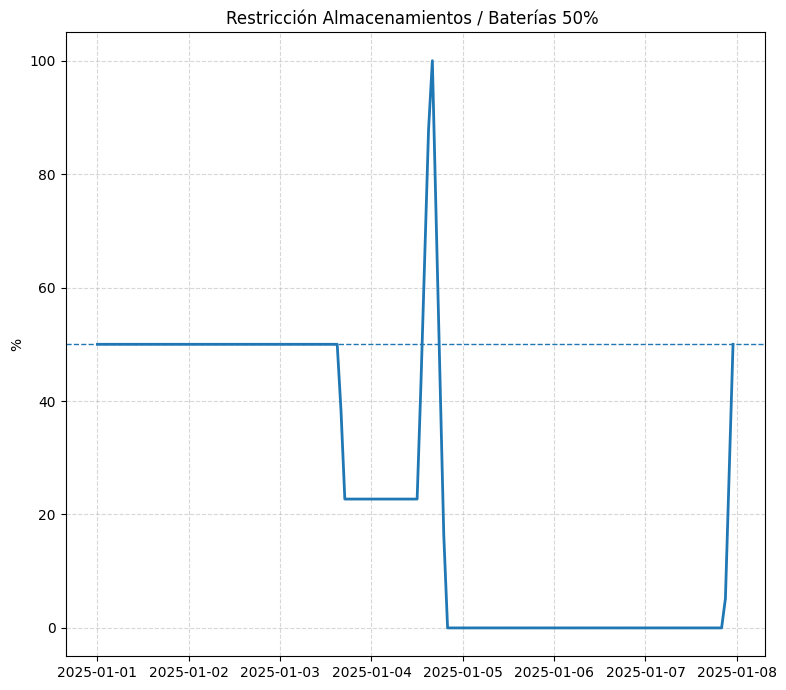

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\563842625.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



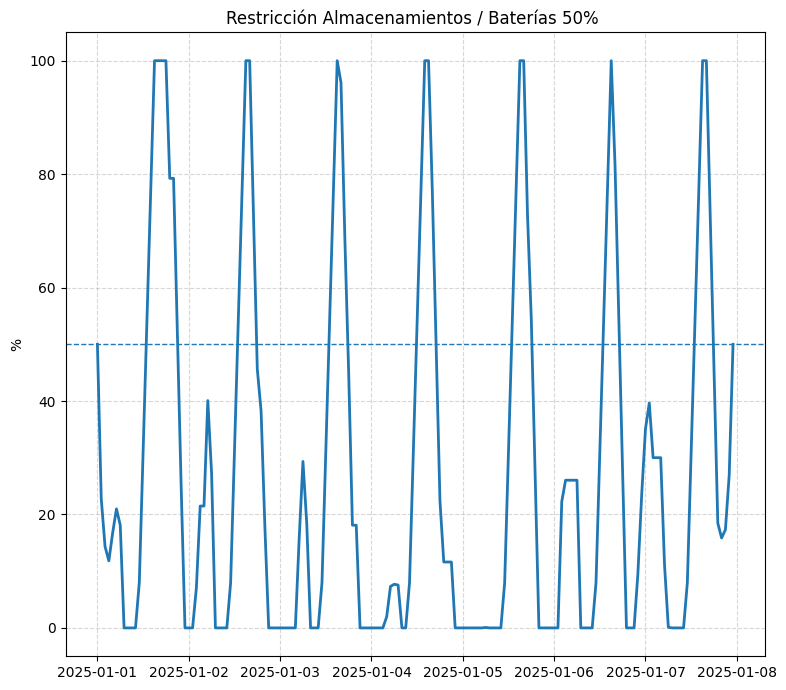

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\563842625.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



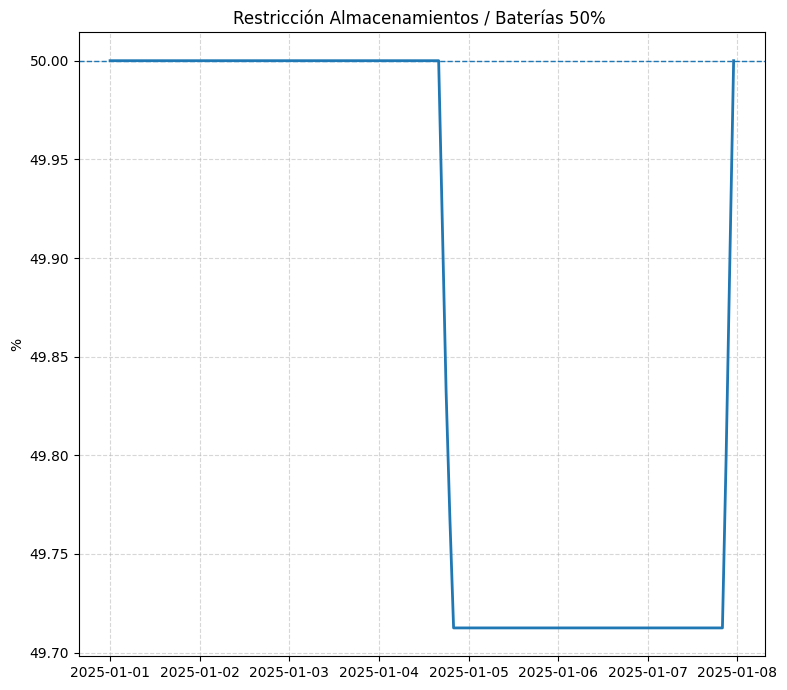

In [ ]:

def plot_soc_percent(network, battery_name):
    su = network.storage_units.static
    p_nom = float(su.loc[battery_name, "p_nom"])
    max_hours = float(su.loc[battery_name, "max_hours"])
    Emax = p_nom * max_hours

    soc = network.storage_units_t.state_of_charge[battery_name].astype(float)
    soc_pct = soc / Emax * 100

    plt.figure(figsize=(8,7))
    plt.plot(soc_pct.index, soc_pct, linewidth=2)
    plt.axhline(50, linestyle="--", linewidth=1)
    plt.title(f"Restricción Almacenamientos / Baterías 50% ")
    plt.ylabel("%")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_soc_percent(network, "ES_electricity_market_battery")
plot_soc_percent(network, "PT_electricity_market_battery")
plot_soc_percent(network, "ES_hydrogen_storage")


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4171288439.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\4171288439.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



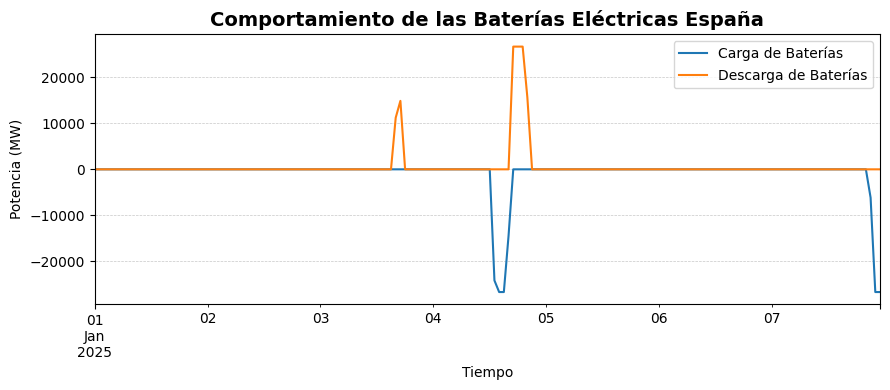

In [ ]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["ES_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["ES_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas España", fontsize=14, fontweight="bold")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3175701087.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\3175701087.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



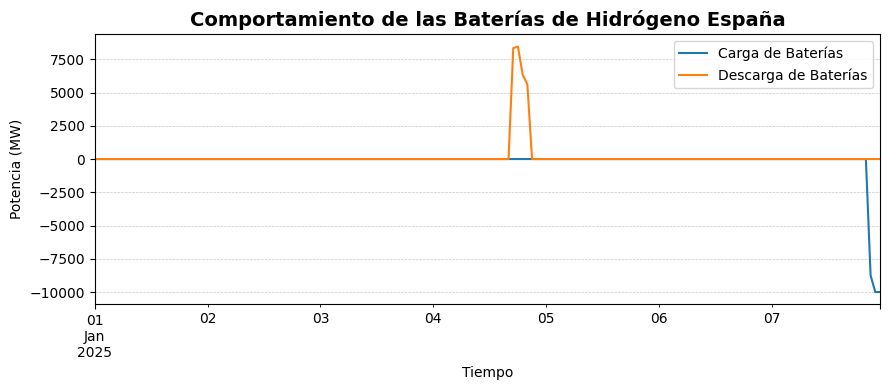

In [ ]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["ES_hydrogen_storage"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["ES_hydrogen_storage"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías de Hidrógeno España", fontsize=14, fontweight="bold")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\125842920.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\125842920.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



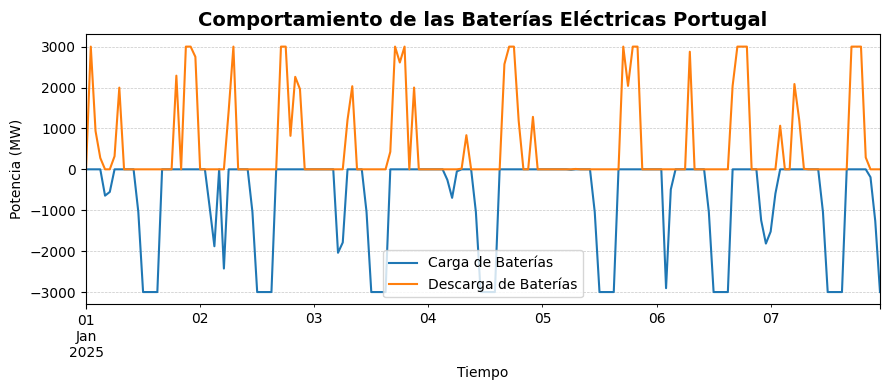

In [ ]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["PT_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["PT_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
plt.style.use('default')
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas Portugal", fontsize=14, fontweight="bold")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2438572649.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



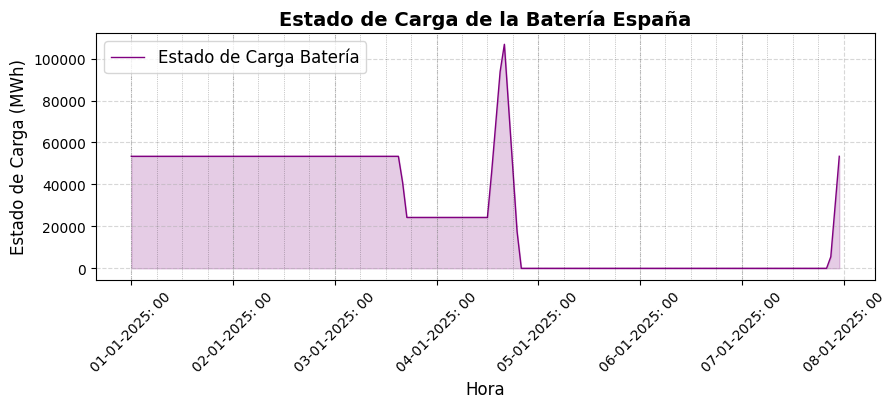

In [ ]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\2724379132.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



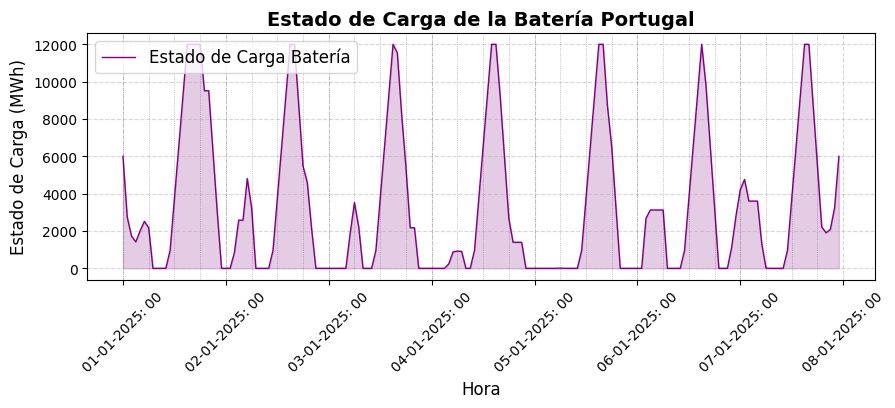

In [ ]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["PT_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_4824\1258577109.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



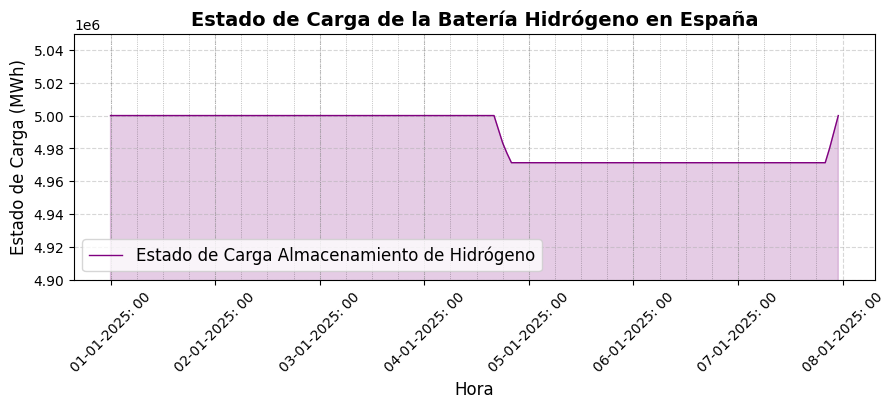

In [ ]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_hydrogen_storage"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Almacenamiento de Hidrógeno", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Hidrógeno en España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)

plt.ylim(4900000, 5050000)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()